# Modelado — Predicción de Gravedad de Accidentes de Tránsito en Colombia

**Target:** `CON HERIDOS` (0) vs `CON MUERTOS` (1) — desbalanceo ~95/5  
**Pipeline:** Limpieza → Feature Engineering (sin leakage) → Preprocesamiento → Modelado  

---

## 1. Imports y Configuración Global

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
%matplotlib inline

# ── Imports sklearn ──────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_validate
)
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score,
    f1_score, roc_curve, auc,
    precision_score, recall_score,
    average_precision_score, matthews_corrcoef,
    precision_recall_curve,
    ConfusionMatrixDisplay, balanced_accuracy_score, make_scorer
)
from sklearn.calibration import CalibratedClassifierCV

# ── Imports imblearn ─────────────────────────────────────────────────────────
from imblearn.ensemble import RUSBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Imports modelos ──────────────────────────────────────────────────────────
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier

# ── Imports LIME ─────────────────────────────────────────────────────────────
import lime
import lime.lime_tabular

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Imports OK')

Imports OK


## 2. Carga del Dataset

In [2]:
df = pd.read_csv(
    'VEHICULOS_INVOLUCRADOS_EN_UN_ACCIDENTE_DE_TRANSITO_LEY_2251-2022_20260205.csv',
    encoding='latin-1'
)
print(f'Dimensiones del dataset: {df.shape[0]:,} registros × {df.shape[1]} variables')
df.head()

Dimensiones del dataset: 406,540 registros × 9 variables


,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
0,HONDA,2017,MOTOCICLETA,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
1,CHEVROLET,2007,CAMION,20.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
2,JEEP,2017,CAMPERO,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
3,CHEVROLET,2023,CAMIONETA,2.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
4,HONDA,2026,MOTOCICLETA,1.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA


In [3]:
df['TIPO_VEHICULO'].unique()

array(['MOTOCICLETA', 'CAMION', 'CAMPERO', 'CAMIONETA', 'AUTOMOVIL',
       'BUS', 'BUSETA', 'TRACTOCAMION', 'MICROBUS', 'VOLQUETA',
       'MOTOCARRO', 'MONTACARGAS', 'CUATRIMOTO', 'TRACTOR', 'CICLOMOTOR',
       'MAQ. AGRICOLA', 'MAQ. INDUSTRIAL', 'RETROEXCAVADORA', 'REMOLQUE',
       'CUADRICICLO', 'MOTONIVELADORA', 'MINICARGADOR', 'FRESADORA',
       'COMPACTADOR', 'SEMIREMOLQUE', 'EXCAVADORA', 'CARGADOR',
       'PAVIMENTADORA'], dtype=object)

## 3. Limpieza y Corrección de Tipos

In [4]:
# Corrección de tipos de datos
df['EDAD_VEHICULO']   = pd.to_numeric(df['EDAD_VEHICULO'],   errors='coerce')
df['MODELO_VEHICULO'] = pd.to_numeric(df['MODELO_VEHICULO'], errors='coerce')
df['FECHA_ACCIDENTE'] = pd.to_datetime('01/' + df['FECHA_ACCIDENTE'], format='%d/%m/%Y')

print('Tipos de datos corregidos:')
print(df[['EDAD_VEHICULO','MODELO_VEHICULO','FECHA_ACCIDENTE']].dtypes)

Tipos de datos corregidos:
EDAD_VEHICULO             float64
MODELO_VEHICULO             int64
FECHA_ACCIDENTE    datetime64[ns]
dtype: object


In [5]:
# MARCA_VEHICULO: nulos estructurales → 'Sin información'
df['MARCA_VEHICULO'] = df['MARCA_VEHICULO'].fillna('Sin información')

# EDAD_VEHICULO: imputar con mediana por TIPO_VEHICULO
# Justificación: diferentes tipos de vehículo tienen distribuciones de edad muy distintas.
# Una mediana global introduciría sesgo (ej. la edad típica de una moto ≠ la de un camión).
df['EDAD_VEHICULO'] = df.groupby('TIPO_VEHICULO')['EDAD_VEHICULO'].transform(
    lambda x: x.fillna(x.median())
)
# Fallback global para tipos con todos los valores nulos
df['EDAD_VEHICULO'] = df['EDAD_VEHICULO'].fillna(df['EDAD_VEHICULO'].median())

print('Nulos después de imputación:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos después de imputación:
Series([], dtype: int64)


In [6]:
# ── Filtros de calidad ───────────────────────────────────────────────────────
antes = len(df)
df = df[(df['MODELO_VEHICULO'] >= 1950) & (df['MODELO_VEHICULO'] <= 2025)]
print(f'Eliminados por MODELO_VEHICULO fuera de [1950, 2025]: {antes - len(df):,}')

antes2 = len(df)
df = df[df['EDAD_VEHICULO'] <= 60]
print(f'Eliminados por EDAD_VEHICULO > 60 años: {antes2 - len(df):,}')
print(f'Registros restantes: {len(df):,}')

Eliminados por MODELO_VEHICULO fuera de [1950, 2025]: 2,964
Eliminados por EDAD_VEHICULO > 60 años: 449
Registros restantes: 403,127


In [7]:
# ── Componentes temporales ───────────────────────────────────────────────────
df['AÑO']        = df['FECHA_ACCIDENTE'].dt.year
df['MES']        = df['FECHA_ACCIDENTE'].dt.month
df['MES_NOMBRE'] = df['FECHA_ACCIDENTE'].dt.month_name()
df['TRIMESTRE']  = df['FECHA_ACCIDENTE'].dt.quarter
df['SEMESTRE']   = df['FECHA_ACCIDENTE'].apply(lambda x: 1 if x.month <= 6 else 2)
df['DIA_SEMANA'] = df['FECHA_ACCIDENTE'].dt.day_name()

print('Componentes temporales extraídos correctamente.')
print(df[['FECHA_ACCIDENTE','AÑO','MES','DIA_SEMANA']].head(3))

Componentes temporales extraídos correctamente.
  FECHA_ACCIDENTE   AÑO  MES DIA_SEMANA
0      2025-12-01  2025   12     Monday
1      2025-12-01  2025   12     Monday
2      2025-12-01  2025   12     Monday


In [8]:
# ── Filtro 1: Excluir 2026 (año incompleto) ──────────────────────────────────
df = df[df['AÑO'] <= 2025]
print(f'Registros tras excluir 2026: {len(df):,}')

# ── Filtro 2: Excluir anomalía julio 2024 ────────────────────────────────────
# El 78.7% de los 28,794 registros de julio 2024 provienen de un único reportante
# ('STRIA DE TTOyTTE MEDELLIN'), con una tasa de mortalidad que cayó de 4.24% a 1.38%
# mientras el volumen se triplicaba — relación inversa incompatible con un fenómeno real.
mascara_anomalia = ~(
    (df['AÑO'] == 2024) &
    (df['MES'] == 7) &
    (df['AUTORIDAD_DE_TRANSITO'] == 'STRIA DE TTOyTTE MEDELLIN')
)
antes = len(df)
df = df[mascara_anomalia]
print(f'Eliminados por anomalía julio 2024: {antes - len(df):,}')
print(f'Dataset final para análisis: {len(df):,} registros')

Registros tras excluir 2026: 401,137


Eliminados por anomalía julio 2024: 22,667
Dataset final para análisis: 378,470 registros


## 4. Feature Engineering

**Reglas anti-leakage aplicadas:**
- Todo lo que use el `Target` se calcula SOLO sobre `y_train` después del split
- `ES_MES_ALTO_RIESGO` fue **eliminada** (se definía con meses observados en el dataset completo → leakage conceptual)
- `MES` se transforma en codificación cíclica (sin/cos) para evitar ordinalidad falsa
- Las tasas históricas de mortalidad por municipio se mapean SOLO desde train

In [9]:
# ── 4.1 Variables base (sin target, sin leakage) ─────────────────────────────

# Antigüedad precisa
df['ANTIGÜEDAD_VEHICULO'] = df['FECHA_ACCIDENTE'].dt.year - df['MODELO_VEHICULO']

bins_edad   = [0, 5, 10, 20, float('inf')]
labels_edad = ['0-5 años', '6-10 años', '11-20 años', '>20 años']
df['CAT_EDAD_VEHICULO'] = pd.cut(df['ANTIGÜEDAD_VEHICULO'], bins=bins_edad, labels=labels_edad)

# Vacaciones (sin usar el target — solo depende del mes del calendario)
meses_vacaciones = [1, 6, 7, 12]
df['ES_VACACIONES'] = df['MES'].isin(meses_vacaciones).astype(int)

# Fin de semana (nuevo)
df['ES_FIN_SEMANA'] = df['DIA_SEMANA'].isin(['Friday','Saturday','Sunday']).astype(int)

# MES cíclico (nuevo) — evita ordinalidad falsa enero=1 < diciembre=12
df['MES_SIN'] = np.sin(2 * np.pi * df['MES'] / 12)
df['MES_COS'] = np.cos(2 * np.pi * df['MES'] / 12)

# Vehículo muy antiguo + log de edad (nuevo)
df['VEHICULO_MUY_ANTIGUO'] = (df['EDAD_VEHICULO'] > 30).astype(int)
df['EDAD_VEH_LOG']         = np.log1p(df['EDAD_VEHICULO'])

print('Variables temporales y de vehículo creadas.')

Variables temporales y de vehículo creadas.


In [10]:
# ── 4.2 Perfil de masa e interacción ─────────────────────────────────────────

def categorizar_perfil_fisico(tipo):
    tipo = str(tipo).strip().upper()
    if tipo in ['MOTOCICLETA','MOTOCARRO','CUATRIMOTO','CICLOMOTOR','CUADRICICLO']:
        return 'VULNERABLE'
    elif tipo in ['AUTOMOVIL','CAMIONETA','CAMPERO','MICROBUS']:
        return 'LIVIANO'
    elif tipo in ['CAMION','BUS','BUSETA','TRACTOCAMION','VOLQUETA','REMOLQUE','SEMIREMOLQUE']:
        return 'PESADO_RAPIDO'
    elif tipo in ['MONTACARGAS','TRACTOR','MAQ. AGRICOLA','MAQ. INDUSTRIAL',
                  'RETROEXCAVADORA','MOTONIVELADORA','MINICARGADOR','FRESADORA',
                  'COMPACTADOR','EXCAVADORA','CARGADOR','PAVIMENTADORA']:
        return 'MAQUINARIA_LENTA'
    else:
        return 'OTROS'

df['PERFIL_MASA'] = df['TIPO_VEHICULO'].apply(categorizar_perfil_fisico)

# Interacción masa × edad (tu mejor feature — conservada)
df['INTERACCION_MASA_EDAD'] = (
    df['PERFIL_MASA'] + '_' + df['CAT_EDAD_VEHICULO'].astype(str)
)

print(f'PERFIL_MASA distribución:\n{df["PERFIL_MASA"].value_counts()}')
print(f'\nINTERACCION_MASA_EDAD: {df["INTERACCION_MASA_EDAD"].nunique()} categorías únicas')

PERFIL_MASA distribución:
PERFIL_MASA
VULNERABLE          216848
LIVIANO             125451
PESADO_RAPIDO        36117
MAQUINARIA_LENTA        54
Name: count, dtype: int64

INTERACCION_MASA_EDAD: 19 categorías únicas


In [11]:
# ── 4.3 Target y selección de columnas ───────────────────────────────────────

dataset_clean = df.copy()
results = []  # Lista para acumular resultados de todos los modelos

dataset_clean['Target'] = (dataset_clean['GRAVEDAD_ACCIDENTE'] == 'CON MUERTOS').astype(int)

# Columnas base (sin ninguna feature que use el target)
columnas_base = [
    # Numéricas
    'EDAD_VEHICULO', 'EDAD_VEH_LOG', 'VEHICULO_MUY_ANTIGUO',
    'MES_SIN', 'MES_COS',
    'ES_VACACIONES', 'ES_FIN_SEMANA',
    # Categóricas
    'DEPARTAMENTO_ACCIDENTE', 'MUNICIPIO_ACCIDENTE',
    'PERFIL_MASA', 'INTERACCION_MASA_EDAD',
]

X = dataset_clean[columnas_base].copy()
y = dataset_clean['Target'].copy()

print(f'Features totales antes del split: {X.shape[1]}')
print(f'Registros: {len(X):,}')
print(f'Positivos (CON MUERTOS): {y.sum():,} ({y.mean()*100:.2f}%)')

Features totales antes del split: 11
Registros: 378,470
Positivos (CON MUERTOS): 20,137 (5.32%)


## 5. Split Train / Test

> **Muro de contención:** todo lo que use `y_train` (target encoding, tasas históricas)
> se calcula **después** de este split, nunca antes.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

class_names = ['CON HERIDOS', 'CON MUERTOS']

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos

print('Distribución de clases en entrenamiento:')
print(f'   CON HERIDOS: {neg:,} ({neg/len(y_train)*100:.1f}%)')
print(f'   CON MUERTOS: {pos:,} ({pos/len(y_train)*100:.1f}%)')
print(f'   Ratio negativo/positivo: {ratio:.1f}')
print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

Distribución de clases en entrenamiento:
   CON HERIDOS: 286,666 (94.7%)
   CON MUERTOS: 16,110 (5.3%)
   Ratio negativo/positivo: 17.8

Train: 302,776 | Test: 75,694


## 6. Feature Engineering post-split (sin leakage)

Las features que usan el target (`y_train`) se calculan aquí, SOLO sobre train,
y se mapean al test sin acceder a `y_test`.

In [13]:
# ── 6.1 Tasa histórica de mortalidad por municipio ───────────────────────────
# La geografía es el predictor más fuerte (Cramér's V análisis previo).
# Convertimos el municipio en una señal continua: P(muerte | municipio)
# calculada SOLO sobre train → sin leakage.

tasa_mun = y_train.groupby(X_train['MUNICIPIO_ACCIDENTE']).mean()
fallback_global = y_train.mean()  # Para municipios que aparecen solo en test

X_train = X_train.copy()
X_test  = X_test.copy()

X_train['TASA_MORT_MUNICIPIO'] = (
    X_train['MUNICIPIO_ACCIDENTE'].map(tasa_mun).fillna(fallback_global)
)
X_test['TASA_MORT_MUNICIPIO'] = (
    X_test['MUNICIPIO_ACCIDENTE'].map(tasa_mun).fillna(fallback_global)
)

# ── 6.2 Frecuencia de accidentes por municipio ───────────────────────────────
# Captura si el municipio es de alto tráfico (más accidentes = infra. más compleja)
freq_mun = X_train['MUNICIPIO_ACCIDENTE'].value_counts(normalize=True)

X_train['FREQ_MUNICIPIO'] = (
    X_train['MUNICIPIO_ACCIDENTE'].map(freq_mun).fillna(0)
)
X_test['FREQ_MUNICIPIO'] = (
    X_test['MUNICIPIO_ACCIDENTE'].map(freq_mun).fillna(0)
)

# ── 6.3 Target encoding de INTERACCION_MASA_EDAD ─────────────────────────────
# Suavizado bayesiano manual (más transparente que sklearn TargetEncoder)
smooth = 50  # Más alto = más suavizado (con 400k hay categorías con miles de filas)
global_mean = y_train.mean()

stats_int = pd.DataFrame({'y': y_train.values, 'col': X_train['INTERACCION_MASA_EDAD'].values})
agg_int = stats_int.groupby('col')['y'].agg(['mean','count'])
agg_int['te'] = (
    (agg_int['count'] * agg_int['mean'] + smooth * global_mean)
    / (agg_int['count'] + smooth)
)

X_train['INTERACCION_TE'] = X_train['INTERACCION_MASA_EDAD'].map(agg_int['te']).fillna(global_mean)
X_test['INTERACCION_TE']  = X_test['INTERACCION_MASA_EDAD'].map(agg_int['te']).fillna(global_mean)

print('Features post-split creadas (sin leakage):')
print('  TASA_MORT_MUNICIPIO  → tasa histórica P(muerte|municipio) desde train')
print('  FREQ_MUNICIPIO       → frecuencia relativa del municipio en train')
print('  INTERACCION_TE       → target encoding suavizado de INTERACCION_MASA_EDAD')
print(f'\nShape final train: {X_train.shape} | test: {X_test.shape}')

Features post-split creadas (sin leakage):
  TASA_MORT_MUNICIPIO  → tasa histórica P(muerte|municipio) desde train
  FREQ_MUNICIPIO       → frecuencia relativa del municipio en train
  INTERACCION_TE       → target encoding suavizado de INTERACCION_MASA_EDAD

Shape final train: (302776, 14) | test: (75694, 14)


## 7. Preprocesador Final

Usamos `OrdinalEncoder` para las categóricas (no OHE) porque los modelos
basados en árboles manejan bien variables ordinales y evitamos la explosión
de dimensionalidad del OHE con `DEPARTAMENTO_ACCIDENTE` (33 categorías).

In [14]:
# Columnas categóricas restantes (las de alta cardinalidad ya fueron encodadas)
numeric_features = [
    'EDAD_VEHICULO', 'EDAD_VEH_LOG', 'VEHICULO_MUY_ANTIGUO',
    'MES_SIN', 'MES_COS',
    'ES_VACACIONES', 'ES_FIN_SEMANA',
    'TASA_MORT_MUNICIPIO', 'FREQ_MUNICIPIO', 'INTERACCION_TE',
]

categorical_features = [
    'DEPARTAMENTO_ACCIDENTE',
    'PERFIL_MASA',
]

# INTERACCION_MASA_EDAD y MUNICIPIO_ACCIDENTE ya están representadas numéricamente
# → las eliminamos de X_train/X_test para no pasarlas al preprocessor
cols_a_excluir = ['MUNICIPIO_ACCIDENTE', 'INTERACCION_MASA_EDAD']
X_train = X_train.drop(columns=[c for c in cols_a_excluir if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in cols_a_excluir if c in X_test.columns])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
], remainder='drop')

print(f'Numéricas ({len(numeric_features)}):    {numeric_features}')
print(f'Categóricas ({len(categorical_features)}):  {categorical_features}')
print(f'Total features al modelo: {len(numeric_features) + len(categorical_features)}')

Numéricas (10):    ['EDAD_VEHICULO', 'EDAD_VEH_LOG', 'VEHICULO_MUY_ANTIGUO', 'MES_SIN', 'MES_COS', 'ES_VACACIONES', 'ES_FIN_SEMANA', 'TASA_MORT_MUNICIPIO', 'FREQ_MUNICIPIO', 'INTERACCION_TE']
Categóricas (2):  ['DEPARTAMENTO_ACCIDENTE', 'PERFIL_MASA']
Total features al modelo: 12


## 8. Función evaluate_model

In [15]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name,
                   cv_folds=5, make_plots=True, refit=True):
    """
    Evalúa un modelo con F1-Macro como métrica principal.
    Incluye validación cruzada + evaluación en test set + gráficas.

    Parámetros
    ----------
    refit : bool
        Si True, re-entrena el modelo con X_train antes de evaluar en test.
        Pasar refit=False cuando el modelo ya fue entrenado (ej: best_estimator_
        de GridSearchCV) para evitar entrenamiento redundante.
    """
    results_cv = {}

    # ── VALIDACIÓN CRUZADA ────────────────────────────────────────────────────
    if cv_folds > 0:
        print(f"\n{'='*60}")
        print(f"VALIDACIÓN CRUZADA ({cv_folds} folds) - {model_name}")
        print(f"{'='*60}")

        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

        scoring = {
            'accuracy':        'accuracy',
            'precision_macro': 'precision_macro',
            'recall_macro':    'recall_macro',
            'f1_macro':        'f1_macro',
            'f1_weighted':     'f1_weighted',
        }

        if hasattr(model, 'predict_proba'):
            scoring['roc_auc'] = make_scorer(
                roc_auc_score, needs_proba=True,
                multi_class='ovr', average='weighted'
            )

        cv_results = cross_validate(
            model, X_train, y_train,
            cv=cv, scoring=scoring,
            n_jobs=-1, return_train_score=True
        )

        results_cv = {
            'cv_accuracy_mean':       cv_results['test_accuracy'].mean(),
            'cv_accuracy_std':        cv_results['test_accuracy'].std(),
            'cv_f1_macro_mean':       cv_results['test_f1_macro'].mean(),
            'cv_f1_macro_std':        cv_results['test_f1_macro'].std(),
            'cv_f1_weighted_mean':    cv_results['test_f1_weighted'].mean(),
            'cv_f1_weighted_std':     cv_results['test_f1_weighted'].std(),
            'cv_train_f1_macro_mean': cv_results['train_f1_macro'].mean(),
            'cv_train_accuracy_mean': cv_results['train_accuracy'].mean(),
        }

        if 'test_roc_auc' in cv_results:
            results_cv['cv_auc_mean'] = cv_results['test_roc_auc'].mean()
            results_cv['cv_auc_std']  = cv_results['test_roc_auc'].std()

        print(f"   F1-Macro (CV):    {results_cv['cv_f1_macro_mean']:.4f} ± {results_cv['cv_f1_macro_std']:.4f}  ← PRINCIPAL")
        print(f"   Accuracy (CV):    {results_cv['cv_accuracy_mean']:.4f} ± {results_cv['cv_accuracy_std']:.4f}")
        print(f"   F1-Weighted (CV): {results_cv['cv_f1_weighted_mean']:.4f} ± {results_cv['cv_f1_weighted_std']:.4f}")
        if 'cv_auc_mean' in results_cv:
            print(f"   AUC (CV):         {results_cv['cv_auc_mean']:.4f} ± {results_cv['cv_auc_std']:.4f}")

        gap = results_cv['cv_train_f1_macro_mean'] - results_cv['cv_f1_macro_mean']
        print(f"\n   Gap Train-Val F1-Macro: {gap:.4f}", end=' ')
        print('Posible overfitting' if gap > 0.05 else 'Sin overfitting aparente')

    # ── EVALUACIÓN EN TEST SET ────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"EVALUACIÓN EN TEST SET - {model_name}")
    print(f"{'='*60}")

    start_time = time.time()
    if refit:
        model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    accuracy        = accuracy_score(y_test, y_pred)
    f1_macro        = f1_score(y_test, y_pred, average='macro',    zero_division=0)
    f1_weighted     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro    = recall_score(y_test, y_pred,    average='macro', zero_division=0)

    # Métricas adicionales para imbalance
    f1_muertos  = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec_muertos = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    pre_muertos = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    mcc         = matthews_corrcoef(y_test, y_pred)

    auc_score  = None
    aucpr      = None
    if y_pred_proba is not None and len(np.unique(y_test)) > 1:
        try:
            auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
            aucpr     = average_precision_score(y_test, y_pred_proba[:, 1])
        except Exception as e:
            print(f'Warning AUC ({model_name}): {e}')

    print(f"   F1-Macro:          {f1_macro:.4f}  ← PRINCIPAL")
    print(f"   F1-MUERTOS:        {f1_muertos:.4f}")
    print(f"   Recall-MUERTOS:    {rec_muertos:.4f}")
    print(f"   Precision-MUERTOS: {pre_muertos:.4f}")
    print(f"   Accuracy:          {accuracy:.4f}")
    print(f"   MCC:               {mcc:.4f}")
    if auc_score: print(f"   ROC-AUC:           {auc_score:.4f}")
    if aucpr:     print(f"   PR-AUC:            {aucpr:.4f}")
    print(f"   Tiempo entreno:    {train_time:.2f}s")

    print('\n   Reporte de clasificación:')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # ── GRÁFICAS ──────────────────────────────────────────────────────────────
    if make_plots:
        fig, axes = plt.subplots(1, 3, figsize=(19, 5))
        fig.suptitle(f'Evaluación: {model_name}', fontsize=13, fontweight='bold')

        # ROC
        if y_pred_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
            roc_auc_val = auc(fpr, tpr)
            axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_val:.3f}')
            axes[0].plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='Baseline')
            axes[0].set_xlabel('Tasa de Falsos Positivos')
            axes[0].set_ylabel('Tasa de Verdaderos Positivos')
            axes[0].set_title('Curva ROC')
            axes[0].legend(); axes[0].grid(alpha=0.3)

        # PR curve
        if y_pred_proba is not None:
            prec_c, rec_c, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
            ap = average_precision_score(y_test, y_pred_proba[:, 1])
            axes[1].plot(rec_c, prec_c, color='green', lw=2, label=f'PR-AUC = {ap:.3f}')
            axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', label='Baseline')
            axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
            axes[1].set_title('Curva Precision-Recall')
            axes[1].legend(); axes[1].grid(alpha=0.3)

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
                    xticklabels=class_names, yticklabels=class_names)
        axes[2].set_title('Matriz de Confusión')
        axes[2].set_xlabel('Predicción'); axes[2].set_ylabel('Real')

        plt.tight_layout()
        plt.show()

    result = {
        'model':           model_name,
        'accuracy':        accuracy,
        'f1_macro':        f1_macro,
        'f1_weighted':     f1_weighted,
        'f1_muertos':      f1_muertos,
        'recall_muertos':  rec_muertos,
        'precision_macro': precision_macro,
        'recall_macro':    recall_macro,
        'mcc':             mcc,
        'auc':             auc_score,
        'pr_auc':          aucpr,
        'train_time':      train_time,
        'predictions':     y_pred,
        'probabilities':   y_pred_proba,
        'f1':              f1_macro,
        'precision':       precision_macro,
        'recall':          recall_macro,
    }
    if results_cv:
        result.update(results_cv)
    return result

---
## 9. Modelos de Clasificación


Distribución — HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79

Búsqueda de hiperparámetros con RandomizedSearchCV
Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV 1/5] END model__colsample_bytree=0.9, model__learning_rate=0.05, model__max_depth=5, model__min_child_weight=5, model__n_estimators=300, model__scale_pos_weight=8.897144630664183, model__subsample=0.9;, score=0.310 total time=   9.5s
[CV 2/5] END model__colsample_bytree=0.9, model__learning_rate=0.05, model__max_depth=5, model__min_child_weight=5, model__n_estimators=300, model__scale_pos_weight=8.897144630664183, model__subsample=0.9;, score=0.309 total time=   1.2s
[CV 3/5] END model__colsample_bytree=0.9, model__learning_rate=0.05, model__max_depth=5, model__min_child_weight=5, model__n_estimators=300, model__scale_pos_weight=8.897144630664183, model__subsample=0.9;, score=0.309 total time=   1.2s
[CV 4/5] END model__colsample_bytree=0.9, model__learning_rate=0.05, model__max_depth=5, model__min_child_weight=5, model__n_estimators=300, model__scale_pos_weight=8.897144630664183, model__subsample=0.9;, score=0.306 total time=   1.2s
[CV 5/5] END model__colsample_bytree=0.9, model_

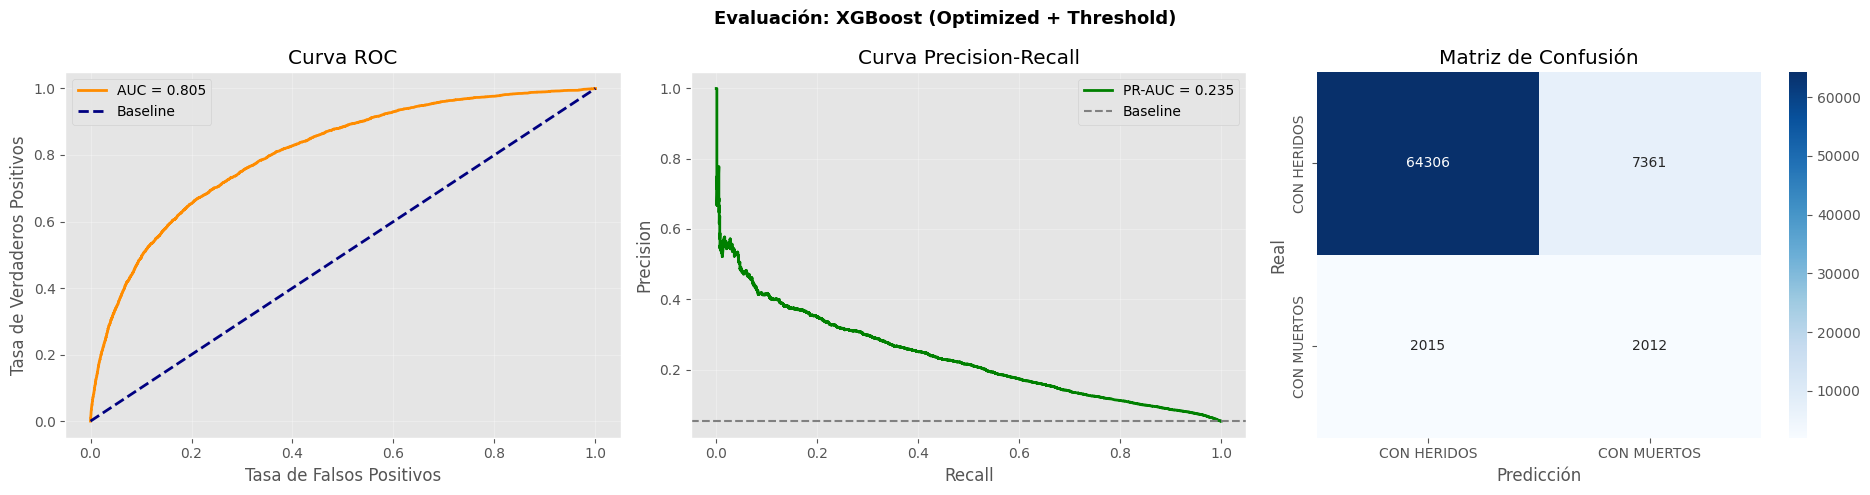


AUCPR (Precision-Recall): 0.2355
(Un clasificador aleatorio con 5% positivos tendría AUCPR ≈ 0.05)


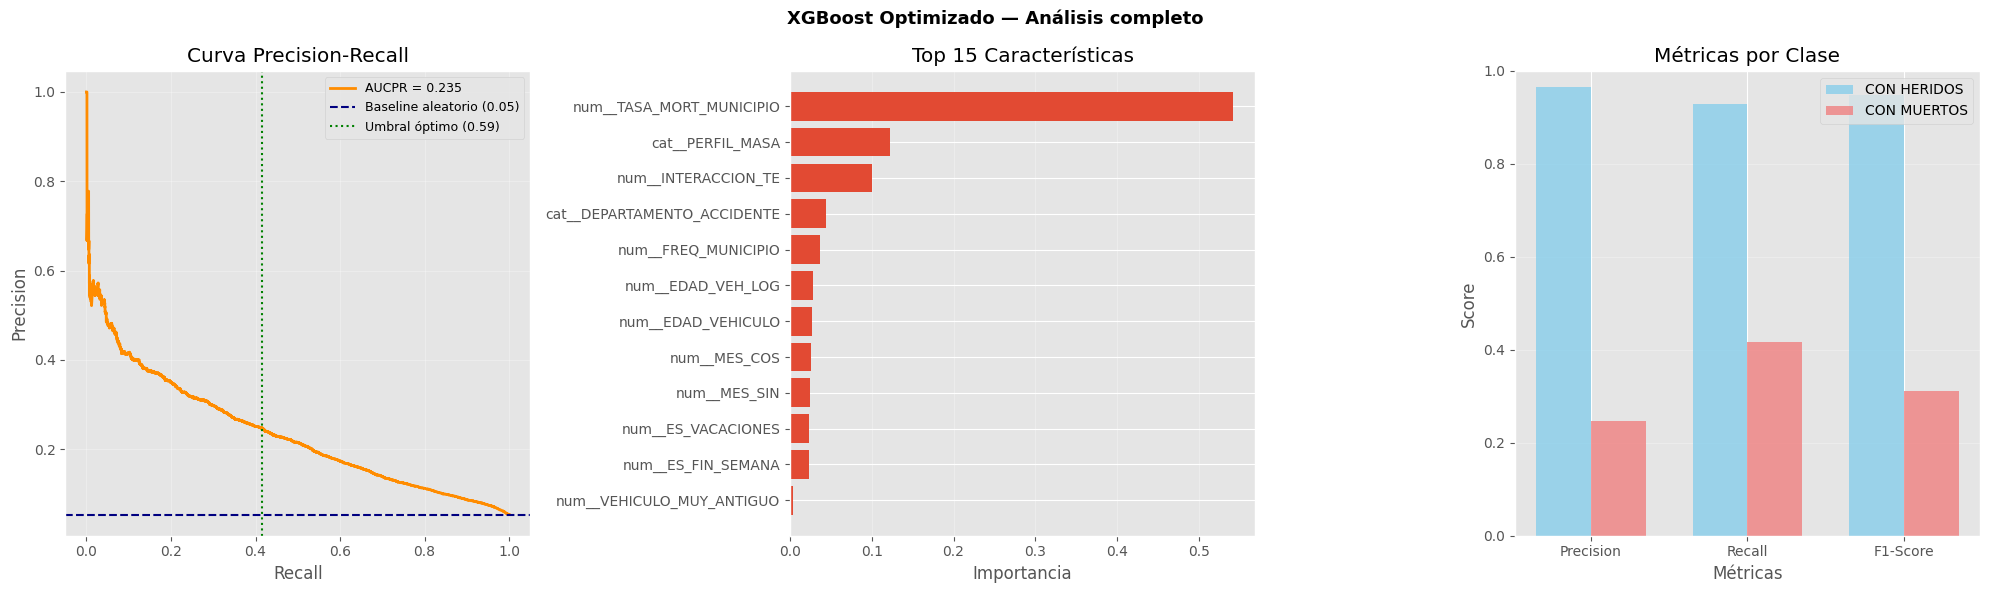


Top 10 características importantes:
                        feature  importance
7      num__TASA_MORT_MUNICIPIO      0.5421
11             cat__PERFIL_MASA      0.1227
9           num__INTERACCION_TE      0.1008
10  cat__DEPARTAMENTO_ACCIDENTE      0.0442
8           num__FREQ_MUNICIPIO      0.0365
1             num__EDAD_VEH_LOG      0.0275
0            num__EDAD_VEHICULO      0.0268
4                  num__MES_COS      0.0255
3                  num__MES_SIN      0.0249
5            num__ES_VACACIONES      0.0232

Interpretabilidad con LIME - XGBoost

1. CASO CON MUERTOS correctamente clasificado


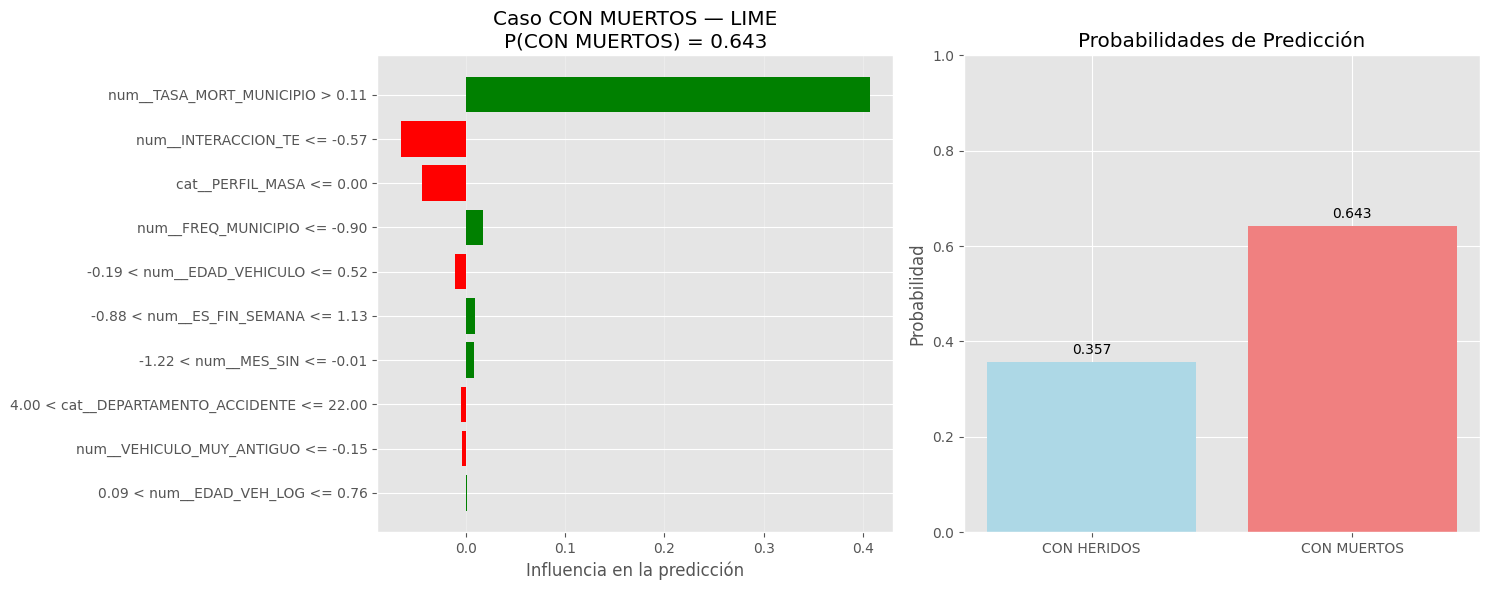


2. CASO CON HERIDOS correctamente clasificado


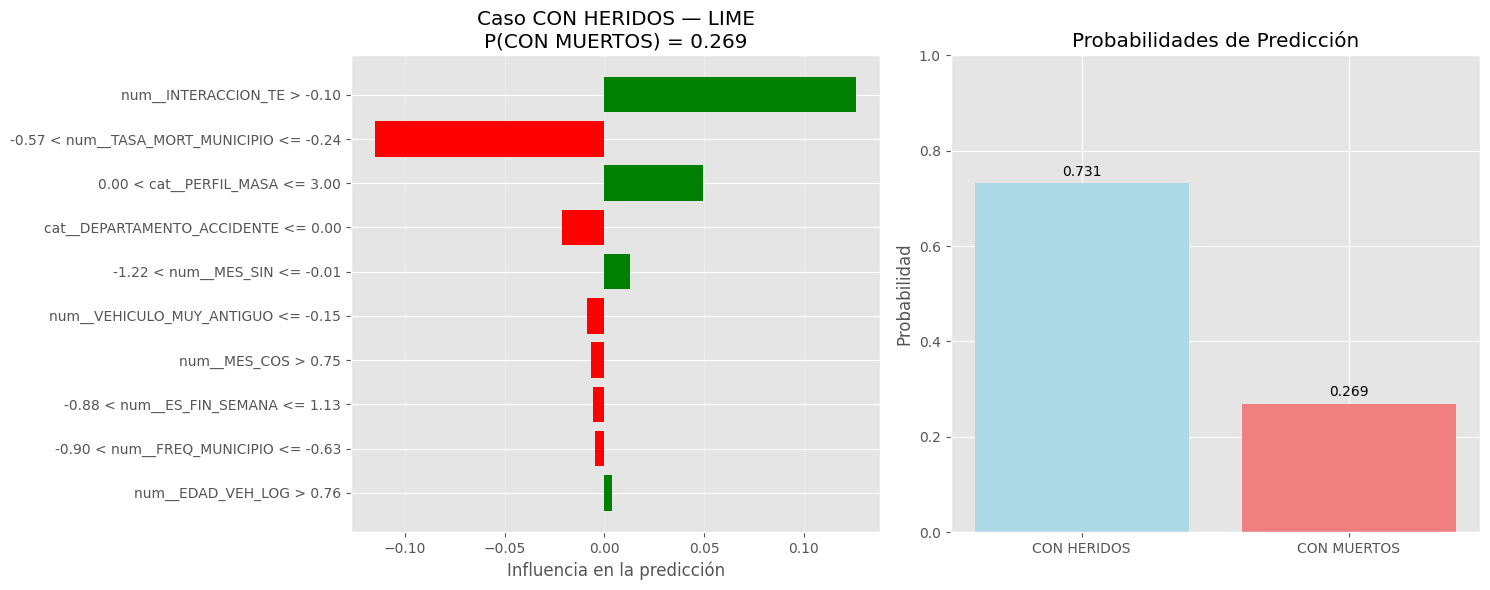

['xgboost_optimized_model.joblib']

In [16]:
import xgboost as xgb
import lime
import lime.lime_tabular
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, average_precision_score

# ── RATIO DE BALANCEO ─────────────────────────────────────────────────────────
neg = (y_train == 0).sum()  # CON HERIDOS
pos = (y_train == 1).sum()  # CON MUERTOS
ratio = neg / pos
print(f"Distribución — HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ── PIPELINE ──────────────────────────────────────────────────────────────────
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        random_state=42,
        eval_metric='aucpr',       # más honesto que logloss con desbalance
        scale_pos_weight=ratio,    # balanceo nativo GPU-compatible
        max_delta_step=1,          # estabiliza gradientes con desbalance severo
        device='cuda',
        tree_method='hist',
        nthread=-1
    ))
])

# ── PARAM GRID ────────────────────────────────────────────────────────────────
param_grid = {
    "model__n_estimators":     [200, 300, 400],
    "model__max_depth":        [3, 5],
    "model__learning_rate":    [0.05, 0.1],
    "model__subsample":        [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__min_child_weight": [1, 5, 10],          # clave con desbalance
    "model__scale_pos_weight": [ratio * 0.5, ratio, ratio * 1.5]
}

# ── RANDOMIZED SEARCH ─────────────────────────────────────────────────────────
print("\nBúsqueda de hiperparámetros con RandomizedSearchCV")
grid_search = RandomizedSearchCV(
    pipe_xgb, param_grid,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=make_scorer(f1_score, pos_label=1),   # F1 de MUERTOS como estrella polar
    n_jobs=1,
    random_state=42,
    verbose=3
)

grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros:    {grid_search.best_params_}")
print(f"Mejor F1-MUERTOS (CV): {grid_search.best_score_:.4f}")

final_model = grid_search.best_estimator_

# ── THRESHOLD TUNING ──────────────────────────────────────────────────────────
# Con desbalance severo el umbral 0.5 por defecto es subóptimo
from sklearn.metrics import precision_recall_curve

y_proba_val = final_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_val)
f1_scores_thresh = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_thresh = thresholds[np.argmax(f1_scores_thresh)]
print(f"\nUmbral óptimo encontrado: {best_thresh:.4f} (default era 0.5)")

# Predicciones con umbral ajustado
y_pred_opt   = (y_proba_val >= best_thresh).astype(int)
y_pred_default = final_model.predict(X_test)

print("\n── Comparación umbral default vs optimizado ──")
print(f"{'Métrica':<25} {'Default (0.5)':>15} {'Optimizado':>15}")
print("-" * 55)
for nombre, pred in [("Default (0.5)", y_pred_default), ("Optimizado", y_pred_opt)]:
    f1_min  = f1_score(y_test, pred, pos_label=1)
    f1_mac  = f1_score(y_test, pred, average='macro')
    rec_min = recall_score(y_test, pred, pos_label=1)
    pre_min = precision_score(y_test, pred, pos_label=1)
    print(f"  F1-MUERTOS:  {f1_min:.4f}")
    print(f"  F1-Macro:    {f1_mac:.4f}")
    print(f"  Recall:      {rec_min:.4f}")
    print(f"  Precision:   {pre_min:.4f}")
    print()

# Usar predicciones con umbral optimizado para el resto
y_pred = y_pred_opt

# ── EVALUACIÓN ────────────────────────────────────────────────────────────────
result = evaluate_model(
    final_model,
    X_train, X_test, y_train, y_test,
    model_name="XGBoost (Optimized + Threshold)",
    cv_folds=5,
    make_plots=True,
    refit=False
)
results.append(result)

# ── MÉTRICAS COMPLETAS ────────────────────────────────────────────────────────
y_pred_proba     = result['probabilities']
y_pred_proba_pos = y_pred_proba[:, 1] if y_pred_proba is not None else None

aucpr = average_precision_score(y_test, y_pred_proba_pos)
print(f"\nAUCPR (Precision-Recall): {aucpr:.4f}")
print(f"(Un clasificador aleatorio con 5% positivos tendría AUCPR ≈ 0.05)")

precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test, y_pred,    pos_label=0, zero_division=0)
recall_1    = recall_score(y_test, y_pred,    pos_label=1, zero_division=0)
f1_0        = f1_score(y_test, y_pred,        pos_label=0, zero_division=0)
f1_1        = f1_score(y_test, y_pred,        pos_label=1, zero_division=0)

# ── GRÁFICAS ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("XGBoost Optimizado — Análisis completo", fontsize=13, fontweight='bold')

# Curva Precision-Recall
axes[0].plot(recalls, precisions, color='darkorange', lw=2,
             label=f'AUCPR = {aucpr:.3f}')
axes[0].axhline(y=pos/(neg+pos), color='navy', linestyle='--',
                label=f'Baseline aleatorio ({pos/(neg+pos):.2f})')
axes[0].axvline(x=recalls[np.argmax(f1_scores_thresh)], color='green',
                linestyle=':', label=f'Umbral óptimo ({best_thresh:.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Importancia de características
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
importances   = final_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top_features = importance_df.head(15)
axes[1].barh(top_features['feature'], top_features['importance'])
axes[1].set_xlabel('Importancia')
axes[1].set_title('Top 15 Características')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

# Métricas por clase
x     = np.arange(3)
width = 0.35
axes[2].bar(x - width/2, [precision_0, recall_0, f1_0], width,
            label=class_names[0], alpha=0.8, color='skyblue')
axes[2].bar(x + width/2, [precision_1, recall_1, f1_1], width,
            label=class_names[1], alpha=0.8, color='lightcoral')
axes[2].set_xlabel('Métricas')
axes[2].set_ylabel('Score')
axes[2].set_title('Métricas por Clase')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Precision', 'Recall', 'F1-Score'])
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nTop 10 características importantes:")
print(importance_df.head(10).round(4))

# ── LIME ──────────────────────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - XGBoost")

X_train_processed = final_model.named_steps['preprocessor'].transform(X_train)
X_test_processed  = final_model.named_steps['preprocessor'].transform(X_test)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42
)

predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)


def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]

    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3)
    ax1.invert_yaxis()

    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad')
    ax2.set_title('Probabilidades de Predicción')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


if y_pred_proba_pos is not None:
    # Caso CON MUERTOS correctamente clasificado
    idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
    if len(idx_1) > 0:
        i = idx_1[0]
        print(f"\n1. CASO {class_names[1]} correctamente clasificado")
        exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
        plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_pred_proba_pos[i])

    # Caso CON HERIDOS correctamente clasificado
    idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
    if len(idx_0) > 0:
        i = idx_0[0]
        print(f"\n2. CASO {class_names[0]} correctamente clasificado")
        exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
        plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_pred_proba_pos[i])
        

joblib.dump(final_model, 'xgboost_optimized_model.joblib')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros: {'model__C': 0.01, 'model__penalty': 'l1'}
Mejor F1-Macro (CV Grid): 0.5609

VALIDACIÓN CRUZADA (5 folds) - Logistic Regression (Optimized)
   F1-Macro (CV):    0.5609 ± 0.0017  ← PRINCIPAL
   Accuracy (CV):    0.7856 ± 0.0023
   F1-Weighted (CV): 0.8416 ± 0.0015
   AUC (CV):         0.8012 ± 0.0026

   Gap Train-Val F1-Macro: 0.0001 Sin overfitting aparente

EVALUACIÓN EN TEST SET - Logistic Regression (Optimized)
   F1-Macro:          0.5609  ← PRINCIPAL
   F1-MUERTOS:        0.2460
   Recall-MUERTOS:    0.6546
   Precision-MUERTOS: 0.1515
   Accuracy:          0.7866
   MCC:               0.2393
   ROC-AUC:           0.7967
   PR-AUC:            0.2337
   Tiempo entreno:    1.19s

   Reporte de clasificación:
              precision    recall  f1-score   support

 CON HERIDOS       0.98      0.79      0.88     71667
 CON MUERTOS       0.15      0.65      0.25      4027

    accuracy                     

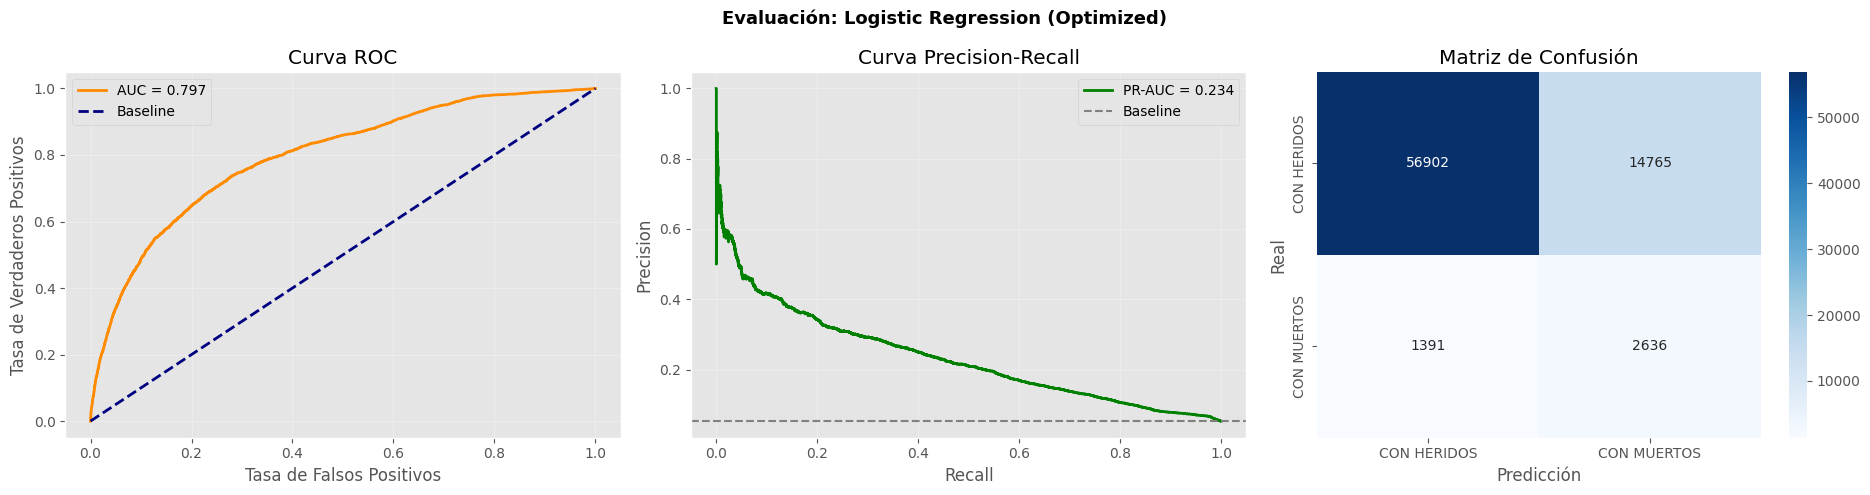


RESUMEN FINAL
                          Model  F1-Macro  Accuracy  F1-Weighted  Precision  Recall    AUC  Time(s)  CV_F1-Macro
XGBoost (Optimized + Threshold)    0.6162    0.8761       0.8984     0.5921  0.6985 0.8053   0.0000       0.6206
Logistic Regression (Optimized)    0.5609    0.7866       0.8422     0.5638  0.7243 0.7967   1.1937       0.5609


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# ── PIPELINE ──────────────────────────────────────────────────────────────────
pipe_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='liblinear'
    ))
])

# ── GRID SEARCH ───────────────────────────────────────────────────────────────
param_grid = {
    "model__C":       [0.01, 0.1, 1, 10],
    "model__penalty": ['l1', 'l2']
}

grid_search = GridSearchCV(
    pipe_logreg, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1-Macro (CV Grid): {grid_search.best_score_:.4f}")

# ── EVALUACIÓN ────────────────────────────────────────────────────────────────
result = evaluate_model(
    grid_search.best_estimator_,
    X_train, X_test, y_train, y_test,
    model_name="Logistic Regression (Optimized)",
    cv_folds=5,
    make_plots=True,
    refit=True  # ← No re-entrenar, ya está optimizado y entrenado por GridSearchCV
)
results.append(result)

# ── TABLA FINAL ───────────────────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model':        r['model'],
    'F1-Macro':     r['f1_macro'],
    'Accuracy':     r['accuracy'],
    'F1-Weighted':  r['f1_weighted'],
    'Precision':    r['precision_macro'],
    'Recall':       r['recall_macro'],
    'AUC':          r['auc'],
    'Time(s)':      r['train_time'],
    'CV_F1-Macro':  r.get('cv_f1_macro_mean', None),
} for r in results])

print("\nRESUMEN FINAL")
print(results_df.round(4).to_string(index=False))

   X_train: (302776, 12), X_test: (75694, 12)
   y_train - Clase 0 (CON HERIDOS): 286666, Clase 1 (CON MUERTOS): 16110
   y_test  - Clase 0 (CON HERIDOS): 71667, Clase 1 (CON MUERTOS): 4027

Búsqueda de hiperparámetros con GridSearchCV
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros:  {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Mejor F1-Macro (CV): 0.5841

VALIDACIÓN CRUZADA (5 folds) - Random Forest (Optimized)
   F1-Macro (CV):    0.5841 ± 0.0046  ← PRINCIPAL
   Accuracy (CV):    0.8908 ± 0.0029
   F1-Weighted (CV): 0.9033 ± 0.0019
   AUC (CV):         0.7400 ± 0.0012

   Gap Train-Val F1-Macro: 0.1847 Posible overfitting

EVALUACIÓN EN TEST SET - Random Forest (Optimized)
   F1-Macro:          0.5832  ← PRINCIPAL
   F1-MUERTOS:        0.2274
   Recall-MUERTOS:    0.3126
   Precision-MUERTOS: 0.1787
   Accuracy:          0.8870
   MCC:               0.1792
   ROC-AUC:           0.7350
   PR-AUC:            0.1561

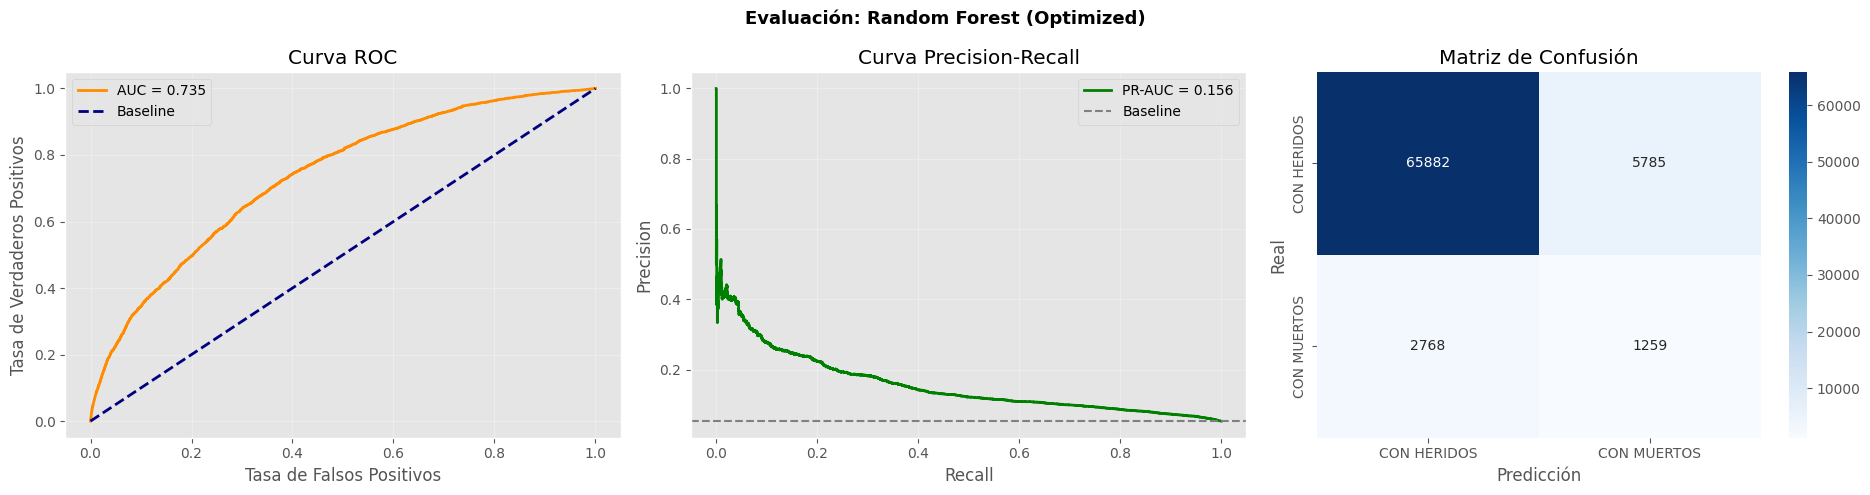

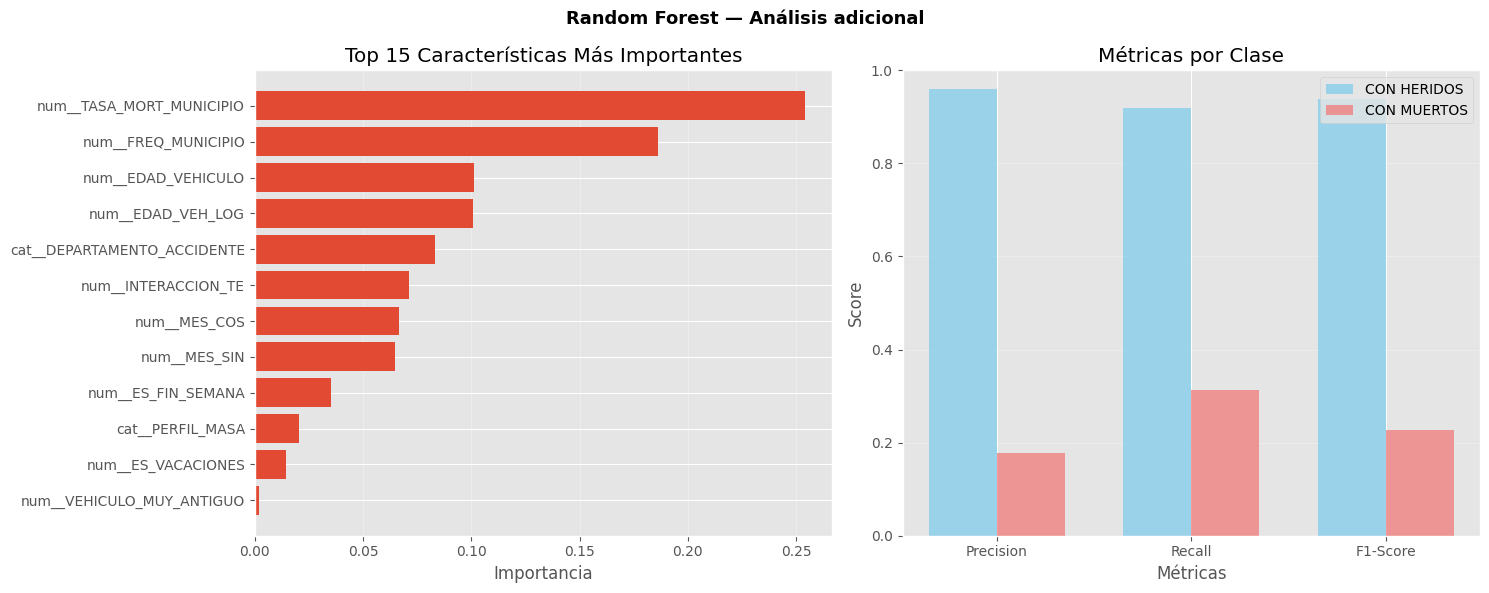


Top 10 características importantes:
                        feature  importance
7      num__TASA_MORT_MUNICIPIO      0.2540
8           num__FREQ_MUNICIPIO      0.1864
0            num__EDAD_VEHICULO      0.1012
1             num__EDAD_VEH_LOG      0.1009
10  cat__DEPARTAMENTO_ACCIDENTE      0.0832
9           num__INTERACCION_TE      0.0712
4                  num__MES_COS      0.0665
3                  num__MES_SIN      0.0649
6            num__ES_FIN_SEMANA      0.0352
11             cat__PERFIL_MASA      0.0202

Análisis de overfitting:
   Gap Accuracy (Train-Val): 0.0429
   Gap F1-Macro (Train-Val): 0.1847
   Buena generalización

Resumen del modelo:
   Árboles:              100
   Características:      12
   Profundidad promedio: 20.0
   Balanced Accuracy:    0.6160
   F1 CON HERIDOS:       0.9390
   F1 CON MUERTOS:       0.2274  ← clase crítica

RESUMEN FINAL — TODOS LOS MODELOS
                          Model  F1-Macro  Accuracy  F1-Weighted  Precision  Recall    AUC  Time(s)  

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, balanced_accuracy_score
)

print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"   y_train - Clase 0 (CON HERIDOS): {np.sum(y_train == 0)}, Clase 1 (CON MUERTOS): {np.sum(y_train == 1)}")
print(f"   y_test  - Clase 0 (CON HERIDOS): {np.sum(y_test == 0)}, Clase 1 (CON MUERTOS): {np.sum(y_test == 1)}")

# ── PIPELINE ──────────────────────────────────────────────────────────────────
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs=-1,
        class_weight='balanced'  # importante por desbalanceo de clases
    ))
])

# ── GRID SEARCH ───────────────────────────────────────────────────────────────
param_grid = {
    "model__n_estimators":  [100, 200],
    "model__max_depth":     [None, 10, 20],
    "model__min_samples_split": [2, 5],
}

print("\nBúsqueda de hiperparámetros con GridSearchCV")
grid_search = GridSearchCV(
    pipe_rf, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros:  {grid_search.best_params_}")
print(f"Mejor F1-Macro (CV): {grid_search.best_score_:.4f}")

final_model_rf = grid_search.best_estimator_

# ── EVALUACIÓN CON evaluate_model ─────────────────────────────────────────────
result_rf = evaluate_model(
    final_model_rf,
    X_train, X_test, y_train, y_test,
    model_name="Random Forest (Optimized)",
    cv_folds=5,
    make_plots=True,
    refit=True  # ya fue entrenado por GridSearch
)
results.append(result_rf)

# ── GRÁFICAS ADICIONALES ──────────────────────────────────────────────────────
y_pred       = result_rf['predictions']
y_pred_proba = result_rf['probabilities']

precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Random Forest — Análisis adicional", fontsize=13, fontweight='bold')

# Importancia de características
feature_names = final_model_rf.named_steps['preprocessor'].get_feature_names_out()
importances   = final_model_rf.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top_features = importance_df.head(15)
ax3.barh(top_features['feature'], top_features['importance'])
ax3.set_xlabel('Importancia')
ax3.set_title('Top 15 Características Más Importantes')
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

# Métricas por clase
x     = np.arange(3)
width = 0.35
ax4.bar(x - width/2, [precision_0, recall_0, f1_0], width, label='CON HERIDOS', alpha=0.8, color='skyblue')
ax4.bar(x + width/2, [precision_1, recall_1, f1_1], width, label='CON MUERTOS', alpha=0.8, color='lightcoral')
ax4.set_xlabel('Métricas')
ax4.set_ylabel('Score')
ax4.set_title('Métricas por Clase')
ax4.set_xticks(x)
ax4.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nTop 10 características importantes:")
print(importance_df.head(10).round(4))

# ── ANÁLISIS DE OVERFITTING ───────────────────────────────────────────────────
gap_acc = result_rf.get('cv_train_accuracy_mean', 0) - result_rf.get('cv_accuracy_mean', 0)
gap_f1  = result_rf.get('cv_train_f1_macro_mean', 0) - result_rf.get('cv_f1_macro_mean', 0)

print(f"\nAnálisis de overfitting:")
print(f"   Gap Accuracy (Train-Val): {gap_acc:.4f}")
print(f"   Gap F1-Macro (Train-Val): {gap_f1:.4f}")

if gap_acc > 0.1:
    print("   ALTO OVERFITTING — reducir n_estimators o aumentar min_samples_split")
elif gap_acc > 0.05:
    print("   Overfitting moderado — considerar ajustar hiperparámetros")
else:
    print("   Buena generalización")

# ── RESUMEN FINAL ─────────────────────────────────────────────────────────────
rf_model = final_model_rf.named_steps['model']
print(f"\nResumen del modelo:")
print(f"   Árboles:              {rf_model.n_estimators}")
print(f"   Características:      {rf_model.n_features_in_}")
print(f"   Profundidad promedio: {np.mean([t.get_depth() for t in rf_model.estimators_]):.1f}")
print(f"   Balanced Accuracy:    {balanced_acc:.4f}")
print(f"   F1 CON HERIDOS:       {f1_0:.4f}")
print(f"   F1 CON MUERTOS:       {f1_1:.4f}  ← clase crítica")

# ── TABLA COMPARATIVA ─────────────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model':       r['model'],
    'F1-Macro':    r['f1_macro'],
    'Accuracy':    r['accuracy'],
    'F1-Weighted': r['f1_weighted'],
    'Precision':   r['precision_macro'],
    'Recall':      r['recall_macro'],
    'AUC':         r['auc'],
    'Time(s)':     r['train_time'],
    'CV_F1-Macro': r.get('cv_f1_macro_mean', None),
} for r in results])

print("\nRESUMEN FINAL — TODOS LOS MODELOS")
print(results_df.round(4).to_string(index=False))

if len(results_df) > 1:
    best = results_df.sort_values('F1-Macro', ascending=False).iloc[0]
    rf_pos = results_df.sort_values('F1-Macro', ascending=False) \
                       .reset_index(drop=True) \
                       .query("Model == 'Random Forest (Optimized)'").index[0] + 1
    print(f"\nMejor modelo:  {best['Model']}  (F1-Macro: {best['F1-Macro']:.4f})")
    print(f"Random Forest: posición #{rf_pos} de {len(results_df)} modelos")

HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79
SUBMUESTRA PARA LIGHTGBM + SMOTE
Train completo:  302,776 registros
Submuestra:      181,665 registros
HERIDOS:         171,999 (94.7%)
MUERTOS:         9,666 (5.3%)

Train CV:         145,332
Val threshold:    36,333

[PASO 1] RandomizedSearch amplio (20 iter, 3 folds)...
Estimado: ~1.5-2 horas

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores parámetros:    {'smote__sampling_strategy': 0.5, 'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__num_leaves': 63, 'model__n_estimators': 300, 'model__min_child_samples': 20, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Mejor F1-MUERTOS (CV): 0.6320

[PASO 2] GridSearch fino...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Mejores parámetros finos: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.005, 'model__max_depth': 8, 'model__min_child_samples': 20, 'model__n_estimators': 3

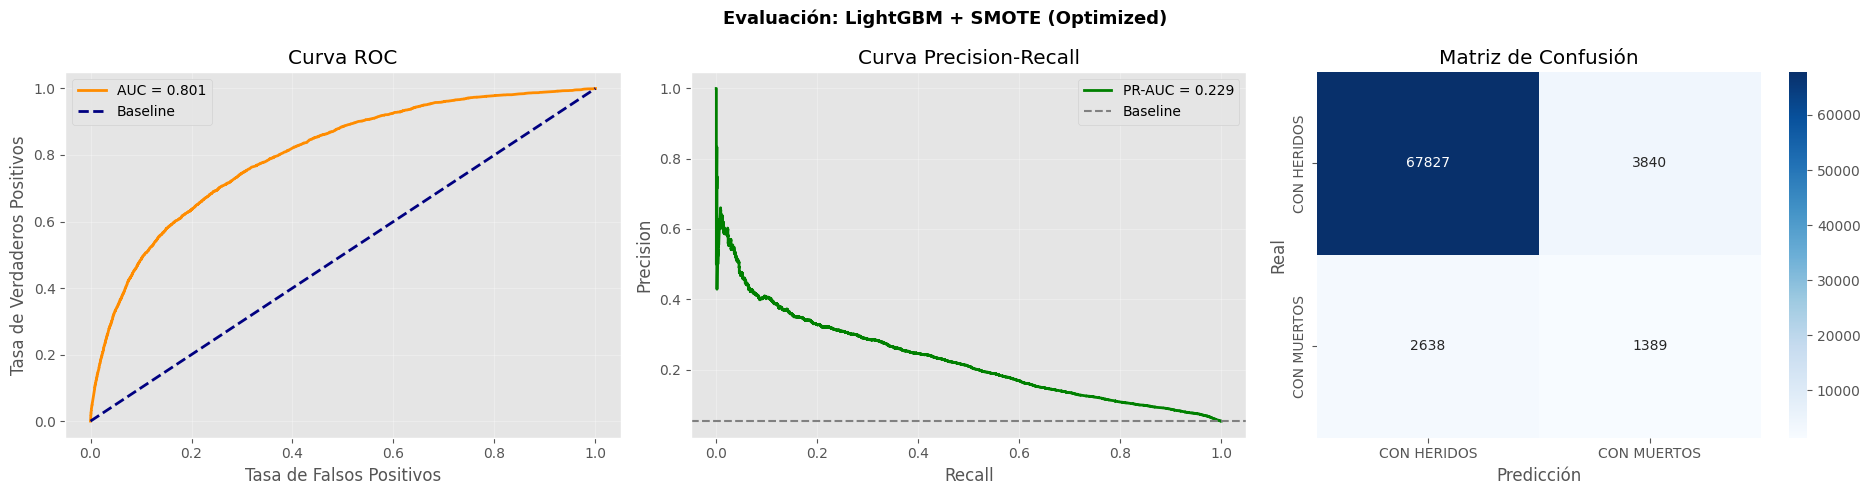

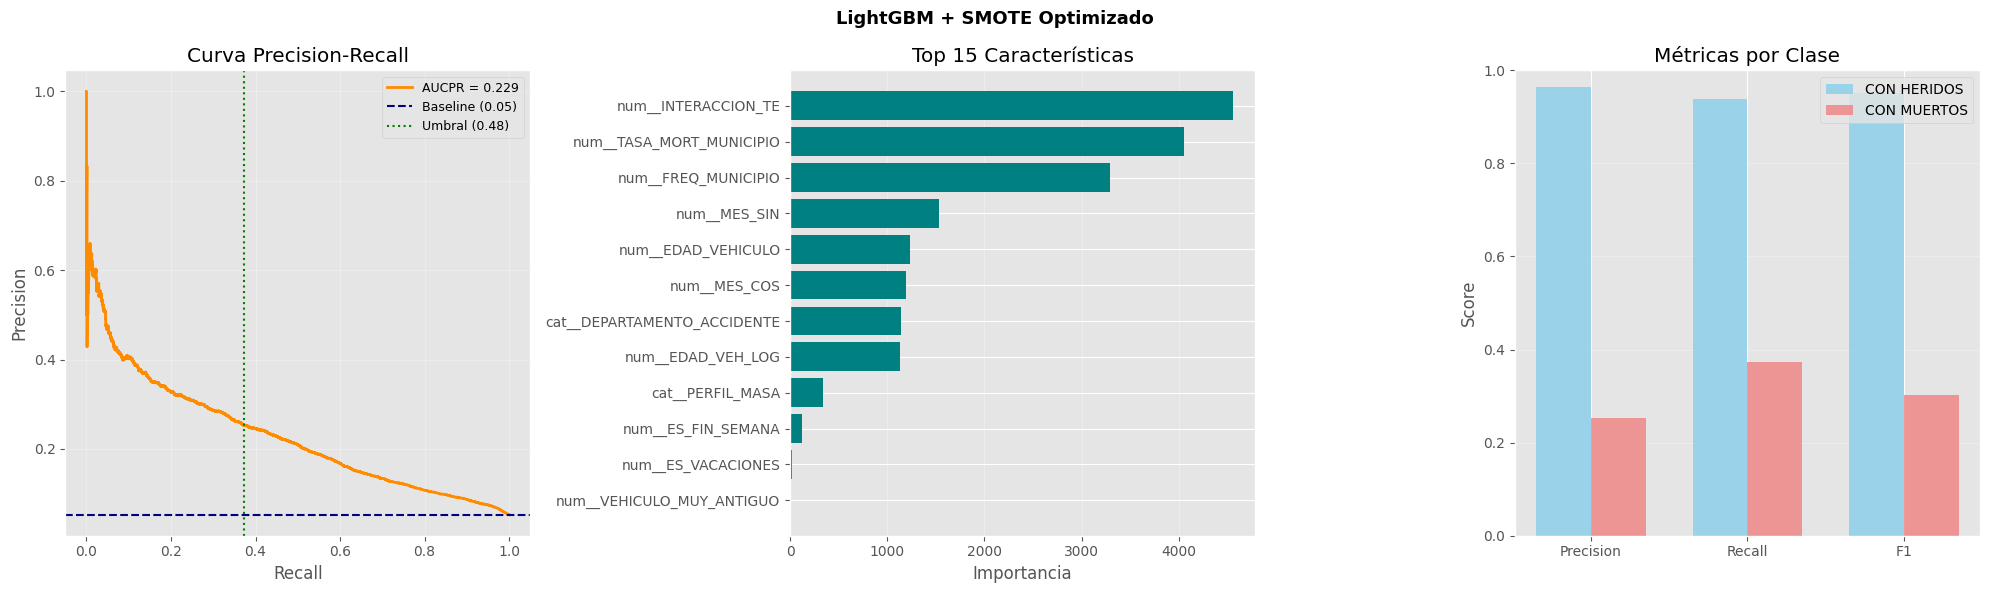


Interpretabilidad con LIME - LightGBM + SMOTE

1. CASO CON MUERTOS correctamente clasificado


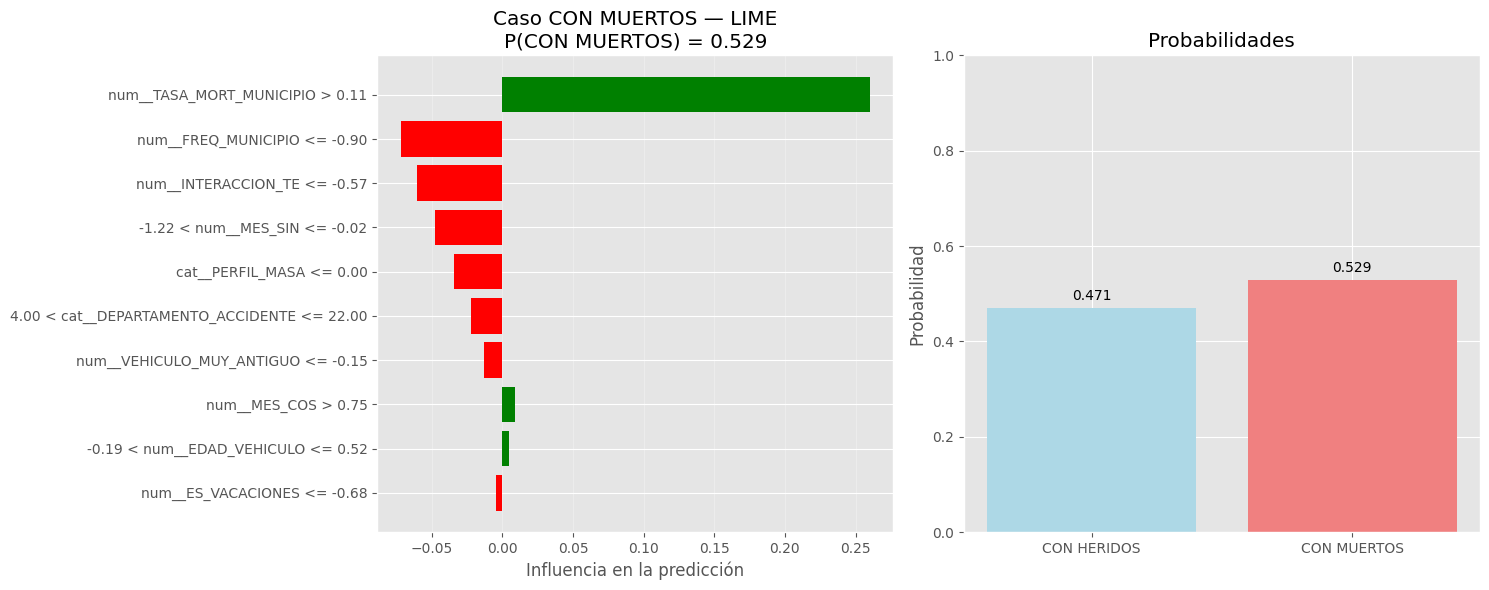


2. CASO CON HERIDOS correctamente clasificado


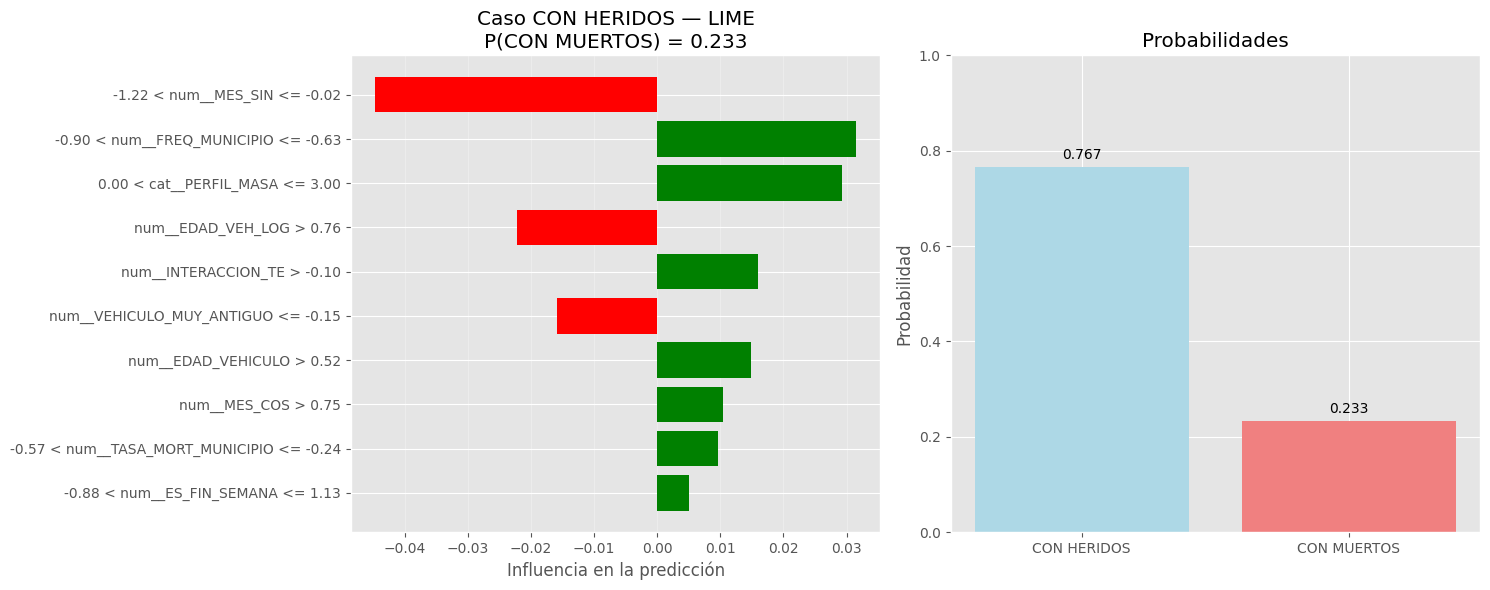

['model_lgbm.pkl']

In [19]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    make_scorer, f1_score, precision_recall_curve,
    precision_score, recall_score, average_precision_score,
    classification_report
)
import os, psutil

os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=False))

# ─────────────────────────────────────────────────────────
# RATIO
# ─────────────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ─────────────────────────────────────────────────────────
# SUBMUESTRA — 60% del train (~180k) para mejor cobertura
# ─────────────────────────────────────────────────────────
X_tr_sub, _, y_tr_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.40,                # 60% ≈ 180k registros
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("="*60)
print("SUBMUESTRA PARA LIGHTGBM + SMOTE")
print("="*60)
print(f"Train completo:  {X_train.shape[0]:,} registros")
print(f"Submuestra:      {X_tr_sub.shape[0]:,} registros")
print(f"HERIDOS:         {(y_tr_sub==0).sum():,} ({(y_tr_sub==0).mean()*100:.1f}%)")
print(f"MUERTOS:         {(y_tr_sub==1).sum():,} ({(y_tr_sub==1).mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────
# SPLIT VALIDACIÓN para threshold tuning — sin leakage
# ─────────────────────────────────────────────────────────
X_tr_cv, X_val_thresh, y_tr_cv, y_val_thresh = train_test_split(
    X_tr_sub, y_tr_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_tr_sub
)
print(f"\nTrain CV:         {X_tr_cv.shape[0]:,}")
print(f"Val threshold:    {X_val_thresh.shape[0]:,}")

# ─────────────────────────────────────────────────────────
# PIPELINE
# ─────────────────────────────────────────────────────────
pipe_lgbm = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        random_state=RANDOM_STATE,
        n_jobs=1,
        k_neighbors=5
    )),
    ('model', lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        device='gpu',
        verbose=-1,
        n_jobs=1,
        # Fijos — buenos para desbalanceo
        min_child_samples=20,
        subsample_freq=1,
    ))
])

# ─────────────────────────────────────────────────────────
# PASO 1 — RandomizedSearch AMPLIO (20 iter, 3 folds)
# Tiempo estimado: ~1.5-2 horas con 180k
# ─────────────────────────────────────────────────────────
param_grid_amplio = {
    "model__n_estimators":     [300, 500, 700, 1000],   # más árboles
    "model__max_depth":        [6, 8, 10, -1],           # -1 = sin límite
    "model__learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves":       [63, 127, 255],           # más hojas = más capacidad
    "model__subsample":        [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__reg_alpha":        [0, 0.1, 0.5, 1.0],
    "model__reg_lambda":       [0, 1, 5, 10],
    "model__min_child_samples":[10, 20, 50],             # regularización
    "smote__sampling_strategy":[0.2, 0.3, 0.4, 0.5],   # también optimiza el SMOTE
}

print("\n[PASO 1] RandomizedSearch amplio (20 iter, 3 folds)...")
print("Estimado: ~1.5-2 horas\n")

random_search = RandomizedSearchCV(
    pipe_lgbm,
    param_grid_amplio,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro', zero_division=0),   # F1-MUERTOS
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

random_search.fit(X_tr_cv, y_tr_cv)
print(f"\nMejores parámetros:    {random_search.best_params_}")
print(f"Mejor F1-MUERTOS (CV): {random_search.best_score_:.4f}")

# ─────────────────────────────────────────────────────────
# PASO 2 — GridSearch FINO sobre los mejores parámetros
# Busca en torno al mejor resultado anterior
# Tiempo estimado: ~20-30 min adicionales
# ─────────────────────────────────────────────────────────
best = random_search.best_params_

param_grid_fino = {
    "model__n_estimators":     [
        max(100, best['model__n_estimators'] - 100),
        best['model__n_estimators'],
        best['model__n_estimators'] + 100
    ],
    "model__learning_rate":    [
        max(0.005, best['model__learning_rate'] * 0.5),
        best['model__learning_rate'],
        best['model__learning_rate'] * 1.5
    ],
    "model__num_leaves":       [best['model__num_leaves']],
    "model__max_depth":        [best['model__max_depth']],
    "model__subsample":        [best['model__subsample']],
    "model__colsample_bytree": [best['model__colsample_bytree']],
    "model__reg_alpha":        [best['model__reg_alpha']],
    "model__reg_lambda":       [best['model__reg_lambda']],
    "model__min_child_samples":[best['model__min_child_samples']],
    "smote__sampling_strategy":[best['smote__sampling_strategy']],
}

from sklearn.model_selection import GridSearchCV

print("\n[PASO 2] GridSearch fino...")
grid_search = GridSearchCV(
    pipe_lgbm,
    param_grid_fino,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro', zero_division=0),
    n_jobs=1,
    verbose=1,
    refit=True
)

grid_search.fit(X_tr_cv, y_tr_cv)
print(f"\nMejores parámetros finos: {grid_search.best_params_}")
print(f"Mejor F1-MUERTOS (CV):    {grid_search.best_score_:.4f}")

final_model = grid_search.best_estimator_

# ─────────────────────────────────────────────────────────
# PASO 3 — Threshold tuning sobre validación
# ─────────────────────────────────────────────────────────
print("\n[PASO 3] Threshold tuning sobre validación...")
y_proba_val = final_model.predict_proba(X_val_thresh)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh, y_proba_val)

precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]
f1s            = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)

thresh_max_f1     = thresholds[np.argmax(f1s)]
mask              = precisions_cut >= 0.30
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 54)

resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1),
    ("Precision≥0.30",  thresh_min_prec),
    ("Equilibrio P=R",  thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p = precision_score(y_val_thresh, pred, pos_label=1, zero_division=0)
    r = recall_score(y_val_thresh,    pred, pos_label=1, zero_division=0)
    f = f1_score(y_val_thresh,        pred, pos_label=1, zero_division=0)
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': f}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")

# ─────────────────────────────────────────────────────────
# EVALUACIÓN FINAL en X_test
# ─────────────────────────────────────────────────────────
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred       = (y_proba_test >= best_thresh).astype(int)

aucpr       = average_precision_score(y_test, y_proba_test)
precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test,    y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test,    y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test,        y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)
f1_macro    = f1_score(y_test,        y_pred, average='macro')

print("\n" + "="*60)
print("RESULTADOS FINALES (LightGBM + SMOTE)")
print("="*60)
print(f"F1-MUERTOS:        {f1_1:.4f}")
print(f"Recall-MUERTOS:    {recall_1:.4f}")
print(f"Precision-MUERTOS: {precision_1:.4f}")
print(f"F1-Macro:          {f1_macro:.4f}")
print(f"AUCPR:             {aucpr:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

result = evaluate_model(
    final_model,
    X_tr_cv, X_test, y_tr_cv, y_test,
    model_name="LightGBM + SMOTE (Optimized)",
    cv_folds=3,
    make_plots=True,
    refit=False
)
results.append(result)

# ─────────────────────────────────────────────────────────
# GRÁFICAS
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("LightGBM + SMOTE Optimizado", fontsize=13, fontweight='bold')

# Curva PR
precisions_t, recalls_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[0].plot(recalls_t, precisions_t, color='darkorange', lw=2, label=f'AUCPR = {aucpr:.3f}')
axes[0].axhline(y=pos/(neg+pos), color='navy', linestyle='--', label=f'Baseline ({pos/(neg+pos):.2f})')
axes[0].axvline(x=recall_1, color='green', linestyle=':', label=f'Umbral ({best_thresh:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Importancias
feature_names_out = final_model.named_steps['preprocessor'].get_feature_names_out()
importances       = final_model.named_steps['model'].feature_importances_
importance_df     = pd.DataFrame({
    'feature': feature_names_out, 'importance': importances
}).sort_values('importance', ascending=False)
axes[1].barh(importance_df['feature'].head(15), importance_df['importance'].head(15), color='teal')
axes[1].set_title('Top 15 Características')
axes[1].set_xlabel('Importancia')
axes[1].invert_yaxis(); axes[1].grid(axis='x', alpha=0.3)

# Métricas por clase
x = np.arange(3); width = 0.35
axes[2].bar(x - width/2, [precision_0, recall_0, f1_0], width,
            label=class_names[0], alpha=0.8, color='skyblue')
axes[2].bar(x + width/2, [precision_1, recall_1, f1_1], width,
            label=class_names[1], alpha=0.8, color='lightcoral')
axes[2].set_xticks(x); axes[2].set_xticklabels(['Precision', 'Recall', 'F1'])
axes[2].set_ylabel('Score'); axes[2].set_title('Métricas por Clase')
axes[2].legend(); axes[2].set_ylim(0, 1); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────
# LIME
# ─────────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - LightGBM + SMOTE")

X_train_processed = final_model.named_steps['preprocessor'].transform(X_tr_cv)
X_test_processed  = final_model.named_steps['preprocessor'].transform(X_test)
feature_names_lime = final_model.named_steps['preprocessor'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names_lime,
    class_names=class_names,
    mode='classification',
    random_state=RANDOM_STATE
)

predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)

def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]
    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3); ax1.invert_yaxis()
    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad'); ax2.set_title('Probabilidades')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
if len(idx_1) > 0:
    i = idx_1[0]
    print(f"\n1. CASO {class_names[1]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_proba_test[i])

idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
if len(idx_0) > 0:
    i = idx_0[0]
    print(f"\n2. CASO {class_names[0]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_proba_test[i])
    

# Al final del notebook LightGBM (antes de correr BRF):
joblib.dump(final_model, "model_lgbm.pkl")

HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79
SUBMUESTRA PARA BALANCED RANDOM FOREST
Train completo:  302,776 registros
Submuestra:      181,665 registros
HERIDOS:         171,999 (94.7%)
MUERTOS:         9,666 (5.3%)

Train CV:        145,332
Val threshold:   36,333

[PASO 1] RandomizedSearch (20 iter, 3 folds)...
Estimado: ~1-1.5 horas

Fitting 3 folds for each of 20 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.7s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.9s 


Mejores parámetros: {'model__sampling_strategy': 0.3, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}
Mejor F1-MUERTOS:   0.6332

[PASO 2] GridSearch fino sobre sampling_strategy...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Mejor sampling_strategy: {'model__sampling_strategy': 0.3}
Mejor F1-MUERTOS paso 2: 0.6332

[PASO 3] Threshold tuning...

Estrategia              Precision     Recall         F1
------------------------------------------------------
Default (0.5)              0.2635     0.4304     0.3269
Máx F1                     0.2729     0.4123     0.3284
Precision≥0.30             0.3001     0.3502     0.3232
Equilibrio P=R             0.3130     0.3130     0.3130

Estrategia seleccionada: 'Máx F1' (thresh=0.514)

RESULTADOS FINALES (Balanced Random Forest)
F1-MUERTOS:        0.3042
Recall-MUERTOS:    0.3779
Precision-MUERTOS: 0.2546
F1-Macro:          0.6275
AUCP

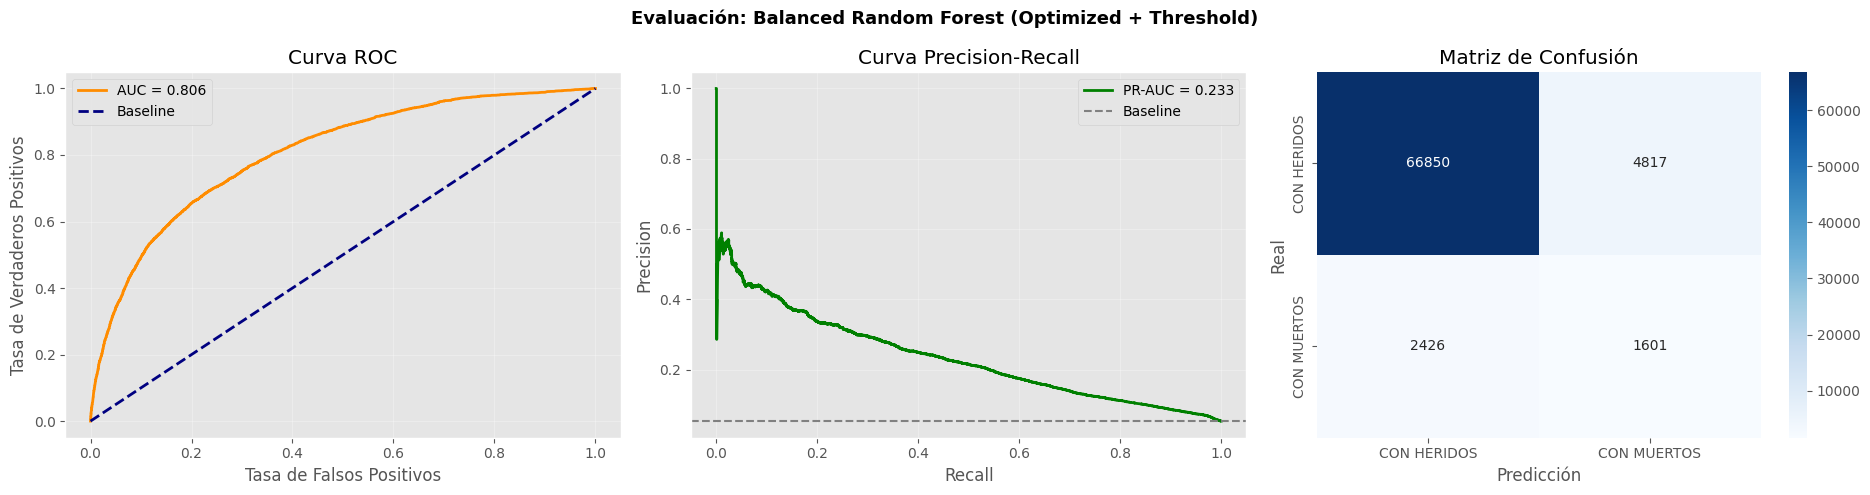

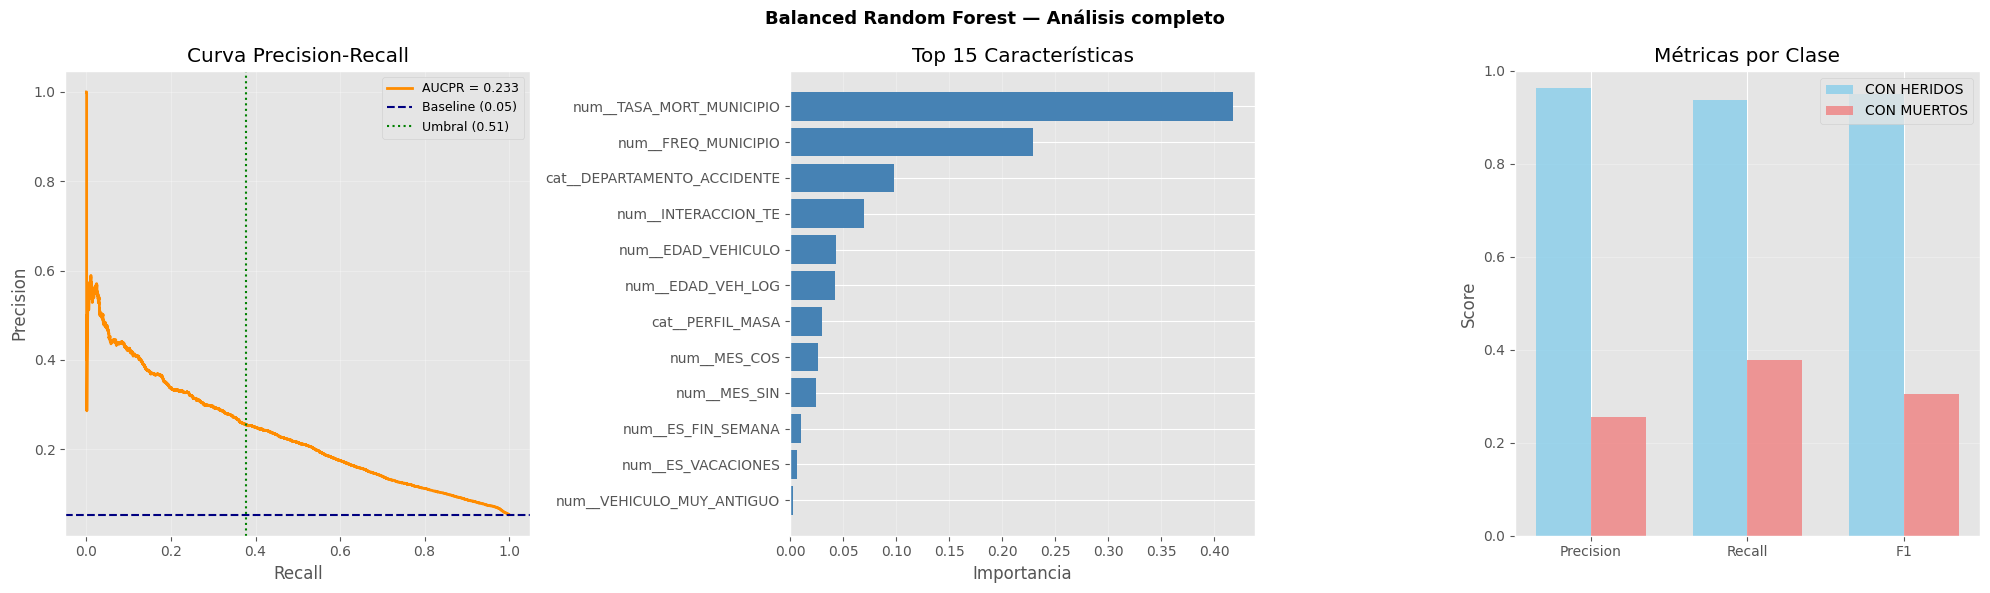


Top 10 características importantes:
                        feature  importance
7      num__TASA_MORT_MUNICIPIO      0.4178
8           num__FREQ_MUNICIPIO      0.2288
10  cat__DEPARTAMENTO_ACCIDENTE      0.0979
9           num__INTERACCION_TE      0.0700
0            num__EDAD_VEHICULO      0.0428
1             num__EDAD_VEH_LOG      0.0423
11             cat__PERFIL_MASA      0.0297
4                  num__MES_COS      0.0264
3                  num__MES_SIN      0.0247
6            num__ES_FIN_SEMANA      0.0103

Interpretabilidad con LIME - Balanced Random Forest

1. CASO CON MUERTOS correctamente clasificado


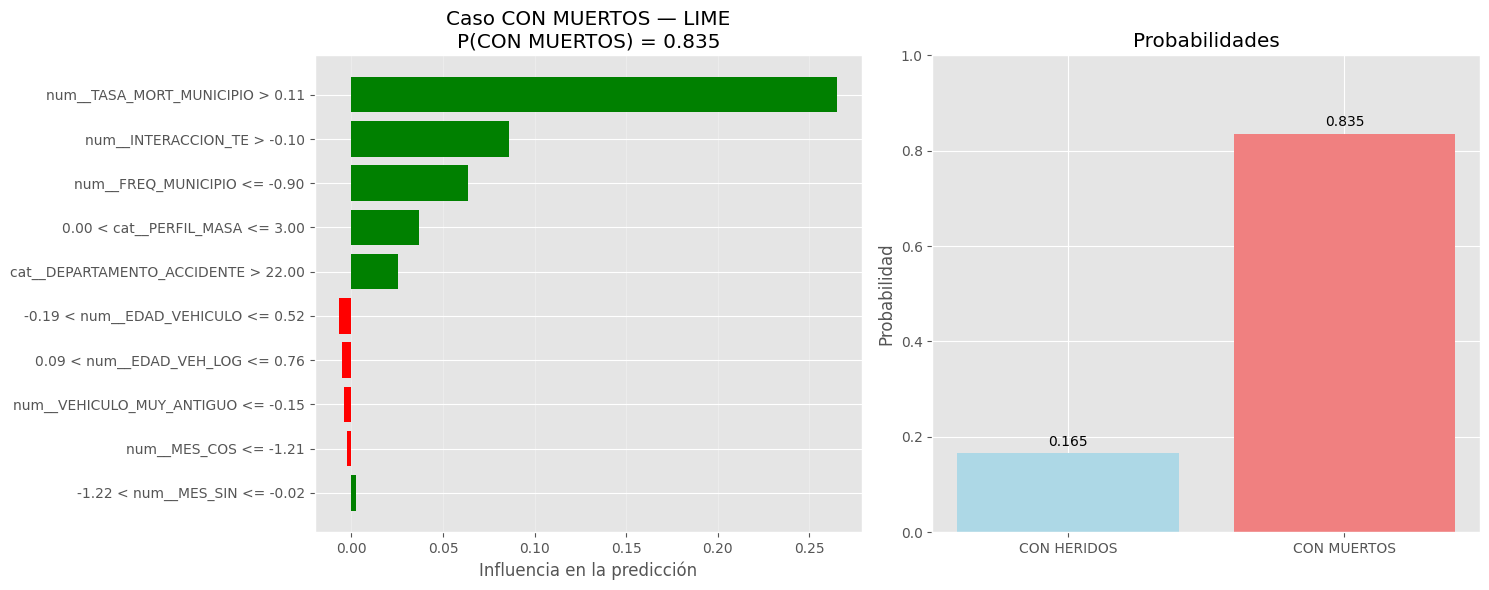


2. CASO CON HERIDOS correctamente clasificado


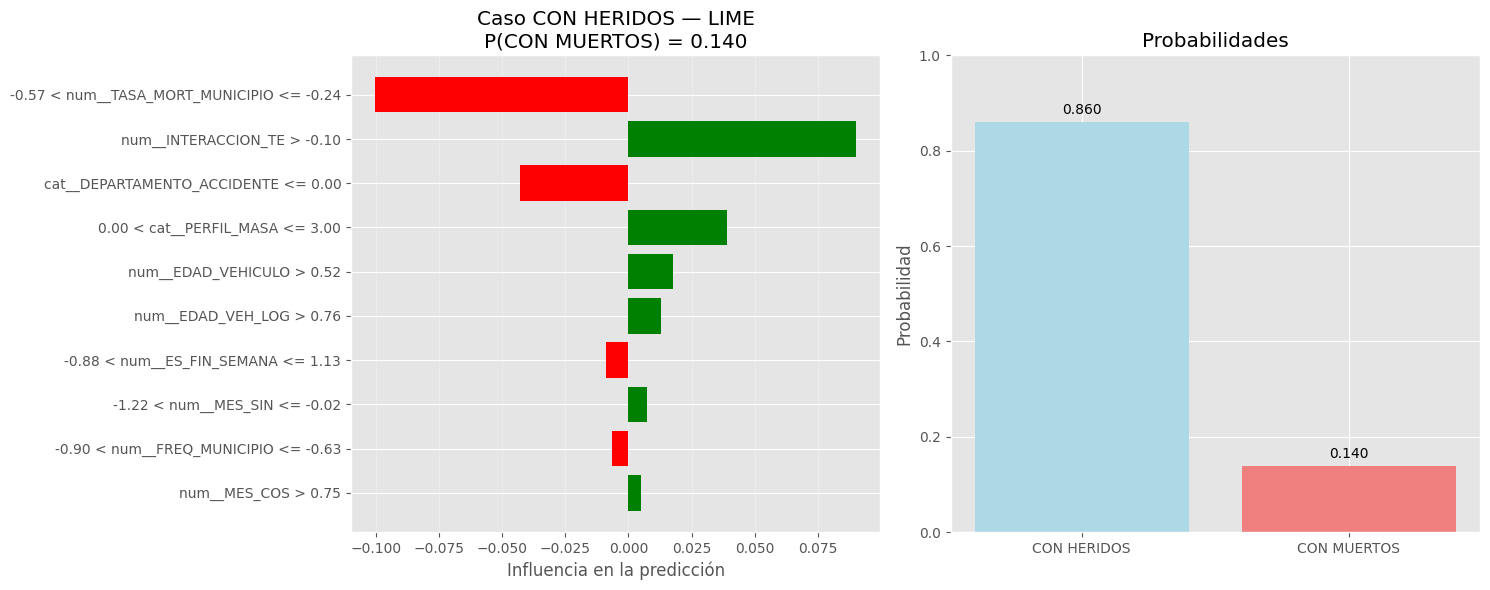

['model_brf.pkl']

In [20]:
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (make_scorer, f1_score, average_precision_score,
                             precision_recall_curve, precision_score, recall_score,
                             classification_report)
import lime
import lime.lime_tabular
import os, psutil

os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=False))

# ── RATIO ─────────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ── SUBMUESTRA 60% ────────────────────────────────────────────
X_tr_sub, _, y_tr_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("="*60)
print("SUBMUESTRA PARA BALANCED RANDOM FOREST")
print("="*60)
print(f"Train completo:  {X_train.shape[0]:,} registros")
print(f"Submuestra:      {X_tr_sub.shape[0]:,} registros")
print(f"HERIDOS:         {(y_tr_sub==0).sum():,} ({(y_tr_sub==0).mean()*100:.1f}%)")
print(f"MUERTOS:         {(y_tr_sub==1).sum():,} ({(y_tr_sub==1).mean()*100:.1f}%)")

# ── SPLIT VALIDACIÓN para threshold tuning ────────────────────
X_tr_cv, X_val_thresh, y_tr_cv, y_val_thresh = train_test_split(
    X_tr_sub, y_tr_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_tr_sub
)
print(f"\nTrain CV:        {X_tr_cv.shape[0]:,}")
print(f"Val threshold:   {X_val_thresh.shape[0]:,}")

# ── PIPELINE ──────────────────────────────────────────────────
pipe_brf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedRandomForestClassifier(
        random_state=RANDOM_STATE,
        replacement=True,
        n_jobs=-1,          # BRF en CPU sí soporta n_jobs=-1
        verbose=1
    ))
])

# ── PASO 1: RandomizedSearch (20 iter, 3 folds) ───────────────
param_grid_amplio = {
    "model__n_estimators":      [200, 300, 400, 500],
    "model__max_depth":         [5, 10, 15, None],
    "model__max_features":      ['sqrt', 'log2'],
    "model__min_samples_leaf":  [1, 2, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__sampling_strategy": ['auto', 0.3, 0.5, 0.75],
}

print("\n[PASO 1] RandomizedSearch (20 iter, 3 folds)...")
print("Estimado: ~1-1.5 horas\n")

random_search = RandomizedSearchCV(
    pipe_brf,
    param_grid_amplio,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro', zero_division=0),
    n_jobs=1,              # <-- CLAVE: evita el error de Windows
    random_state=RANDOM_STATE,
    verbose=1
)
random_search.fit(X_tr_cv, y_tr_cv)

best_params_paso1 = random_search.best_params_
print(f"\nMejores parámetros: {best_params_paso1}")
print(f"Mejor F1-MUERTOS:   {random_search.best_score_:.4f}")

# ── PASO 2: GridSearch fino ────────────────────────────────────
pipe_brf_fino = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedRandomForestClassifier(
        random_state=RANDOM_STATE,
        replacement=True,
        n_jobs=-1,
        n_estimators=           best_params_paso1['model__n_estimators'],
        max_depth=              best_params_paso1['model__max_depth'],
        max_features=           best_params_paso1['model__max_features'],
        min_samples_leaf=       best_params_paso1['model__min_samples_leaf'],
        min_samples_split=      best_params_paso1['model__min_samples_split'],
    ))
])

param_grid_fino = {
    "model__sampling_strategy": [0.3, 0.5, 0.75, 'auto'],
}

print("\n[PASO 2] GridSearch fino sobre sampling_strategy...")
grid_fino = GridSearchCV(
    pipe_brf_fino,
    param_grid_fino,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro', zero_division=0),
    n_jobs=1,              # <-- CLAVE
    verbose=1
)
grid_fino.fit(X_tr_cv, y_tr_cv)

print(f"\nMejor sampling_strategy: {grid_fino.best_params_}")
print(f"Mejor F1-MUERTOS paso 2: {grid_fino.best_score_:.4f}")

final_model = grid_fino.best_estimator_

# ── PASO 3: Threshold tuning sobre validación ─────────────────
print("\n[PASO 3] Threshold tuning...")
y_proba_val = final_model.predict_proba(X_val_thresh)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh, y_proba_val)

precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]
f1s            = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)

thresh_max_f1     = thresholds[np.argmax(f1s)]
mask              = precisions_cut >= 0.30
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 54)

resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1),
    ("Precision≥0.30",  thresh_min_prec),
    ("Equilibrio P=R",  thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p = precision_score(y_val_thresh, pred, pos_label=1, zero_division=0)
    r = recall_score(y_val_thresh,    pred, pos_label=1, zero_division=0)
    f = f1_score(y_val_thresh,        pred, pos_label=1, zero_division=0)
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': f, 'pred': pred}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")

# ── EVALUACIÓN FINAL ──────────────────────────────────────────
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred       = (y_proba_test >= best_thresh).astype(int)

aucpr       = average_precision_score(y_test, y_proba_test)
precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test,    y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test,    y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test,        y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)

print("\n" + "="*60)
print("RESULTADOS FINALES (Balanced Random Forest)")
print("="*60)
print(f"F1-MUERTOS:        {f1_1:.4f}")
print(f"Recall-MUERTOS:    {recall_1:.4f}")
print(f"Precision-MUERTOS: {precision_1:.4f}")
print(f"F1-Macro:          {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"AUCPR:             {aucpr:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

result = evaluate_model(
    final_model,
    X_tr_cv, X_test, y_tr_cv, y_test,
    model_name="Balanced Random Forest (Optimized + Threshold)",
    cv_folds=3,
    make_plots=True,
    refit=False
)
results.append(result)

# ── GRÁFICAS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Balanced Random Forest — Análisis completo", fontsize=13, fontweight='bold')

precisions_t, recalls_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[0].plot(recalls_t, precisions_t, color='darkorange', lw=2, label=f'AUCPR = {aucpr:.3f}')
axes[0].axhline(y=pos/(neg+pos), color='navy', linestyle='--', label=f'Baseline ({pos/(neg+pos):.2f})')
axes[0].axvline(x=recall_1, color='green', linestyle=':', label=f'Umbral ({best_thresh:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

feature_names_out = final_model.named_steps['preprocessor'].get_feature_names_out()
importances       = final_model.named_steps['model'].feature_importances_
importance_df     = pd.DataFrame({
    'feature': feature_names_out, 'importance': importances
}).sort_values('importance', ascending=False)
axes[1].barh(importance_df['feature'].head(15), importance_df['importance'].head(15), color='steelblue')
axes[1].set_title('Top 15 Características')
axes[1].set_xlabel('Importancia')
axes[1].invert_yaxis(); axes[1].grid(axis='x', alpha=0.3)

x = np.arange(3); width = 0.35
axes[2].bar(x - width/2, [precision_0, recall_0, f1_0], width,
            label=class_names[0], alpha=0.8, color='skyblue')
axes[2].bar(x + width/2, [precision_1, recall_1, f1_1], width,
            label=class_names[1], alpha=0.8, color='lightcoral')
axes[2].set_xticks(x); axes[2].set_xticklabels(['Precision', 'Recall', 'F1'])
axes[2].set_ylabel('Score'); axes[2].set_title('Métricas por Clase')
axes[2].legend(); axes[2].set_ylim(0, 1); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 10 características importantes:")
print(importance_df.head(10).round(4))

# ── LIME ──────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - Balanced Random Forest")

X_train_processed  = final_model.named_steps['preprocessor'].transform(X_tr_cv)
X_test_processed   = final_model.named_steps['preprocessor'].transform(X_test)
feature_names_lime = final_model.named_steps['preprocessor'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names_lime,
    class_names=class_names,
    mode='classification',
    random_state=RANDOM_STATE
)

predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)

def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]
    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features))); ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3); ax1.invert_yaxis()
    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad'); ax2.set_title('Probabilidades')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
if len(idx_1) > 0:
    i = idx_1[0]
    print(f"\n1. CASO {class_names[1]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_proba_test[i])

idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
if len(idx_0) > 0:
    i = idx_0[0]
    print(f"\n2. CASO {class_names[0]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_proba_test[i])


joblib.dump(final_model, "model_brf.pkl")

HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79
SUBMUESTRA PARA Balanced Bagging + LightGBM
Train completo:  302,776 registros
Submuestra:      181,665 registros
HERIDOS:         171,999 (94.7%)
MUERTOS:         9,666 (5.3%)

Train CV:        145,332
Val threshold:   36,333

ENTRENANDO Balanced Bagging BASE...
Tiempo base: 9.6s

Balanced Bagging BASE — Resultados en Test:
  F1-Macro:          0.5427
  F1-MUERTOS:        0.2313
  Recall-MUERTOS:    0.6938
  Precision-MUERTOS: 0.1388

[PASO 1] RandomizedSearch (15 iter, 3 folds)...
Estimado: ~30-60 min

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Tiempo búsqueda: 16.0 min
Mejores parámetros:  {'model__sampling_strategy': 0.5, 'model__replacement': False, 'model__n_estimators': 30, 'model__estimator__subsample': 0.8, 'model__estimator__num_leaves': 31, 'model__estimator__max_depth': 5, 'model__estimator__learning_rate': 0.1, 'model__estimator__colsample_bytree': 0.8}
Mejor F1-Macro (CV): 0.6173

[PASO 2] Threshold tuni

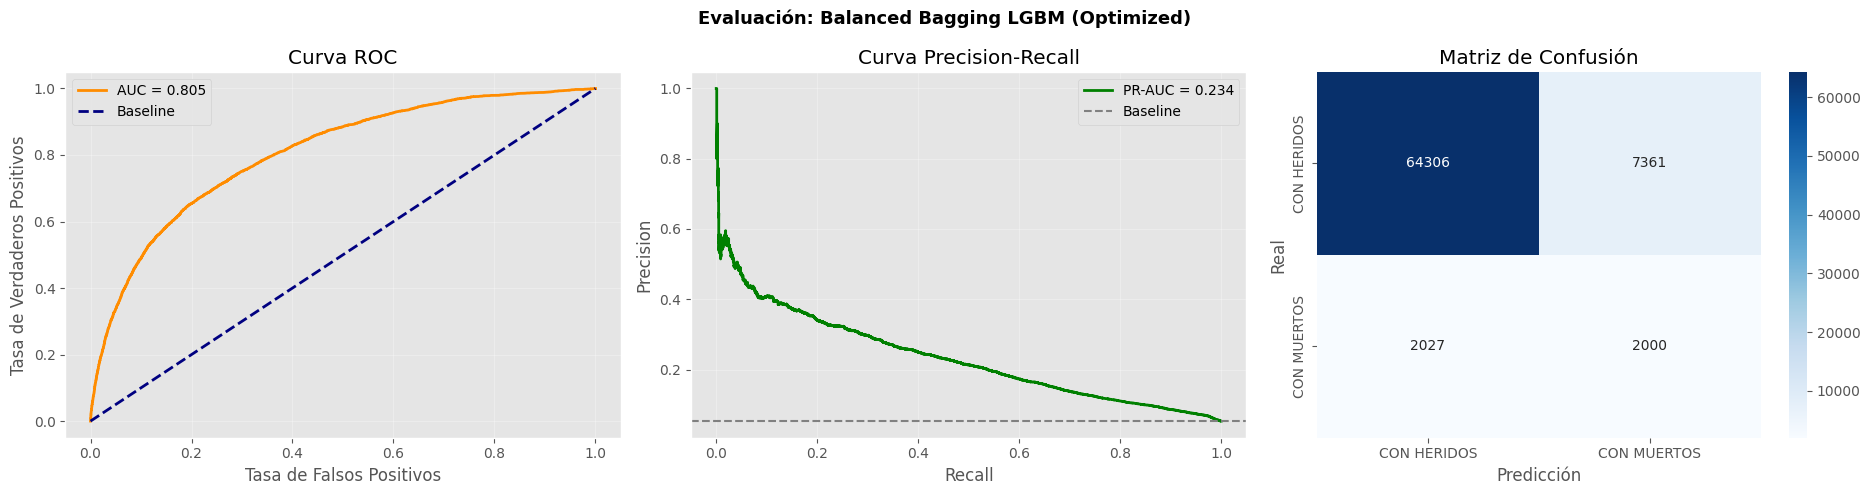

COMPARACIÓN BASE vs OPTIMIZADO
Métrica                         Base   Optimizado
--------------------------------------------------
F1-Macro                      0.5427       0.6284
F1-MUERTOS                    0.2313       0.3078
Recall-MUERTOS                0.6938       0.3976
Precision-MUERTOS             0.1388       0.2511

Mejora F1-Macro: +0.0857


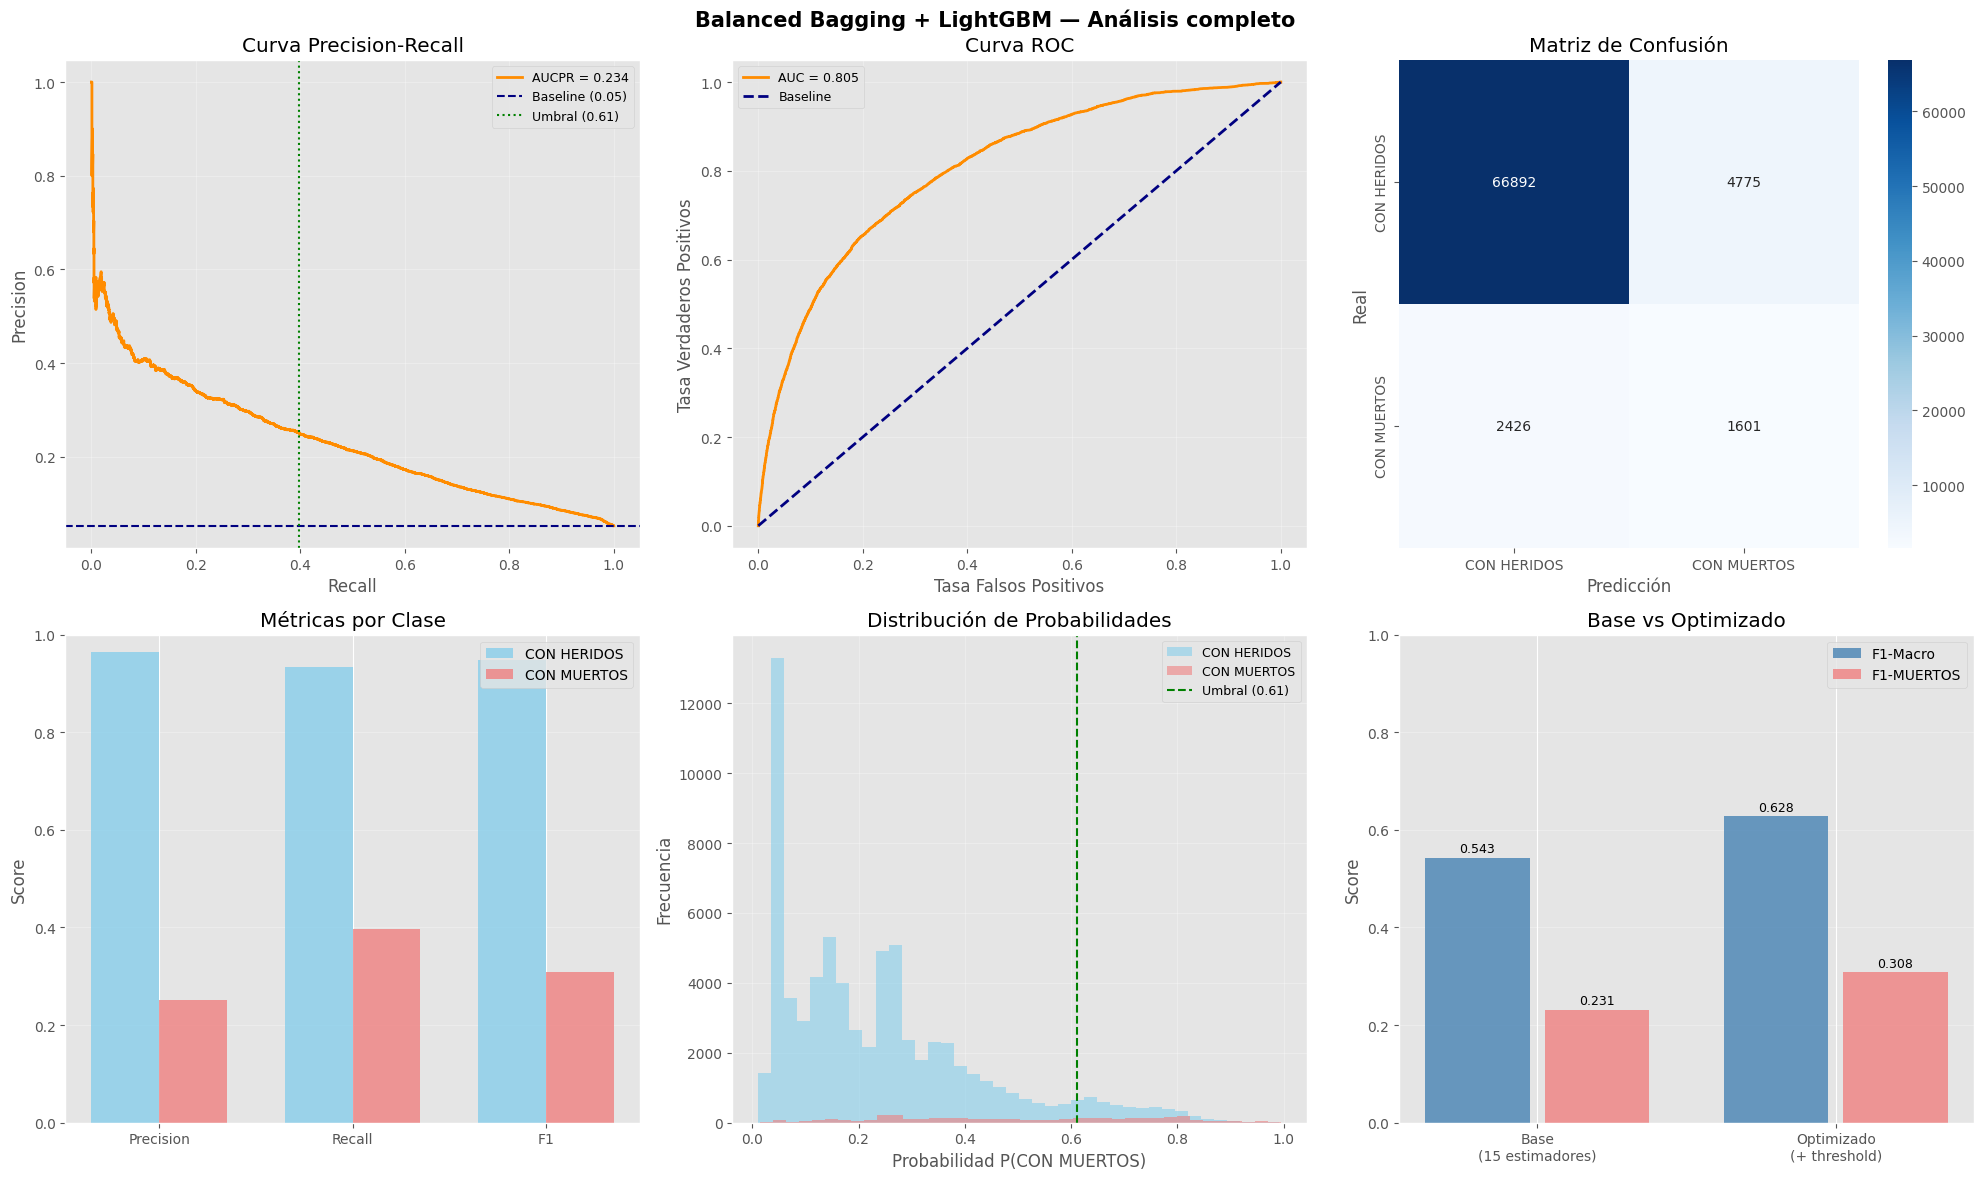


Interpretabilidad con LIME - Balanced Bagging + LightGBM

1. CASO CON MUERTOS correctamente clasificado


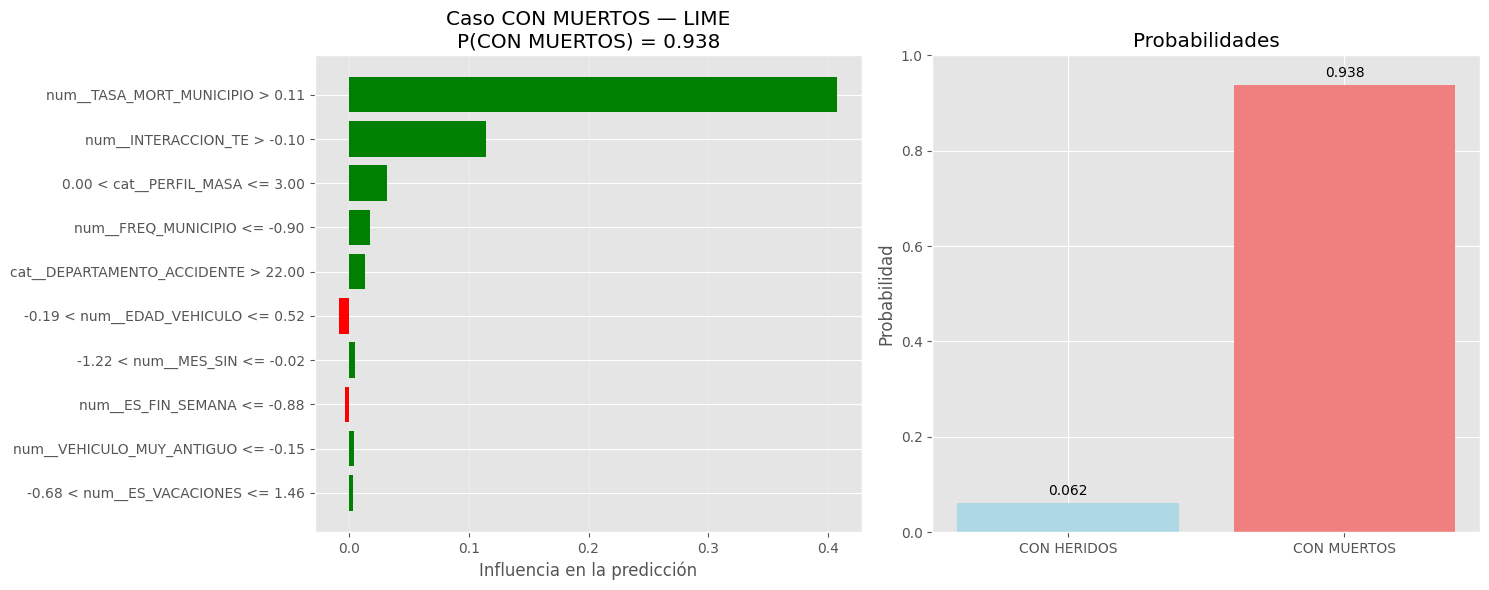


2. CASO CON HERIDOS correctamente clasificado


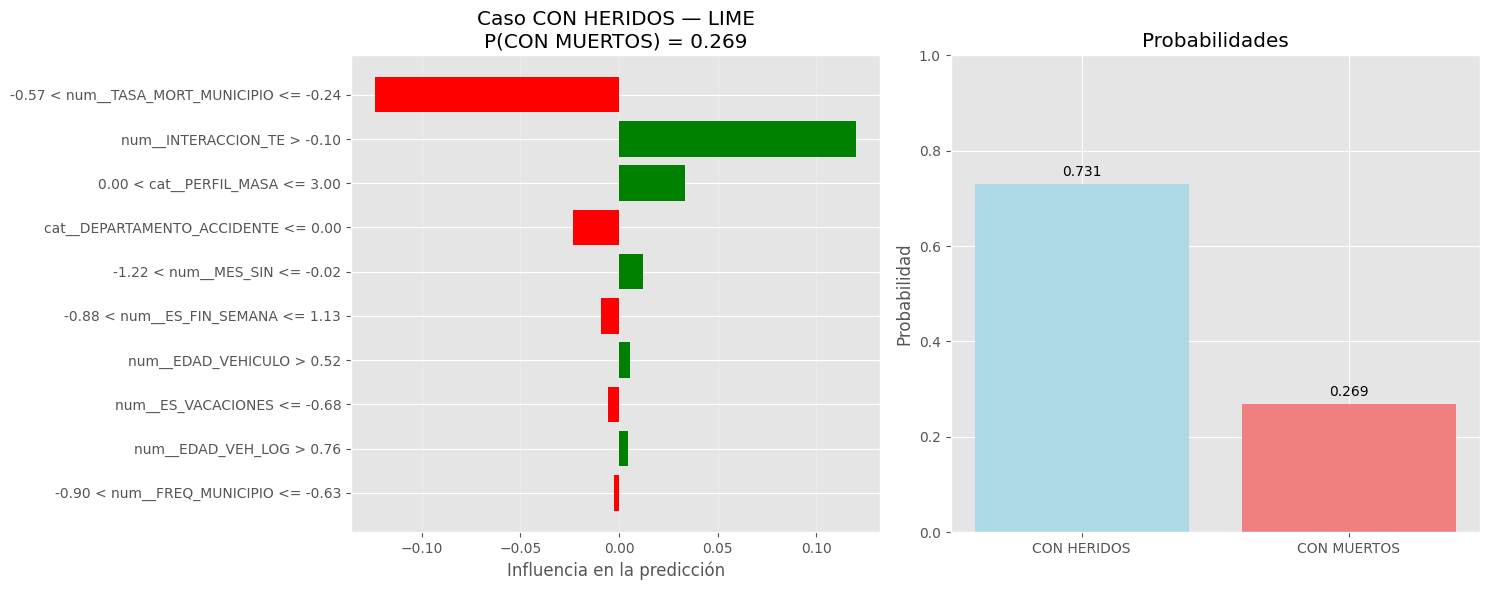

In [21]:
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    make_scorer, f1_score, average_precision_score,
    precision_recall_curve, precision_score, recall_score,
    classification_report, confusion_matrix
)
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os, psutil

os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=False))

# ── RATIO ─────────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ── SUBMUESTRA 60% ────────────────────────────────────────────
X_tr_sub, _, y_tr_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("="*60)
print("SUBMUESTRA PARA Balanced Bagging + LightGBM")
print("="*60)
print(f"Train completo:  {X_train.shape[0]:,} registros")
print(f"Submuestra:      {X_tr_sub.shape[0]:,} registros")
print(f"HERIDOS:         {(y_tr_sub==0).sum():,} ({(y_tr_sub==0).mean()*100:.1f}%)")
print(f"MUERTOS:         {(y_tr_sub==1).sum():,} ({(y_tr_sub==1).mean()*100:.1f}%)")

# ── SPLIT VALIDACIÓN para threshold tuning sin leakage ────────
X_tr_cv, X_val_thresh, y_tr_cv, y_val_thresh = train_test_split(
    X_tr_sub, y_tr_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_tr_sub
)
print(f"\nTrain CV:        {X_tr_cv.shape[0]:,}")
print(f"Val threshold:   {X_val_thresh.shape[0]:,}")

# ── PIPELINE BASE ─────────────────────────────────────────────
lgbm_base = lgb.LGBMClassifier(
    random_state=RANDOM_STATE,
    device='gpu',
    verbose=-1,
    n_jobs=1
)

pipe_bb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedBaggingClassifier(
        estimator=lgbm_base,
        n_estimators=15,
        sampling_strategy='auto',
        replacement=False,
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

print("\n" + "="*60)
print("ENTRENANDO Balanced Bagging BASE...")
print("="*60)

start = time.time()
pipe_bb.fit(X_tr_cv, y_tr_cv)
print(f"Tiempo base: {time.time()-start:.1f}s")

y_pred_base  = pipe_bb.predict(X_test)
y_proba_base = pipe_bb.predict_proba(X_test)[:, 1]

print("\nBalanced Bagging BASE — Resultados en Test:")
print(f"  F1-Macro:          {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"  F1-MUERTOS:        {f1_score(y_test, y_pred_base, pos_label=1):.4f}")
print(f"  Recall-MUERTOS:    {recall_score(y_test, y_pred_base, pos_label=1):.4f}")
print(f"  Precision-MUERTOS: {precision_score(y_test, y_pred_base, pos_label=1, zero_division=0):.4f}")

# ── PASO 1: RandomizedSearch ──────────────────────────────────
param_grid = {
    "model__n_estimators":               [15, 30, 50],
    "model__sampling_strategy":          ['auto', 0.5, 0.75],
    "model__replacement":                [True, False],
    "model__estimator__max_depth":       [3, 5, 7],
    "model__estimator__learning_rate":   [0.05, 0.1],
    "model__estimator__num_leaves":      [31, 63],
    "model__estimator__subsample":       [0.8, 0.9],
    "model__estimator__colsample_bytree":[0.8, 0.9],
}

print("\n[PASO 1] RandomizedSearch (15 iter, 3 folds)...")
print("Estimado: ~30-60 min\n")

random_search = RandomizedSearchCV(
    pipe_bb,
    param_grid,
    n_iter=15,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro'),
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

start = time.time()
random_search.fit(X_tr_cv, y_tr_cv)
print(f"\nTiempo búsqueda: {(time.time()-start)/60:.1f} min")
print(f"Mejores parámetros:  {random_search.best_params_}")
print(f"Mejor F1-Macro (CV): {random_search.best_score_:.4f}")

final_model = random_search.best_estimator_

# ── PASO 2: Threshold tuning sobre validación ─────────────────
print("\n[PASO 2] Threshold tuning sobre validación...")
y_proba_val = final_model.predict_proba(X_val_thresh)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh, y_proba_val)

precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]
f1s            = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)

thresh_max_f1     = thresholds[np.argmax(f1s)]
mask              = precisions_cut >= 0.30
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1-Macro':>10}")
print("-" * 54)

resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1),
    ("Precision≥0.30",  thresh_min_prec),
    ("Equilibrio P=R",  thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p  = precision_score(y_val_thresh, pred, pos_label=1, zero_division=0)
    r  = recall_score(y_val_thresh,    pred, pos_label=1, zero_division=0)
    fm = f1_score(y_val_thresh,        pred, average='macro')
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': fm, 'pred': pred}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {fm:>10.4f}")

mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")

# ── EVALUACIÓN FINAL en X_test ────────────────────────────────
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred       = (y_proba_test >= best_thresh).astype(int)

aucpr       = average_precision_score(y_test, y_proba_test)
precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test,    y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test,    y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test,        y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)
f1_macro    = f1_score(y_test,        y_pred, average='macro')

print("\n" + "="*60)
print("RESULTADOS FINALES (Balanced Bagging + LightGBM)")
print("="*60)
print(f"F1-Macro:          {f1_macro:.4f}")
print(f"F1-MUERTOS:        {f1_1:.4f}")
print(f"Recall-MUERTOS:    {recall_1:.4f}")
print(f"Precision-MUERTOS: {precision_1:.4f}")
print(f"AUCPR:             {aucpr:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

result = evaluate_model(
    final_model,
    X_tr_cv, X_test, y_tr_cv, y_test,
    model_name="Balanced Bagging LGBM (Optimized)",
    cv_folds=3,
    make_plots=True,
    refit=False
)
results.append(result)

# ── COMPARACIÓN BASE vs OPTIMIZADO ────────────────────────────
print("="*60)
print("COMPARACIÓN BASE vs OPTIMIZADO")
print("="*60)

f1_macro_base = f1_score(y_test, y_pred_base, average='macro')
f1_macro_opt  = f1_score(y_test, y_pred,      average='macro')
f1_base_min   = f1_score(y_test, y_pred_base, pos_label=1)
f1_opt_min    = f1_score(y_test, y_pred,      pos_label=1)

print(f"{'Métrica':<25} {'Base':>10} {'Optimizado':>12}")
print("-" * 50)
print(f"{'F1-Macro':<25} {f1_macro_base:>10.4f} {f1_macro_opt:>12.4f}")
print(f"{'F1-MUERTOS':<25} {f1_base_min:>10.4f} {f1_opt_min:>12.4f}")
print(f"{'Recall-MUERTOS':<25} {recall_score(y_test, y_pred_base, pos_label=1):>10.4f} {recall_1:>12.4f}")
print(f"{'Precision-MUERTOS':<25} {precision_score(y_test, y_pred_base, pos_label=1, zero_division=0):>10.4f} {precision_1:>12.4f}")
print(f"\nMejora F1-Macro: {f1_macro_opt - f1_macro_base:+.4f}")

# ── GRÁFICAS ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Balanced Bagging + LightGBM — Análisis completo', fontsize=15, fontweight='bold')

# 1. Curva Precision-Recall
precisions_t, recalls_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[0, 0].plot(recalls_t, precisions_t, color='darkorange', lw=2, label=f'AUCPR = {aucpr:.3f}')
axes[0, 0].axhline(y=pos/(neg+pos), color='navy', linestyle='--', label=f'Baseline ({pos/(neg+pos):.2f})')
axes[0, 0].axvline(x=recall_1, color='green', linestyle=':', label=f'Umbral ({best_thresh:.2f})')
axes[0, 0].set_xlabel('Recall'); axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Curva Precision-Recall')
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(alpha=0.3)

# 2. Curva ROC
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc_val      = roc_auc_score(y_test, y_proba_test)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_val:.3f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Baseline')
axes[0, 1].set_xlabel('Tasa Falsos Positivos'); axes[0, 1].set_ylabel('Tasa Verdaderos Positivos')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend(fontsize=9); axes[0, 1].grid(alpha=0.3)

# 3. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2],
            xticklabels=class_names, yticklabels=class_names)
axes[0, 2].set_title('Matriz de Confusión')
axes[0, 2].set_xlabel('Predicción'); axes[0, 2].set_ylabel('Real')

# 4. Métricas por clase
x = np.arange(3); width = 0.35
axes[1, 0].bar(x - width/2, [precision_0, recall_0, f1_0], width,
               label=class_names[0], alpha=0.8, color='skyblue')
axes[1, 0].bar(x + width/2, [precision_1, recall_1, f1_1], width,
               label=class_names[1], alpha=0.8, color='lightcoral')
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(['Precision', 'Recall', 'F1'])
axes[1, 0].set_ylabel('Score'); axes[1, 0].set_title('Métricas por Clase')
axes[1, 0].legend(); axes[1, 0].set_ylim(0, 1); axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Distribución de probabilidades
axes[1, 1].hist(y_proba_test[y_test == 0], bins=40, alpha=0.6,
                label=class_names[0], color='skyblue')
axes[1, 1].hist(y_proba_test[y_test == 1], bins=40, alpha=0.6,
                label=class_names[1], color='lightcoral')
axes[1, 1].axvline(x=best_thresh, color='green', linestyle='--',
                   label=f'Umbral ({best_thresh:.2f})')
axes[1, 1].set_xlabel('Probabilidad P(CON MUERTOS)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Probabilidades')
axes[1, 1].legend(fontsize=9); axes[1, 1].grid(alpha=0.3)

# 6. Comparación Base vs Optimizado
modelos   = ['Base\n(15 estimadores)', 'Optimizado\n(+ threshold)']
f1_macros = [f1_macro_base, f1_macro_opt]
f1_mins   = [f1_base_min,   f1_opt_min]

x_comp = np.arange(len(modelos))
bars1  = axes[1, 2].bar(x_comp - 0.2, f1_macros, 0.35, label='F1-Macro',   color='steelblue',  alpha=0.8)
bars2  = axes[1, 2].bar(x_comp + 0.2, f1_mins,   0.35, label='F1-MUERTOS', color='lightcoral', alpha=0.8)
for bar in bars1 + bars2:
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
axes[1, 2].set_xticks(x_comp); axes[1, 2].set_xticklabels(modelos)
axes[1, 2].set_ylabel('Score'); axes[1, 2].set_title('Base vs Optimizado')
axes[1, 2].legend(); axes[1, 2].set_ylim(0, 1); axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── LIME ──────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - Balanced Bagging + LightGBM")

X_train_processed  = final_model.named_steps['preprocessor'].transform(X_tr_cv)
X_test_processed   = final_model.named_steps['preprocessor'].transform(X_test)
feature_names_lime = final_model.named_steps['preprocessor'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names_lime,
    class_names=class_names,
    mode='classification',
    random_state=RANDOM_STATE
)

# BalancedBaggingClassifier en inferencia no hace resampling
# predict_proba promedia directamente los estimadores base
predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)

def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]
    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features))); ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3); ax1.invert_yaxis()
    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad'); ax2.set_title('Probabilidades')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
if len(idx_1) > 0:
    i = idx_1[0]
    print(f"\n1. CASO {class_names[1]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_proba_test[i])

idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
if len(idx_0) > 0:
    i = idx_0[0]
    print(f"\n2. CASO {class_names[0]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_proba_test[i])

ISOLATION FOREST — Detector de Accidentes Fatales como Anomalías

[PASO 1] Transformando features con el preprocessor existente...
  Shape train procesado: (302776, 12)
  Shape test  procesado: (75694, 12)

[PASO 2] Entrenando Isolation Forest sobre clase HERIDOS (normal)...
  Tasa de positivos (MUERTOS) en train: 0.0532
  → contamination fijado en: 0.0532
  Isolation Forest entrenado.

[PASO 3] Calculando scores de anomalía...
  Score medio HERIDOS  (train): 0.2276
  Score medio MUERTOS  (train): 0.3334
  → Separación entre clases: 0.1059

  ROC-AUC (train): 0.6884
  ROC-AUC (test):  0.6888

[PASO 4] Threshold tuning sobre subconjunto de validación...

Estrategia              Precision     Recall   F1-Macro
------------------------------------------------------
Default (0.5)              0.1834     0.1515     0.5617
Máx F1                     0.1539     0.3454     0.5693
Precision≥0.30             0.3077     0.0025     0.4888
Equilibrio P=R             0.1831     0.1831     0.5686

Es

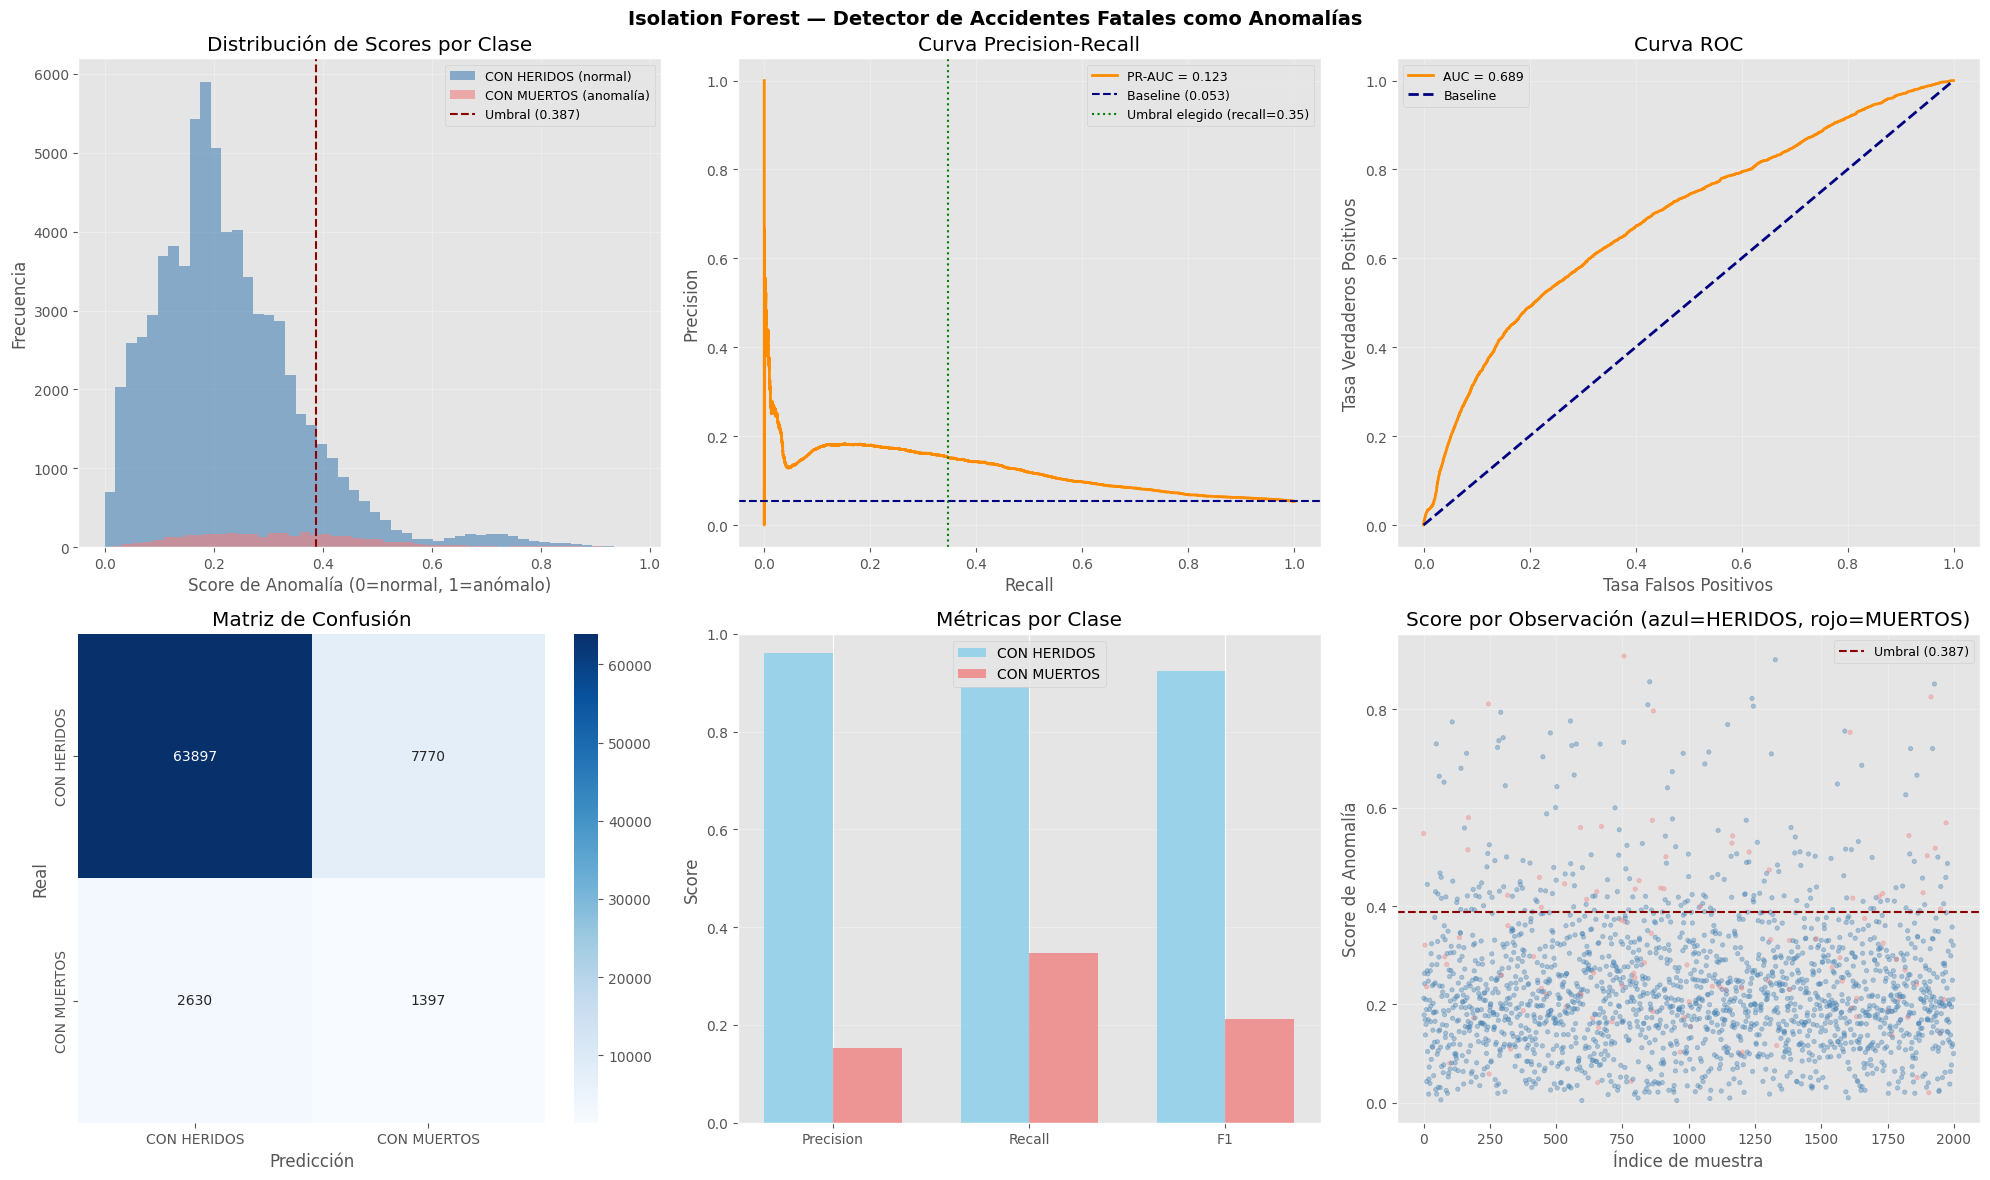


✓ Resultado agregado a 'results' con el mismo formato del proyecto.
  Total modelos evaluados hasta ahora: 7


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# ISOLATION FOREST — Enfoque de Anomalías para Accidentes Fatales
# ══════════════════════════════════════════════════════════════════════════════
# Paradigma: los accidentes CON MUERTOS (~1-5%) son "anomalías" con
# combinaciones de features físicas raras. Isolation Forest las aísla
# construyendo árboles aleatorios — necesitan MENOS cortes para ser aisladas.
# Se usa como scorer de anomalía → convertido a probabilidad → threshold tuning.
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, classification_report,
    precision_recall_curve, roc_auc_score, confusion_matrix
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("ISOLATION FOREST — Detector de Accidentes Fatales como Anomalías")
print("=" * 60)

# ── PASO 1: Preprocesar con el preprocessor ya entrenado ──────────────────────
# Usamos el mismo preprocessor del proyecto (ya fiteado sobre X_train)
# para no romper la estructura ni introducir leakage.

print("\n[PASO 1] Transformando features con el preprocessor existente...")
preprocessor.fit(X_train, y_train)  # re-fit por si no estaba fiteado en este scope

X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"  Shape train procesado: {X_train_proc.shape}")
print(f"  Shape test  procesado: {X_test_proc.shape}")

# ── PASO 2: Entrenar Isolation Forest SOLO sobre la clase mayoritaria ─────────
# Lógica: le enseñamos qué es "normal" (accidentes CON HERIDOS).
# Los accidentes CON MUERTOS tienen combinaciones de features tan raras
# que el bosque los aisla con menos particiones → score de anomalía alto.

print("\n[PASO 2] Entrenando Isolation Forest sobre clase HERIDOS (normal)...")

# contamination = proporción esperada de anomalías en el dataset
tasa_positivos = y_train.mean()
print(f"  Tasa de positivos (MUERTOS) en train: {tasa_positivos:.4f}")
print(f"  → contamination fijado en: {tasa_positivos:.4f}")

# Entrenamos SOLO sobre los registros CON HERIDOS (clase normal)
X_train_normal = X_train_proc[y_train.values == 0]

iso_forest = IsolationForest(
    n_estimators=300,          # Más árboles = scores más estables
    contamination=tasa_positivos,
    max_samples='auto',        # Por defecto min(256, n_samples)
    max_features=1.0,          # Usar todas las features
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_forest.fit(X_train_normal)
print("  Isolation Forest entrenado.")

# ── PASO 3: Calcular scores de anomalía en train y test ───────────────────────
# decision_function → score negativo = más anómalo
# Convertimos a [0, 1]: score alto = más probable que sea fatal

print("\n[PASO 3] Calculando scores de anomalía...")

# Score raw: más negativo = más anómalo (peor ajuste al patrón normal)
score_train_raw = iso_forest.decision_function(X_train_proc)
score_test_raw  = iso_forest.decision_function(X_test_proc)

# Invertimos y normalizamos a [0, 1] para interpretarlo como P(anomalía)
scaler_iso = MinMaxScaler()
score_train_norm = scaler_iso.fit_transform(-score_train_raw.reshape(-1, 1)).ravel()
score_test_norm  = scaler_iso.transform(-score_test_raw.reshape(-1, 1)).ravel()

print(f"  Score medio HERIDOS  (train): {score_train_norm[y_train.values == 0].mean():.4f}")
print(f"  Score medio MUERTOS  (train): {score_train_norm[y_train.values == 1].mean():.4f}")
print(f"  → Separación entre clases: {score_train_norm[y_train.values==1].mean() - score_train_norm[y_train.values==0].mean():.4f}")

# AUC como primera validación del poder discriminativo
auc_train = roc_auc_score(y_train, score_train_norm)
auc_test  = roc_auc_score(y_test,  score_test_norm)
print(f"\n  ROC-AUC (train): {auc_train:.4f}")
print(f"  ROC-AUC (test):  {auc_test:.4f}")

# ── PASO 4: Threshold tuning sobre validación interna ────────────────────────
# Mismo patrón que el resto del proyecto: split val desde train, tuning sin leakage.

print("\n[PASO 4] Threshold tuning sobre subconjunto de validación...")

from sklearn.model_selection import train_test_split

_, X_val_iso, _, y_val_iso, _, score_val_iso = train_test_split(
    X_train_proc, y_train, score_train_norm,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

precisions_iso, recalls_iso, thresholds_iso = precision_recall_curve(y_val_iso, score_val_iso)

precisions_cut_iso = precisions_iso[:-1]
recalls_cut_iso    = recalls_iso[:-1]
f1s_iso = 2 * (precisions_cut_iso * recalls_cut_iso) / (precisions_cut_iso + recalls_cut_iso + 1e-9)

thresh_max_f1_iso   = thresholds_iso[np.argmax(f1s_iso)]
mask_prec_iso       = precisions_cut_iso >= 0.30
thresh_min_prec_iso = (thresholds_iso[mask_prec_iso][np.argmax(recalls_cut_iso[mask_prec_iso])]
                       if mask_prec_iso.any() else thresh_max_f1_iso)
thresh_equil_iso    = thresholds_iso[np.argmin(np.abs(precisions_cut_iso - recalls_cut_iso))]

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1-Macro':>10}")
print("-" * 54)

resultados_thresh_iso = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1_iso),
    ("Precision≥0.30",  thresh_min_prec_iso),
    ("Equilibrio P=R",  thresh_equil_iso),
]:
    pred = (score_val_iso >= thresh).astype(int)
    p  = precision_score(y_val_iso, pred, pos_label=1, zero_division=0)
    r  = recall_score(y_val_iso,    pred, pos_label=1, zero_division=0)
    fm = f1_score(y_val_iso,        pred, average='macro')
    resultados_thresh_iso[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': fm}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {fm:>10.4f}")

mejor_iso   = max(resultados_thresh_iso, key=lambda k: resultados_thresh_iso[k]['f1'])
best_thresh_iso = resultados_thresh_iso[mejor_iso]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_iso}' (thresh={best_thresh_iso:.3f})")

# ── PASO 5: Evaluación final en TEST ─────────────────────────────────────────

print("\n" + "=" * 60)
print("EVALUACIÓN FINAL — Isolation Forest en TEST SET")
print("=" * 60)

y_pred_iso = (score_test_norm >= best_thresh_iso).astype(int)

f1_macro_iso  = f1_score(y_test, y_pred_iso, average='macro')
f1_muertos    = f1_score(y_test, y_pred_iso, pos_label=1, zero_division=0)
recall_muertos  = recall_score(y_test,    y_pred_iso, pos_label=1, zero_division=0)
prec_muertos    = precision_score(y_test, y_pred_iso, pos_label=1, zero_division=0)
aucpr_iso       = average_precision_score(y_test, score_test_norm)

print(f"  F1-Macro:          {f1_macro_iso:.4f}  ← PRINCIPAL")
print(f"  F1-MUERTOS:        {f1_muertos:.4f}")
print(f"  Recall-MUERTOS:    {recall_muertos:.4f}")
print(f"  Precision-MUERTOS: {prec_muertos:.4f}")
print(f"  ROC-AUC:           {auc_test:.4f}")
print(f"  PR-AUC:            {aucpr_iso:.4f}")
print(f"\n{classification_report(y_test, y_pred_iso, target_names=class_names)}")

# ── PASO 6: Gráficas ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Isolation Forest — Detector de Accidentes Fatales como Anomalías",
             fontsize=14, fontweight='bold')

# 1. Distribución de scores por clase
axes[0, 0].hist(score_test_norm[y_test.values == 0], bins=50, alpha=0.6,
                label='CON HERIDOS (normal)', color='steelblue')
axes[0, 0].hist(score_test_norm[y_test.values == 1], bins=50, alpha=0.6,
                label='CON MUERTOS (anomalía)', color='lightcoral')
axes[0, 0].axvline(x=best_thresh_iso, color='darkred', linestyle='--',
                   label=f'Umbral ({best_thresh_iso:.3f})')
axes[0, 0].set_xlabel('Score de Anomalía (0=normal, 1=anómalo)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Scores por Clase')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

# 2. Curva Precision-Recall
precisions_t, recalls_t, _ = precision_recall_curve(y_test, score_test_norm)
neg_iso = (y_test == 0).sum()
pos_iso = (y_test == 1).sum()
axes[0, 1].plot(recalls_t, precisions_t, color='darkorange', lw=2,
                label=f'PR-AUC = {aucpr_iso:.3f}')
axes[0, 1].axhline(y=pos_iso / (neg_iso + pos_iso), color='navy',
                   linestyle='--', label=f'Baseline ({pos_iso/(neg_iso+pos_iso):.3f})')
axes[0, 1].axvline(x=recall_muertos, color='green', linestyle=':',
                   label=f'Umbral elegido (recall={recall_muertos:.2f})')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Curva Precision-Recall')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# 3. Curva ROC
from sklearn.metrics import roc_curve
fpr_iso, tpr_iso, _ = roc_curve(y_test, score_test_norm)
axes[0, 2].plot(fpr_iso, tpr_iso, color='darkorange', lw=2,
                label=f'AUC = {auc_test:.3f}')
axes[0, 2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Baseline')
axes[0, 2].set_xlabel('Tasa Falsos Positivos')
axes[0, 2].set_ylabel('Tasa Verdaderos Positivos')
axes[0, 2].set_title('Curva ROC')
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(alpha=0.3)

# 4. Matriz de confusión
cm_iso = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=class_names, yticklabels=class_names)
axes[1, 0].set_title('Matriz de Confusión')
axes[1, 0].set_xlabel('Predicción')
axes[1, 0].set_ylabel('Real')

# 5. Métricas por clase
f1_heridos   = f1_score(y_test, y_pred_iso, pos_label=0, zero_division=0)
prec_heridos = precision_score(y_test, y_pred_iso, pos_label=0, zero_division=0)
rec_heridos  = recall_score(y_test, y_pred_iso, pos_label=0, zero_division=0)

x_m = np.arange(3)
width_m = 0.35
axes[1, 1].bar(x_m - width_m/2, [prec_heridos,  rec_heridos,  f1_heridos],  width_m,
               label=class_names[0], alpha=0.8, color='skyblue')
axes[1, 1].bar(x_m + width_m/2, [prec_muertos, recall_muertos, f1_muertos], width_m,
               label=class_names[1], alpha=0.8, color='lightcoral')
axes[1, 1].set_xticks(x_m)
axes[1, 1].set_xticklabels(['Precision', 'Recall', 'F1'])
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Métricas por Clase')
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Score de anomalía vs profundidad de aislamiento (muestra aleatoria)
sample_idx = np.random.choice(len(score_test_norm), size=min(2000, len(score_test_norm)), replace=False)
colors_sample = ['lightcoral' if y == 1 else 'steelblue' for y in y_test.values[sample_idx]]
axes[1, 2].scatter(range(len(sample_idx)), score_test_norm[sample_idx],
                   c=colors_sample, alpha=0.4, s=10)
axes[1, 2].axhline(y=best_thresh_iso, color='darkred', linestyle='--',
                   label=f'Umbral ({best_thresh_iso:.3f})')
axes[1, 2].set_xlabel('Índice de muestra')
axes[1, 2].set_ylabel('Score de Anomalía')
axes[1, 2].set_title('Score por Observación (azul=HERIDOS, rojo=MUERTOS)')
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── PASO 7: Acumular en results (mismo formato que el resto del proyecto) ─────

result_iso = {
    'model_name':           'Isolation Forest (Anomaly Detection)',
    'cv_f1_macro_mean':     np.nan,   # IF no hace CV estándar
    'cv_f1_macro_std':      np.nan,
    'test_f1_macro':        f1_macro_iso,
    'test_f1_muertos':      f1_muertos,
    'test_recall_muertos':  recall_muertos,
    'test_precision_muertos': prec_muertos,
    'test_roc_auc':         auc_test,
    'test_pr_auc':          aucpr_iso,
    'threshold_used':       best_thresh_iso,
}

results.append(result_iso)

print("\n✓ Resultado agregado a 'results' con el mismo formato del proyecto.")
print(f"  Total modelos evaluados hasta ahora: {len(results)}")

RUSBOOST — Tuning Exhaustivo de Threshold
HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.8

Train RUS: 242,220 | Val threshold: 60,556

[PASO 3] RandomizedSearch (20 iter, 3 folds) — scorer: F1-MUERTOS...
Estimado: ~5-15 min

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Tiempo búsqueda: 22.9 min
Mejores parámetros: {'model__sampling_strategy': 0.3, 'model__n_estimators': 300, 'model__learning_rate': 0.1, 'model__estimator__min_samples_leaf': 1, 'model__estimator__max_depth': 1}
Mejor F1-MUERTOS (CV): 0.3183

[PASO 4] Threshold sweep sobre validación interna...

Estrategia                    Threshold  Precision     Recall   F1-MUERTOS   F1-Macro
----------------------------------------------------------------------------------
Default (0.5)                     0.500     0.2944     0.3752       0.3300     0.6434
Máx F1-MUERTOS                    0.500     0.3006     0.3696       0.3316     0.6447
Máx F1-Macro                      0.500     0.3006     0.3696       0.3316

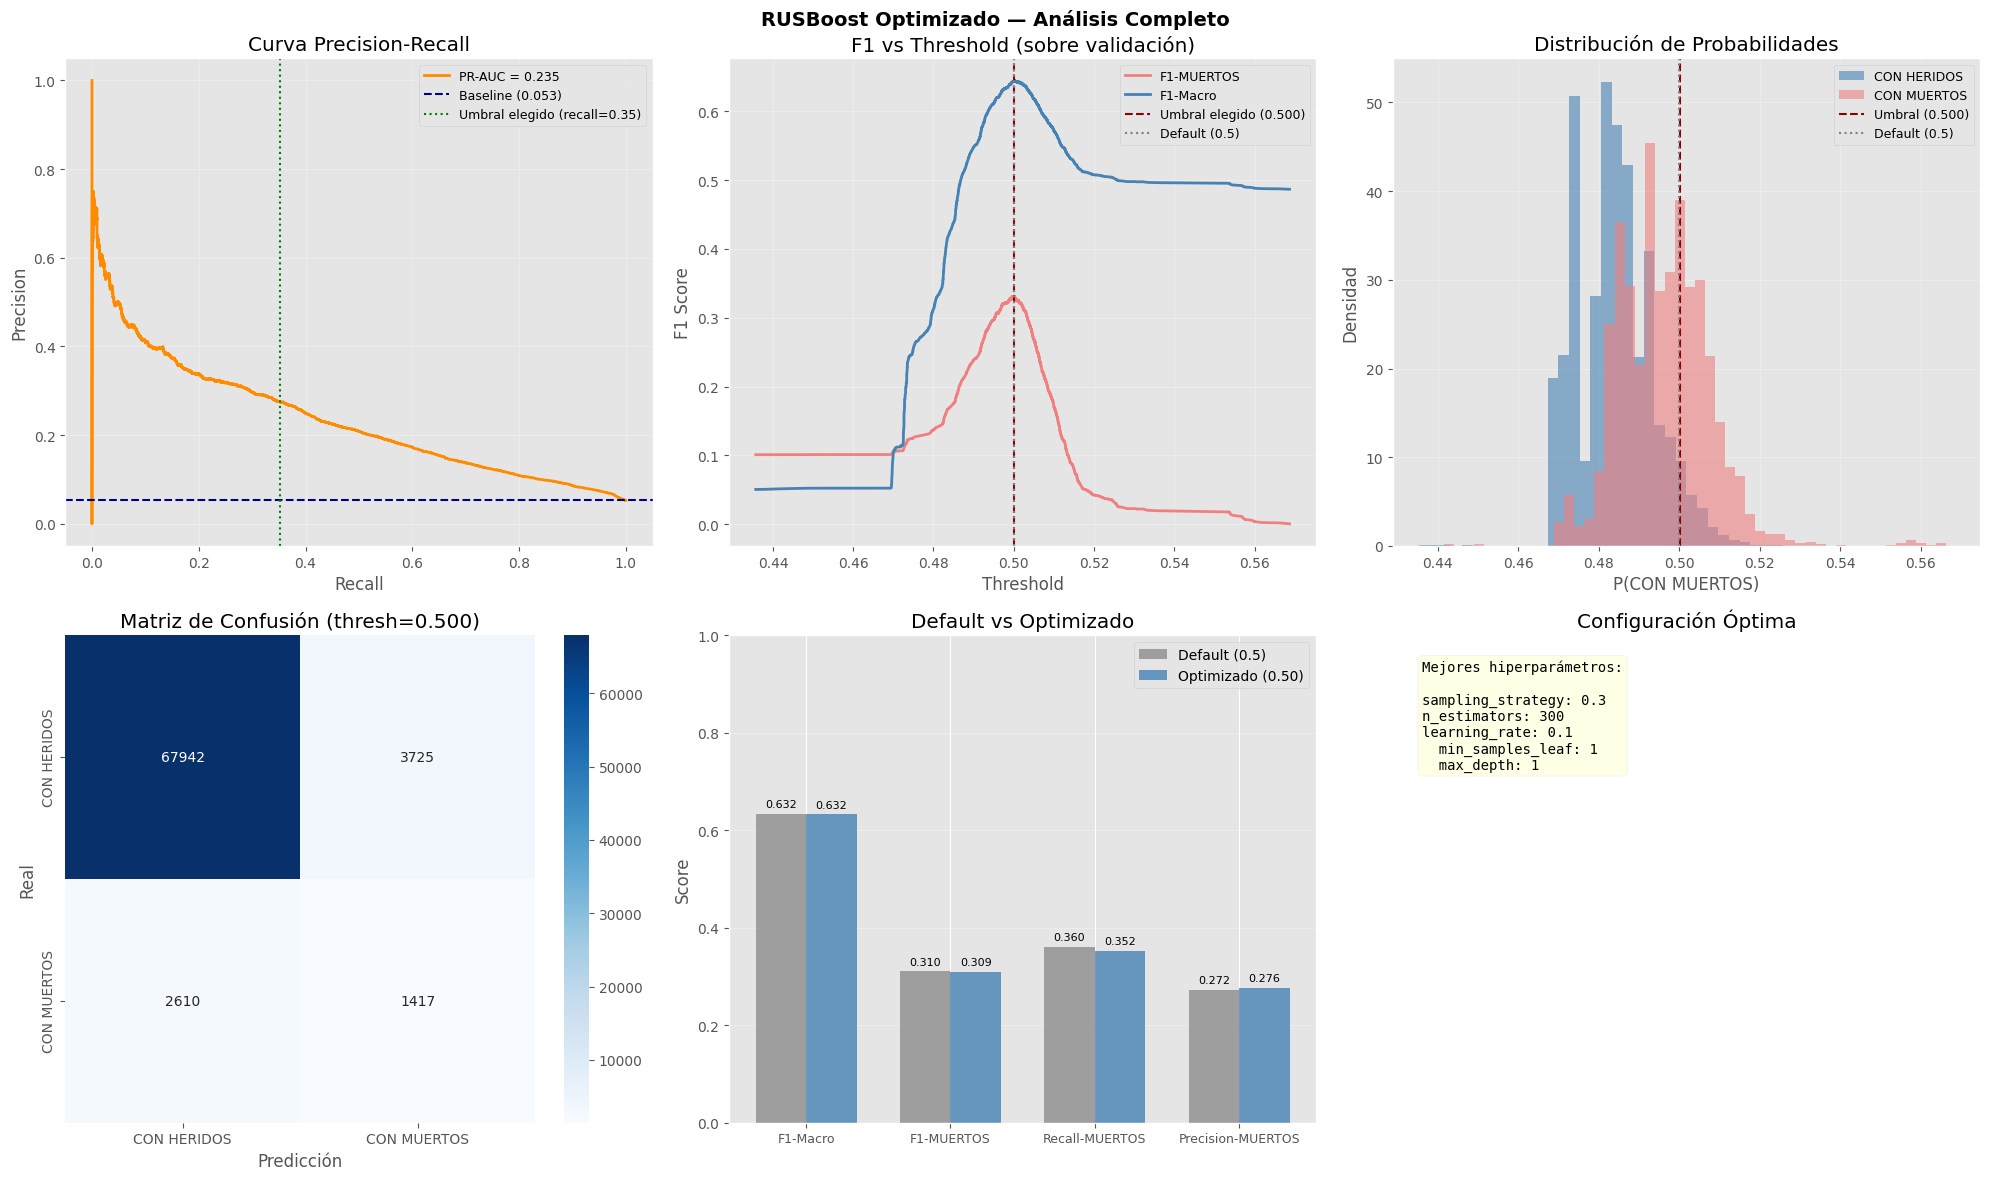


✓ Resultado agregado a 'results'. Total modelos: 8


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# RUSBOOST — Tuning Exhaustivo de Threshold + Optimización de Hiperparámetros
# ══════════════════════════════════════════════════════════════════════════════
# Estrategia:
#   1. Split interno de validación (sin tocar X_test)
#   2. RandomizedSearch enfocado en F1-MUERTOS (no F1-Macro genérico)
#   3. Threshold sweep completo sobre curva PR
#   4. Evaluación final con el mejor umbral
# ══════════════════════════════════════════════════════════════════════════════

from imblearn.ensemble import RUSBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, classification_report,
    precision_recall_curve, roc_auc_score,
    confusion_matrix, make_scorer
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("=" * 60)
print("RUSBOOST — Tuning Exhaustivo de Threshold")
print("=" * 60)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.1f}")

# ── PASO 1: Split validación interna para threshold tuning sin leakage ────────
X_tr_rus, X_val_rus, y_tr_rus, y_val_rus = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)
print(f"\nTrain RUS: {len(X_tr_rus):,} | Val threshold: {len(X_val_rus):,}")

# ── PASO 2: Pipeline base para búsqueda ───────────────────────────────────────
pipe_rus = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', RUSBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        random_state=RANDOM_STATE
    ))
])

# ── PASO 3: RandomizedSearch con scorer orientado a MUERTOS ───────────────────
# Usamos F1 de la clase minoritaria como scorer, no F1-Macro.
# Esto fuerza al search a priorizar detectar MUERTOS.

scorer_muertos = make_scorer(f1_score, pos_label=1, zero_division=0)

param_dist = {
    'model__n_estimators':              [100, 200, 300, 500],
    'model__learning_rate':             [0.05, 0.1, 0.2, 0.5, 1.0],
    'model__sampling_strategy':         [0.3, 0.5, 0.75, 1.0, 'auto'],
    'model__estimator__max_depth':      [1, 2, 3, 5],
    'model__estimator__min_samples_leaf': [1, 5, 10, 20],
}

print("\n[PASO 3] RandomizedSearch (20 iter, 3 folds) — scorer: F1-MUERTOS...")
print("Estimado: ~5-15 min\n")

rus_search = RandomizedSearchCV(
    pipe_rus,
    param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=scorer_muertos,       # ← clave: optimiza F1 de MUERTOS directamente
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

start = time.time()
rus_search.fit(X_tr_rus, y_tr_rus)
print(f"\nTiempo búsqueda: {(time.time()-start)/60:.1f} min")
print(f"Mejores parámetros: {rus_search.best_params_}")
print(f"Mejor F1-MUERTOS (CV): {rus_search.best_score_:.4f}")

best_rus = rus_search.best_estimator_

# ── PASO 4: Threshold sweep completo sobre validación ─────────────────────────
# Barremos todos los thresholds posibles en la curva PR y elegimos
# el que maximiza F1-MUERTOS (no F1-Macro) sobre el set de validación.

print("\n[PASO 4] Threshold sweep sobre validación interna...")

y_proba_val_rus = best_rus.predict_proba(X_val_rus)[:, 1]
precisions_v, recalls_v, thresholds_v = precision_recall_curve(y_val_rus, y_proba_val_rus)

precisions_v = precisions_v[:-1]
recalls_v    = recalls_v[:-1]
f1s_muertos  = 2 * (precisions_v * recalls_v) / (precisions_v + recalls_v + 1e-9)
f1s_macro_v  = []
for t in thresholds_v:
    pred_t = (y_proba_val_rus >= t).astype(int)
    f1s_macro_v.append(f1_score(y_val_rus, pred_t, average='macro'))
f1s_macro_v = np.array(f1s_macro_v)

# Estrategias de threshold
thresh_max_f1_muertos = thresholds_v[np.argmax(f1s_muertos)]
thresh_max_f1_macro   = thresholds_v[np.argmax(f1s_macro_v)]
mask_prec             = precisions_v >= 0.25
thresh_prec25         = (thresholds_v[mask_prec][np.argmax(recalls_v[mask_prec])]
                         if mask_prec.any() else thresh_max_f1_muertos)
mask_prec30           = precisions_v >= 0.30
thresh_prec30         = (thresholds_v[mask_prec30][np.argmax(recalls_v[mask_prec30])]
                         if mask_prec30.any() else thresh_max_f1_muertos)
thresh_recall60       = (thresholds_v[recalls_v >= 0.60][-1]
                         if (recalls_v >= 0.60).any() else thresh_max_f1_muertos)

print(f"\n{'Estrategia':<28} {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1-MUERTOS':>12} {'F1-Macro':>10}")
print("-" * 82)

resultados_rus = {}
for nombre, thresh in [
    ("Default (0.5)",          0.5),
    ("Máx F1-MUERTOS",         thresh_max_f1_muertos),
    ("Máx F1-Macro",           thresh_max_f1_macro),
    ("Precision ≥ 0.25",       thresh_prec25),
    ("Precision ≥ 0.30",       thresh_prec30),
    ("Recall ≥ 0.60",          thresh_recall60),
]:
    pred = (y_proba_val_rus >= thresh).astype(int)
    p  = precision_score(y_val_rus, pred, pos_label=1, zero_division=0)
    r  = recall_score(y_val_rus,    pred, pos_label=1, zero_division=0)
    f1m = f1_score(y_val_rus,       pred, pos_label=1, zero_division=0)
    fm  = f1_score(y_val_rus,       pred, average='macro')
    resultados_rus[nombre] = {'thresh': thresh, 'precision': p, 'recall': r,
                               'f1_muertos': f1m, 'f1_macro': fm}
    print(f"{nombre:<28} {thresh:>10.3f} {p:>10.4f} {r:>10.4f} {f1m:>12.4f} {fm:>10.4f}")

# Selección: máximo F1-MUERTOS con precision mínima de 0.20
# (evita que el modelo clasifique todo como MUERTO)
candidatos = {k: v for k, v in resultados_rus.items() if v['precision'] >= 0.20}
if candidatos:
    mejor_rus_thresh = max(candidatos, key=lambda k: candidatos[k]['f1_muertos'])
else:
    mejor_rus_thresh = "Máx F1-MUERTOS"

best_thresh_rus = resultados_rus[mejor_rus_thresh]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_rus_thresh}' (thresh={best_thresh_rus:.3f})")
print(f"  → Precision: {resultados_rus[mejor_rus_thresh]['precision']:.4f}")
print(f"  → Recall:    {resultados_rus[mejor_rus_thresh]['recall']:.4f}")
print(f"  → F1-MUERTOS:{resultados_rus[mejor_rus_thresh]['f1_muertos']:.4f}")

# ── PASO 5: Evaluación final en TEST ─────────────────────────────────────────

print("\n" + "=" * 60)
print("EVALUACIÓN FINAL — RUSBoost Optimizado en TEST SET")
print("=" * 60)

y_proba_test_rus = best_rus.predict_proba(X_test)[:, 1]
y_pred_rus       = (y_proba_test_rus >= best_thresh_rus).astype(int)

# Comparación Default vs Optimizado
y_pred_default = (y_proba_test_rus >= 0.5).astype(int)

f1_macro_opt   = f1_score(y_test, y_pred_rus,     average='macro')
f1_macro_def   = f1_score(y_test, y_pred_default, average='macro')
f1_muertos_opt = f1_score(y_test, y_pred_rus,     pos_label=1, zero_division=0)
f1_muertos_def = f1_score(y_test, y_pred_default, pos_label=1, zero_division=0)
rec_opt        = recall_score(y_test,    y_pred_rus, pos_label=1, zero_division=0)
rec_def        = recall_score(y_test,    y_pred_default, pos_label=1, zero_division=0)
prec_opt       = precision_score(y_test, y_pred_rus, pos_label=1, zero_division=0)
prec_def       = precision_score(y_test, y_pred_default, pos_label=1, zero_division=0)
aucpr_rus      = average_precision_score(y_test, y_proba_test_rus)
auc_rus        = roc_auc_score(y_test, y_proba_test_rus)

print(f"\n{'Métrica':<25} {'Default (0.5)':>14} {'Optimizado':>12} {'Mejora':>10}")
print("-" * 65)
print(f"{'F1-Macro':<25} {f1_macro_def:>14.4f} {f1_macro_opt:>12.4f} {f1_macro_opt-f1_macro_def:>+10.4f}")
print(f"{'F1-MUERTOS':<25} {f1_muertos_def:>14.4f} {f1_muertos_opt:>12.4f} {f1_muertos_opt-f1_muertos_def:>+10.4f}")
print(f"{'Recall-MUERTOS':<25} {rec_def:>14.4f} {rec_opt:>12.4f} {rec_opt-rec_def:>+10.4f}")
print(f"{'Precision-MUERTOS':<25} {prec_def:>14.4f} {prec_opt:>12.4f} {prec_opt-prec_def:>+10.4f}")
print(f"\nROC-AUC:  {auc_rus:.4f}")
print(f"PR-AUC:   {aucpr_rus:.4f}")
print(f"\n{classification_report(y_test, y_pred_rus, target_names=class_names)}")

# ── PASO 6: Gráficas ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("RUSBoost Optimizado — Análisis Completo", fontsize=14, fontweight='bold')

# 1. Curva PR con todas las estrategias de threshold
prec_t, rec_t, _ = precision_recall_curve(y_test, y_proba_test_rus)
axes[0, 0].plot(rec_t, prec_t, color='darkorange', lw=2, label=f'PR-AUC = {aucpr_rus:.3f}')
axes[0, 0].axhline(y=pos/(neg+pos), color='navy', linestyle='--',
                   label=f'Baseline ({pos/(neg+pos):.3f})')
axes[0, 0].axvline(x=rec_opt, color='green', linestyle=':',
                   label=f'Umbral elegido (recall={rec_opt:.2f})')
axes[0, 0].set_xlabel('Recall'); axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Curva Precision-Recall')
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(alpha=0.3)

# 2. F1-MUERTOS vs Threshold (curva completa)
axes[0, 1].plot(thresholds_v, f1s_muertos, color='lightcoral', lw=2, label='F1-MUERTOS')
axes[0, 1].plot(thresholds_v, f1s_macro_v, color='steelblue',  lw=2, label='F1-Macro')
axes[0, 1].axvline(x=best_thresh_rus, color='darkred', linestyle='--',
                   label=f'Umbral elegido ({best_thresh_rus:.3f})')
axes[0, 1].axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
axes[0, 1].set_xlabel('Threshold'); axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_title('F1 vs Threshold (sobre validación)')
axes[0, 1].legend(fontsize=9); axes[0, 1].grid(alpha=0.3)

# 3. Distribución de probabilidades
axes[0, 2].hist(y_proba_test_rus[y_test.values == 0], bins=50, alpha=0.6,
                label='CON HERIDOS', color='steelblue', density=True)
axes[0, 2].hist(y_proba_test_rus[y_test.values == 1], bins=50, alpha=0.6,
                label='CON MUERTOS', color='lightcoral', density=True)
axes[0, 2].axvline(x=best_thresh_rus, color='darkred', linestyle='--',
                   label=f'Umbral ({best_thresh_rus:.3f})')
axes[0, 2].axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
axes[0, 2].set_xlabel('P(CON MUERTOS)'); axes[0, 2].set_ylabel('Densidad')
axes[0, 2].set_title('Distribución de Probabilidades')
axes[0, 2].legend(fontsize=9); axes[0, 2].grid(alpha=0.3)

# 4. Matriz de confusión
cm_rus = confusion_matrix(y_test, y_pred_rus)
sns.heatmap(cm_rus, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=class_names, yticklabels=class_names)
axes[1, 0].set_title(f'Matriz de Confusión (thresh={best_thresh_rus:.3f})')
axes[1, 0].set_xlabel('Predicción'); axes[1, 0].set_ylabel('Real')

# 5. Default vs Optimizado
metricas   = ['F1-Macro', 'F1-MUERTOS', 'Recall-MUERTOS', 'Precision-MUERTOS']
vals_def   = [f1_macro_def,   f1_muertos_def,   rec_def,   prec_def]
vals_opt   = [f1_macro_opt,   f1_muertos_opt,   rec_opt,   prec_opt]
x_comp     = np.arange(len(metricas))
w          = 0.35
bars1 = axes[1, 1].bar(x_comp - w/2, vals_def, w, label='Default (0.5)',
                        color='gray', alpha=0.7)
bars2 = axes[1, 1].bar(x_comp + w/2, vals_opt, w, label=f'Optimizado ({best_thresh_rus:.2f})',
                        color='steelblue', alpha=0.8)
for bar in list(bars1) + list(bars2):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
axes[1, 1].set_xticks(x_comp); axes[1, 1].set_xticklabels(metricas, fontsize=9)
axes[1, 1].set_ylabel('Score'); axes[1, 1].set_title('Default vs Optimizado')
axes[1, 1].legend(); axes[1, 1].set_ylim(0, 1); axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Mejores hiperparámetros encontrados
param_texto = '\n'.join([f"{k.replace('model__','').replace('estimator__','  ')}: {v}"
                          for k, v in rus_search.best_params_.items()])
axes[1, 2].text(0.05, 0.95, f"Mejores hiperparámetros:\n\n{param_texto}",
                transform=axes[1, 2].transAxes, fontsize=10,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].axis('off')
axes[1, 2].set_title('Configuración Óptima')

plt.tight_layout()
plt.show()

# ── PASO 7: Acumular en results ───────────────────────────────────────────────
result_rus_opt = {
    'model_name':              'RUSBoost Optimizado (threshold tuning)',
    'test_f1_macro':           f1_macro_opt,
    'test_f1_muertos':         f1_muertos_opt,
    'test_recall_muertos':     rec_opt,
    'test_precision_muertos':  prec_opt,
    'test_roc_auc':            auc_rus,
    'test_pr_auc':             aucpr_rus,
    'threshold_used':          best_thresh_rus,
    'best_params':             rus_search.best_params_,
}
results.append(result_rus_opt)

print(f"\n✓ Resultado agregado a 'results'. Total modelos: {len(results)}")

IMBoost — Detector de Accidentes Fatales

[PASO 1] Submuestra estratificada 40%...
  Train completo:  302,776 registros
  Submuestra 40%:  121,110 registros
  HERIDOS:         114,666 (94.7%)
  MUERTOS:         6,444 (5.3%)
  Distribución original — HERIDOS: 94.7% | MUERTOS: 5.3%

  Train IMBoost:   96,888
  Val threshold:   24,222

[PASO 2] Preprocesando con el preprocessor existente...
  Shape train procesado: (96888, 12)

[PASO 3] Entrenando IMBoost base (100 estimadores)...
  Tiempo: 10.5s
  F1-Macro (val):   0.4314
  F1-MUERTOS (val): 0.1286

[PASO 4] Optuna — búsqueda de hiperparámetros (50 trials, 5 folds)...
  Scorer: F1-MUERTOS (pos_label=1)
  Estimado: ~10-20 min



Best trial: 11. Best value: 0.224402: 100%|██████████| 50/50 [44:34<00:00, 53.49s/it]  



  Mejores parámetros: {'n_estimators': 390, 'max_depth': 1}
  Mejor F1-MUERTOS (CV): 0.2244

[PASO 5] Entrenando IMBoost final con mejores parámetros...
  Tiempo: 18.9s

[PASO 6] Threshold tuning sobre validación interna...

Estrategia                Threshold  Precision     Recall   F1-MUERTOS   F1-Macro
------------------------------------------------------------------------------
Default (0.5)                 0.500     0.1299     0.6897       0.2186     0.5305
Máx F1-MUERTOS                0.766     0.2997     0.3181       0.3086     0.6342
Máx F1-Macro                  0.766     0.2997     0.3181       0.3086     0.6342
Precision ≥ 0.25              0.766     0.2997     0.3181       0.3086     0.6342
Precision ≥ 0.30              0.929     0.4430     0.0512       0.0918     0.5320

  Estrategia seleccionada: 'Máx F1-MUERTOS' (thresh=0.766)

EVALUACIÓN FINAL — IMBoost en TEST SET

Métrica                    Default (0.5)   Optimizado     Mejora
-------------------------------------

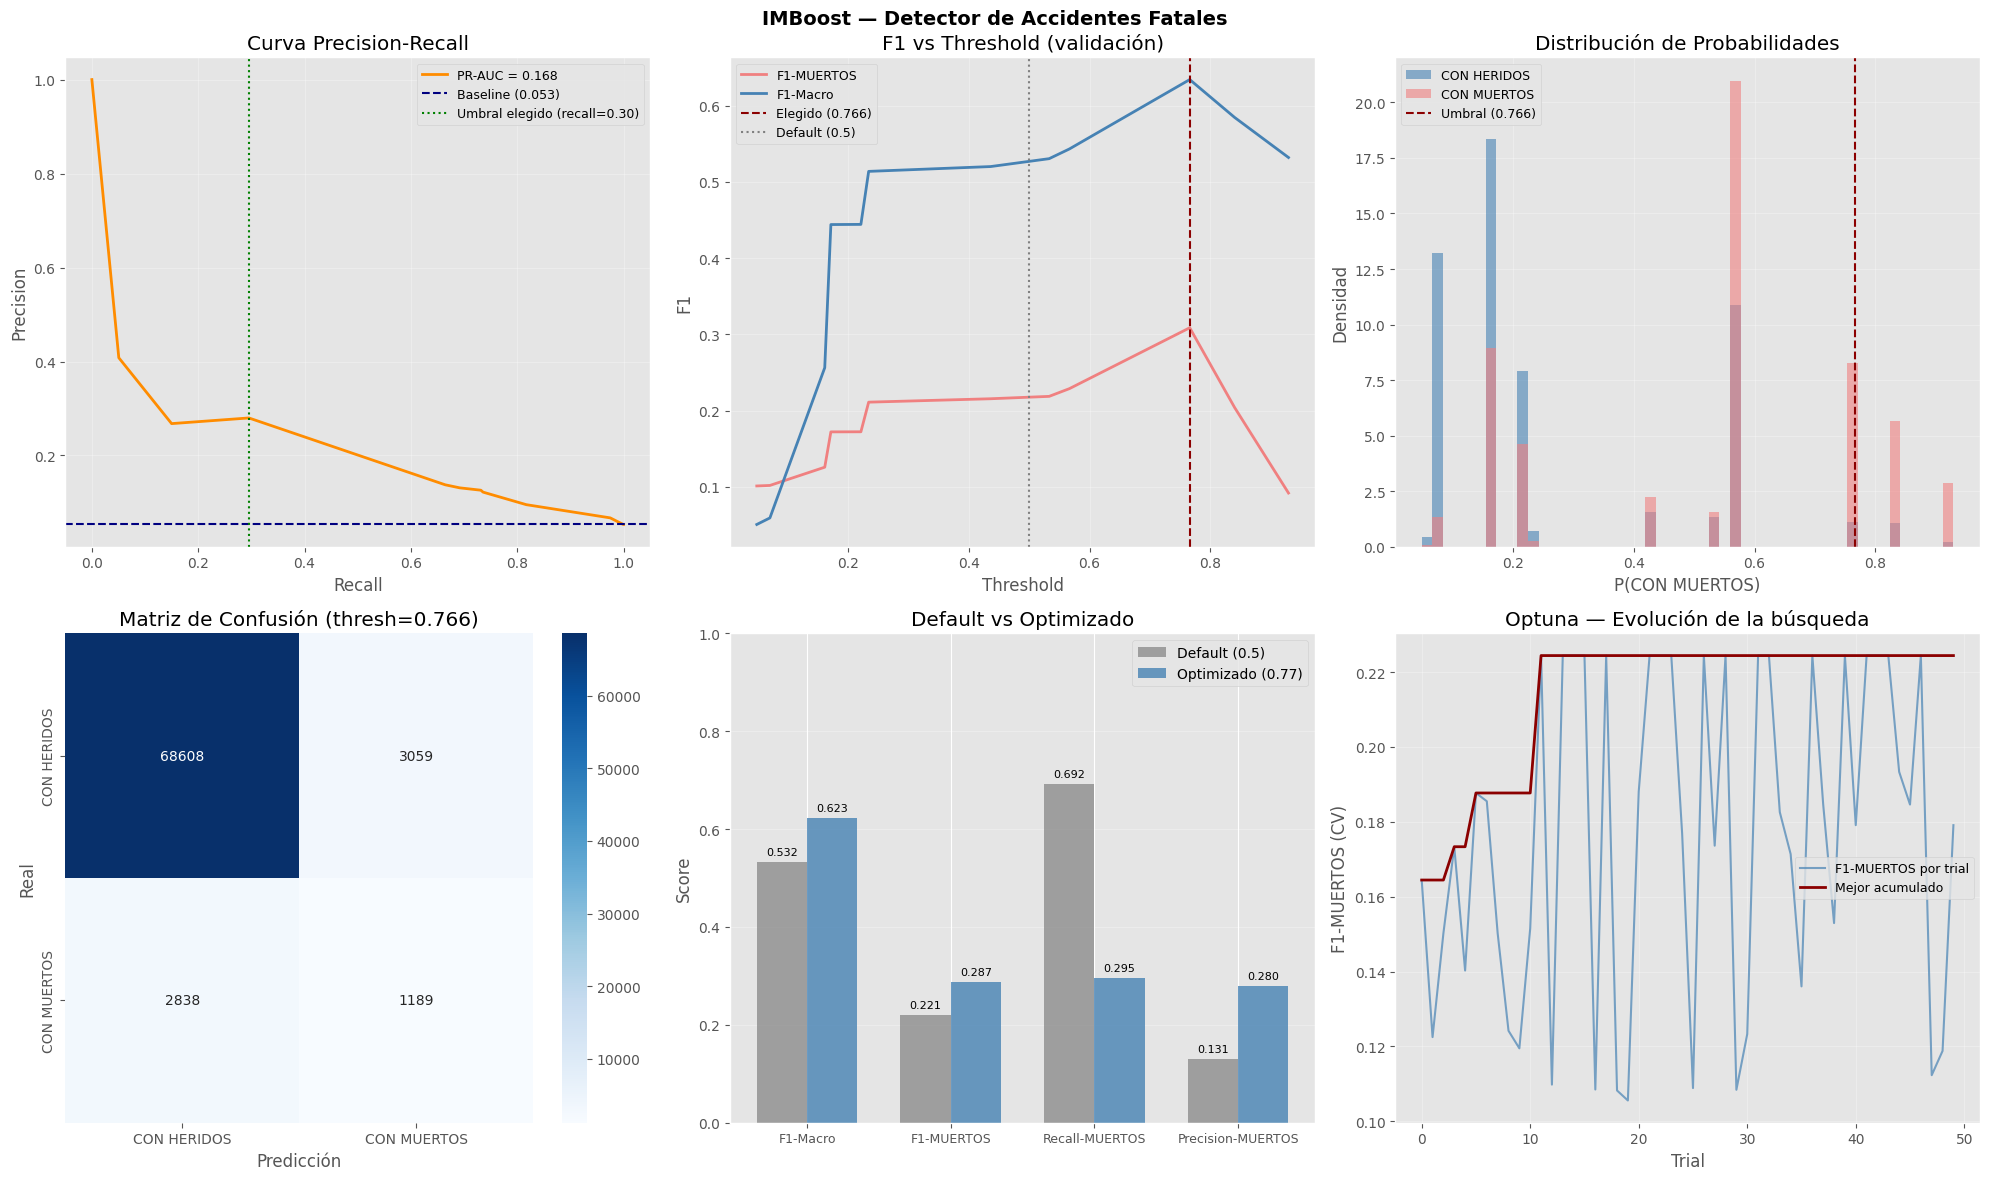


✓ Resultado agregado a 'results'. Total modelos: 10

NOTA: IMBoost usa DecisionTree como base — no tiene aceleración GPU.
La paralelización se aplicó via n_jobs=-1 en cross_val_score (Optuna).


In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# IMBoost — Implementación para Accidentes Colombia
# Submuestra 40% estratificada + Optuna + Threshold Tuning
# ══════════════════════════════════════════════════════════════════════════════
# NOTA: IMBoost usa árboles de decisión como base → no tiene soporte GPU nativo.
# La aceleración se logra via paralelismo en Optuna (n_jobs=-1).
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import warnings
import time
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve, make_scorer
)
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("IMBoost — Detector de Accidentes Fatales")
print("=" * 60)

# ── DEFINICIÓN DE IMBoost ─────────────────────────────────────────────────────

class IMBoost(BaseEstimator, ClassifierMixin):
    """
    IMBoost: AdaBoost con factor de ponderación diferenciado por clase.
    Calcula alpha_min y alpha_maj por separado para no sesgar hacia
    la clase mayoritaria — diseñado para desbalanceo extremo.
    Ref: Roshan (2023), Complexity Journal, doi:10.1155/2023/2176891
    """
    def __init__(self, n_estimators=100, max_depth=5, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth     = max_depth
        self.random_state  = random_state

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        if hasattr(X, 'values'): X = X.values
        if hasattr(y, 'values'): y = y.values

        np.random.seed(self.random_state)
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError("IMBoost solo soporta clasificación binaria.")

        y_t = np.where(y == 1, 1, -1)
        n   = len(y)
        min_idx = np.where(y == 1)[0]
        maj_idx = np.where(y == 0)[0]
        n_min, n_maj = len(min_idx), len(maj_idx)

        # Inicializar pesos uniformes por clase (paper eq. 1)
        w = np.zeros(n)
        w[min_idx] = 1.0 / n_min
        w[maj_idx] = 1.0 / n_maj

        self.classifiers_, self.alphas_min_, self.alphas_maj_ = [], [], []

        for t in range(self.n_estimators):
            try:
                idx = np.random.choice(n, size=n, replace=True,
                                       p=w / w.sum())
                clf = DecisionTreeClassifier(
                    max_depth=self.max_depth,
                    random_state=self.random_state + t
                )
                clf.fit(X[idx], y_t[idx])
                pred = clf.predict(X)

                min_mask = (y_t ==  1)
                maj_mask = (y_t == -1)

                def weighted_error(mask):
                    err   = np.sum(w[mask] * (pred[mask] != y_t[mask]))
                    total = w[mask].sum()
                    eps   = err / total if total > 0 else 0.5
                    return np.clip(eps, 1e-10, 1 - 1e-10)

                eps_min = weighted_error(min_mask)
                eps_maj = weighted_error(maj_mask)

                alpha_min = 0.5 * np.log((1 - eps_min) / eps_min)
                alpha_maj = 0.5 * np.log((1 - eps_maj) / eps_maj)

                w[min_mask] *= np.exp(-alpha_min * y_t[min_mask] * pred[min_mask])
                w[maj_mask] *= np.exp(-alpha_maj * y_t[maj_mask] * pred[maj_mask])
                w /= w.sum()

                self.classifiers_.append(clf)
                self.alphas_min_.append(alpha_min)
                self.alphas_maj_.append(alpha_maj)

            except Exception as e:
                warnings.warn(f"Iteración {t} falló: {e}")

        self.n_features_in_ = X.shape[1]
        return self

    def _score(self, X):
        X = check_array(X)
        if hasattr(X, 'values'): X = X.values
        s = np.zeros(X.shape[0])
        for a_min, a_maj, clf in zip(self.alphas_min_, self.alphas_maj_, self.classifiers_):
            s += (a_min + a_maj) * clf.predict(X)
        return s

    def predict(self, X):
        if not hasattr(self, 'classifiers_') or len(self.classifiers_) == 0:
            raise ValueError("Modelo no entrenado. Llama fit() primero.")
        return np.where(self._score(X) >= 0, 1, 0)

    def predict_proba(self, X):
        if not hasattr(self, 'classifiers_') or len(self.classifiers_) == 0:
            raise ValueError("Modelo no entrenado. Llama fit() primero.")
        s = self._score(X)
        p = np.clip(1 / (1 + np.exp(-s)), 0, 1)
        return np.vstack([1 - p, p]).T


# ── PASO 1: Submuestra 40% estratificada ─────────────────────────────────────
# Mantiene la misma distribución ~95/5 de HERIDOS/MUERTOS que el dataset completo

print("\n[PASO 1] Submuestra estratificada 40%...")

X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.60,
    random_state=RANDOM_STATE,
    stratify=y_train        # ← garantiza misma distribución de clases
)

neg_sub = (y_sub == 0).sum()
pos_sub = (y_sub == 1).sum()
print(f"  Train completo:  {len(X_train):,} registros")
print(f"  Submuestra 40%:  {len(X_sub):,} registros")
print(f"  HERIDOS:         {neg_sub:,} ({neg_sub/len(y_sub)*100:.1f}%)")
print(f"  MUERTOS:         {pos_sub:,} ({pos_sub/len(y_sub)*100:.1f}%)")
print(f"  Distribución original — HERIDOS: {(y_train==0).mean()*100:.1f}% | MUERTOS: {(y_train==1).mean()*100:.1f}%")

# Split interno val para threshold tuning (sin tocar X_test)
X_tr_imb, X_val_imb, y_tr_imb, y_val_imb = train_test_split(
    X_sub, y_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sub
)
print(f"\n  Train IMBoost:   {len(X_tr_imb):,}")
print(f"  Val threshold:   {len(X_val_imb):,}")

# ── PASO 2: Preprocesar (reusar preprocessor del proyecto) ───────────────────

print("\n[PASO 2] Preprocesando con el preprocessor existente...")
preprocessor.fit(X_tr_imb, y_tr_imb)

X_tr_proc  = preprocessor.transform(X_tr_imb)
X_val_proc = preprocessor.transform(X_val_imb)
X_test_proc = preprocessor.transform(X_test)

print(f"  Shape train procesado: {X_tr_proc.shape}")

# ── PASO 3: Baseline rápido ───────────────────────────────────────────────────

print("\n[PASO 3] Entrenando IMBoost base (100 estimadores)...")
start = time.time()

imb_base = IMBoost(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
imb_base.fit(X_tr_proc, y_tr_imb)

y_pred_base_imb = imb_base.predict(X_val_proc)
f1_base = f1_score(y_val_imb, y_pred_base_imb, average='macro')
f1_base_min = f1_score(y_val_imb, y_pred_base_imb, pos_label=1, zero_division=0)
print(f"  Tiempo: {time.time()-start:.1f}s")
print(f"  F1-Macro (val):   {f1_base:.4f}")
print(f"  F1-MUERTOS (val): {f1_base_min:.4f}")

# ── PASO 4: Optuna — búsqueda de hiperparámetros ─────────────────────────────
# Scorer: F1-MUERTOS directamente (igual que el tuning de RUSBoost)
# n_jobs=-1 en cross_val_score para usar todos los cores disponibles

print("\n[PASO 4] Optuna — búsqueda de hiperparámetros (50 trials, 5 folds)...")
print("  Scorer: F1-MACRO (average='macro')")
print("  Estimado: ~10-20 min\n")

scorer_muertos = make_scorer(f1_score, average='macro', zero_division=0)
cv_imb = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective_imb(trial):
    n_est  = trial.suggest_int('n_estimators', 50, 400)
    depth  = trial.suggest_int('max_depth', 1, 8)

    model = IMBoost(
        n_estimators=n_est,
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    try:
        scores = cross_val_score(
            model, X_tr_proc, y_tr_imb,
            cv=cv_imb,
            scoring=scorer_muertos,
            n_jobs=-1               # paralelismo en folds
        )
        return np.mean(scores)
    except Exception:
        return 0.0

study_imb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE)
)
study_imb.optimize(objective_imb, n_trials=50, show_progress_bar=True)

print(f"\n  Mejores parámetros: {study_imb.best_params}")
print(f"  Mejor F1-MUERTOS (CV): {study_imb.best_value:.4f}")

# ── PASO 5: Entrenar modelo final con mejores params ─────────────────────────

print("\n[PASO 5] Entrenando IMBoost final con mejores parámetros...")
start = time.time()

best_imb = IMBoost(
    n_estimators=study_imb.best_params['n_estimators'],
    max_depth=study_imb.best_params['max_depth'],
    random_state=RANDOM_STATE
)
best_imb.fit(X_tr_proc, y_tr_imb)
print(f"  Tiempo: {time.time()-start:.1f}s")

# ── PASO 6: Threshold tuning sobre validación ─────────────────────────────────

print("\n[PASO 6] Threshold tuning sobre validación interna...")

y_proba_val_imb = best_imb.predict_proba(X_val_proc)[:, 1]
prec_v, rec_v, thresh_v = precision_recall_curve(y_val_imb, y_proba_val_imb)

prec_v_c = prec_v[:-1]
rec_v_c  = rec_v[:-1]
f1s_min_v  = 2 * (prec_v_c * rec_v_c) / (prec_v_c + rec_v_c + 1e-9)
f1s_mac_v  = np.array([
    f1_score(y_val_imb, (y_proba_val_imb >= t).astype(int), average='macro')
    for t in thresh_v
])

thresh_max_f1_min = thresh_v[np.argmax(f1s_min_v)]
thresh_max_f1_mac = thresh_v[np.argmax(f1s_mac_v)]
mask25 = prec_v_c >= 0.25
thresh_p25 = thresh_v[mask25][np.argmax(rec_v_c[mask25])] if mask25.any() else thresh_max_f1_min
mask30 = prec_v_c >= 0.30
thresh_p30 = thresh_v[mask30][np.argmax(rec_v_c[mask30])] if mask30.any() else thresh_max_f1_min

print(f"\n{'Estrategia':<24} {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1-MUERTOS':>12} {'F1-Macro':>10}")
print("-" * 78)

res_thresh_imb = {}
for nombre, thresh in [
    ("Default (0.5)",       0.5),
    ("Máx F1-MUERTOS",      thresh_max_f1_min),
    ("Máx F1-Macro",        thresh_max_f1_mac),
    ("Precision ≥ 0.25",    thresh_p25),
    ("Precision ≥ 0.30",    thresh_p30),
]:
    pred = (y_proba_val_imb >= thresh).astype(int)
    p   = precision_score(y_val_imb, pred, pos_label=1, zero_division=0)
    r   = recall_score(y_val_imb,    pred, pos_label=1, zero_division=0)
    f1m = f1_score(y_val_imb,        pred, pos_label=1, zero_division=0)
    fm  = f1_score(y_val_imb,        pred, average='macro')
    res_thresh_imb[nombre] = {'thresh': thresh, 'p': p, 'r': r, 'f1_min': f1m, 'f1_mac': fm}
    print(f"{nombre:<24} {thresh:>10.3f} {p:>10.4f} {r:>10.4f} {f1m:>12.4f} {fm:>10.4f}")

# Selección: mejor F1-MUERTOS con precision >= 0.20
candidatos_imb = {k: v for k, v in res_thresh_imb.items() if v['p'] >= 0.20}
mejor_imb = max(candidatos_imb, key=lambda k: candidatos_imb[k]['f1_min']) if candidatos_imb else "Máx F1-MUERTOS"
best_thresh_imb = res_thresh_imb[mejor_imb]['thresh']
print(f"\n  Estrategia seleccionada: '{mejor_imb}' (thresh={best_thresh_imb:.3f})")

# ── PASO 7: Evaluación final en TEST ─────────────────────────────────────────

print("\n" + "=" * 60)
print("EVALUACIÓN FINAL — IMBoost en TEST SET")
print("=" * 60)

y_proba_test_imb = best_imb.predict_proba(X_test_proc)[:, 1]
y_pred_imb       = (y_proba_test_imb >= best_thresh_imb).astype(int)
y_pred_default   = (y_proba_test_imb >= 0.5).astype(int)

f1_mac_opt  = f1_score(y_test, y_pred_imb,     average='macro')
f1_mac_def  = f1_score(y_test, y_pred_default, average='macro')
f1_min_opt  = f1_score(y_test, y_pred_imb,     pos_label=1, zero_division=0)
f1_min_def  = f1_score(y_test, y_pred_default, pos_label=1, zero_division=0)
rec_opt     = recall_score(y_test,    y_pred_imb, pos_label=1, zero_division=0)
rec_def     = recall_score(y_test,    y_pred_default, pos_label=1, zero_division=0)
prec_opt    = precision_score(y_test, y_pred_imb, pos_label=1, zero_division=0)
prec_def    = precision_score(y_test, y_pred_default, pos_label=1, zero_division=0)
aucpr_imb   = average_precision_score(y_test, y_proba_test_imb)
auc_imb     = roc_auc_score(y_test, y_proba_test_imb)

print(f"\n{'Métrica':<25} {'Default (0.5)':>14} {'Optimizado':>12} {'Mejora':>10}")
print("-" * 65)
print(f"{'F1-Macro':<25} {f1_mac_def:>14.4f} {f1_mac_opt:>12.4f} {f1_mac_opt-f1_mac_def:>+10.4f}")
print(f"{'F1-MUERTOS':<25} {f1_min_def:>14.4f} {f1_min_opt:>12.4f} {f1_min_opt-f1_min_def:>+10.4f}")
print(f"{'Recall-MUERTOS':<25} {rec_def:>14.4f} {rec_opt:>12.4f} {rec_opt-rec_def:>+10.4f}")
print(f"{'Precision-MUERTOS':<25} {prec_def:>14.4f} {prec_opt:>12.4f} {prec_opt-prec_def:>+10.4f}")
print(f"\n  ROC-AUC: {auc_imb:.4f} | PR-AUC: {aucpr_imb:.4f}")
print(f"\n{classification_report(y_test, y_pred_imb, target_names=class_names)}")

# ── PASO 8: Gráficas ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("IMBoost — Detector de Accidentes Fatales", fontsize=14, fontweight='bold')

# 1. Curva PR
from sklearn.metrics import roc_curve
neg_t = (y_test == 0).sum(); pos_t = (y_test == 1).sum()
prec_t, rec_t, _ = precision_recall_curve(y_test, y_proba_test_imb)
axes[0, 0].plot(rec_t, prec_t, color='darkorange', lw=2, label=f'PR-AUC = {aucpr_imb:.3f}')
axes[0, 0].axhline(y=pos_t/(neg_t+pos_t), color='navy', linestyle='--',
                   label=f'Baseline ({pos_t/(neg_t+pos_t):.3f})')
axes[0, 0].axvline(x=rec_opt, color='green', linestyle=':',
                   label=f'Umbral elegido (recall={rec_opt:.2f})')
axes[0, 0].set_xlabel('Recall'); axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Curva Precision-Recall'); axes[0, 0].legend(fontsize=9); axes[0, 0].grid(alpha=0.3)

# 2. F1 vs Threshold
axes[0, 1].plot(thresh_v, f1s_min_v, color='lightcoral', lw=2, label='F1-MUERTOS')
axes[0, 1].plot(thresh_v, f1s_mac_v, color='steelblue',  lw=2, label='F1-Macro')
axes[0, 1].axvline(x=best_thresh_imb, color='darkred', linestyle='--',
                   label=f'Elegido ({best_thresh_imb:.3f})')
axes[0, 1].axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
axes[0, 1].set_xlabel('Threshold'); axes[0, 1].set_ylabel('F1')
axes[0, 1].set_title('F1 vs Threshold (validación)'); axes[0, 1].legend(fontsize=9); axes[0, 1].grid(alpha=0.3)

# 3. Distribución de probabilidades
axes[0, 2].hist(y_proba_test_imb[y_test.values == 0], bins=50, alpha=0.6,
                label='CON HERIDOS', color='steelblue', density=True)
axes[0, 2].hist(y_proba_test_imb[y_test.values == 1], bins=50, alpha=0.6,
                label='CON MUERTOS', color='lightcoral', density=True)
axes[0, 2].axvline(x=best_thresh_imb, color='darkred', linestyle='--',
                   label=f'Umbral ({best_thresh_imb:.3f})')
axes[0, 2].set_xlabel('P(CON MUERTOS)'); axes[0, 2].set_ylabel('Densidad')
axes[0, 2].set_title('Distribución de Probabilidades'); axes[0, 2].legend(fontsize=9); axes[0, 2].grid(alpha=0.3)

# 4. Matriz de confusión
cm_imb = confusion_matrix(y_test, y_pred_imb)
sns.heatmap(cm_imb, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=class_names, yticklabels=class_names)
axes[1, 0].set_title(f'Matriz de Confusión (thresh={best_thresh_imb:.3f})')
axes[1, 0].set_xlabel('Predicción'); axes[1, 0].set_ylabel('Real')

# 5. Default vs Optimizado
metricas_comp = ['F1-Macro', 'F1-MUERTOS', 'Recall-MUERTOS', 'Precision-MUERTOS']
vals_def_c = [f1_mac_def, f1_min_def, rec_def, prec_def]
vals_opt_c = [f1_mac_opt, f1_min_opt, rec_opt, prec_opt]
xc = np.arange(len(metricas_comp)); wc = 0.35
b1 = axes[1, 1].bar(xc - wc/2, vals_def_c, wc, label='Default (0.5)', color='gray',     alpha=0.7)
b2 = axes[1, 1].bar(xc + wc/2, vals_opt_c, wc, label=f'Optimizado ({best_thresh_imb:.2f})', color='steelblue', alpha=0.8)
for bar in list(b1) + list(b2):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
axes[1, 1].set_xticks(xc); axes[1, 1].set_xticklabels(metricas_comp, fontsize=9)
axes[1, 1].set_ylabel('Score'); axes[1, 1].set_title('Default vs Optimizado')
axes[1, 1].legend(); axes[1, 1].set_ylim(0, 1); axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Optuna — historia de optimización
trials_vals = [t.value for t in study_imb.trials if t.value is not None]
axes[1, 2].plot(trials_vals, color='steelblue', lw=1.5, alpha=0.7, label='F1-MUERTOS por trial')
axes[1, 2].plot(np.maximum.accumulate(trials_vals), color='darkred', lw=2, label='Mejor acumulado')
axes[1, 2].set_xlabel('Trial'); axes[1, 2].set_ylabel('F1-MUERTOS (CV)')
axes[1, 2].set_title('Optuna — Evolución de la búsqueda')
axes[1, 2].legend(fontsize=9); axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── PASO 9: Acumular en results ───────────────────────────────────────────────

result_imb = {
    'model_name':              'IMBoost (40% data, Optuna + threshold tuning)',
    'test_f1_macro':           f1_mac_opt,
    'test_f1_muertos':         f1_min_opt,
    'test_recall_muertos':     rec_opt,
    'test_precision_muertos':  prec_opt,
    'test_roc_auc':            auc_imb,
    'test_pr_auc':             aucpr_imb,
    'threshold_used':          best_thresh_imb,
    'best_params':             study_imb.best_params,
    'n_train_samples':         len(X_tr_imb),
}
results.append(result_imb)

print(f"\n✓ Resultado agregado a 'results'. Total modelos: {len(results)}")
print(f"\nNOTA: IMBoost usa DecisionTree como base — no tiene aceleración GPU.")
print(f"La paralelización se aplicó via n_jobs=-1 en cross_val_score (Optuna).")

IMBoost — Detector de Accidentes Fatales

[PASO 1] Submuestra estratificada 40%...
  Train completo:  302,776 registros
  Submuestra 40%:  121,110 registros
  HERIDOS:         114,666 (94.7%)
  MUERTOS:         6,444 (5.3%)
  Distribución original — HERIDOS: 94.7% | MUERTOS: 5.3%

  Train IMBoost:   96,888
  Val threshold:   24,222

[PASO 2] Preprocesando con el preprocessor existente...
  Shape train procesado: (96888, 12)

[PASO 3] Entrenando IMBoost base (100 estimadores)...
  Tiempo: 10.2s
  F1-Macro (val):   0.4314
  F1-MUERTOS (val): 0.1286

[PASO 4] Optuna — búsqueda de hiperparámetros (50 trials, 5 folds)...
  Scorer: F1-MACRO (average='macro')
  Estimado: ~10-20 min



Best trial: 10. Best value: 0.533671: 100%|██████████| 50/50 [25:56<00:00, 31.13s/it] 



  Mejores parámetros: {'n_estimators': 381, 'max_depth': 1}
  Mejor F1-MUERTOS (CV): 0.5337

[PASO 5] Entrenando IMBoost final con mejores parámetros...
  Tiempo: 18.4s

[PASO 6] Threshold tuning sobre validación interna...

Estrategia                Threshold  Precision     Recall   F1-MUERTOS   F1-Macro
------------------------------------------------------------------------------
Default (0.5)                 0.500     0.1299     0.6897       0.2186     0.5305
Máx F1-MUERTOS                0.766     0.2997     0.3181       0.3086     0.6342
Máx F1-Macro                  0.766     0.2997     0.3181       0.3086     0.6342
Precision ≥ 0.25              0.766     0.2997     0.3181       0.3086     0.6342
Precision ≥ 0.30              0.929     0.4430     0.0512       0.0918     0.5320

  Estrategia seleccionada: 'Máx F1-MUERTOS' (thresh=0.766)

EVALUACIÓN FINAL — IMBoost en TEST SET

Métrica                    Default (0.5)   Optimizado     Mejora
-------------------------------------

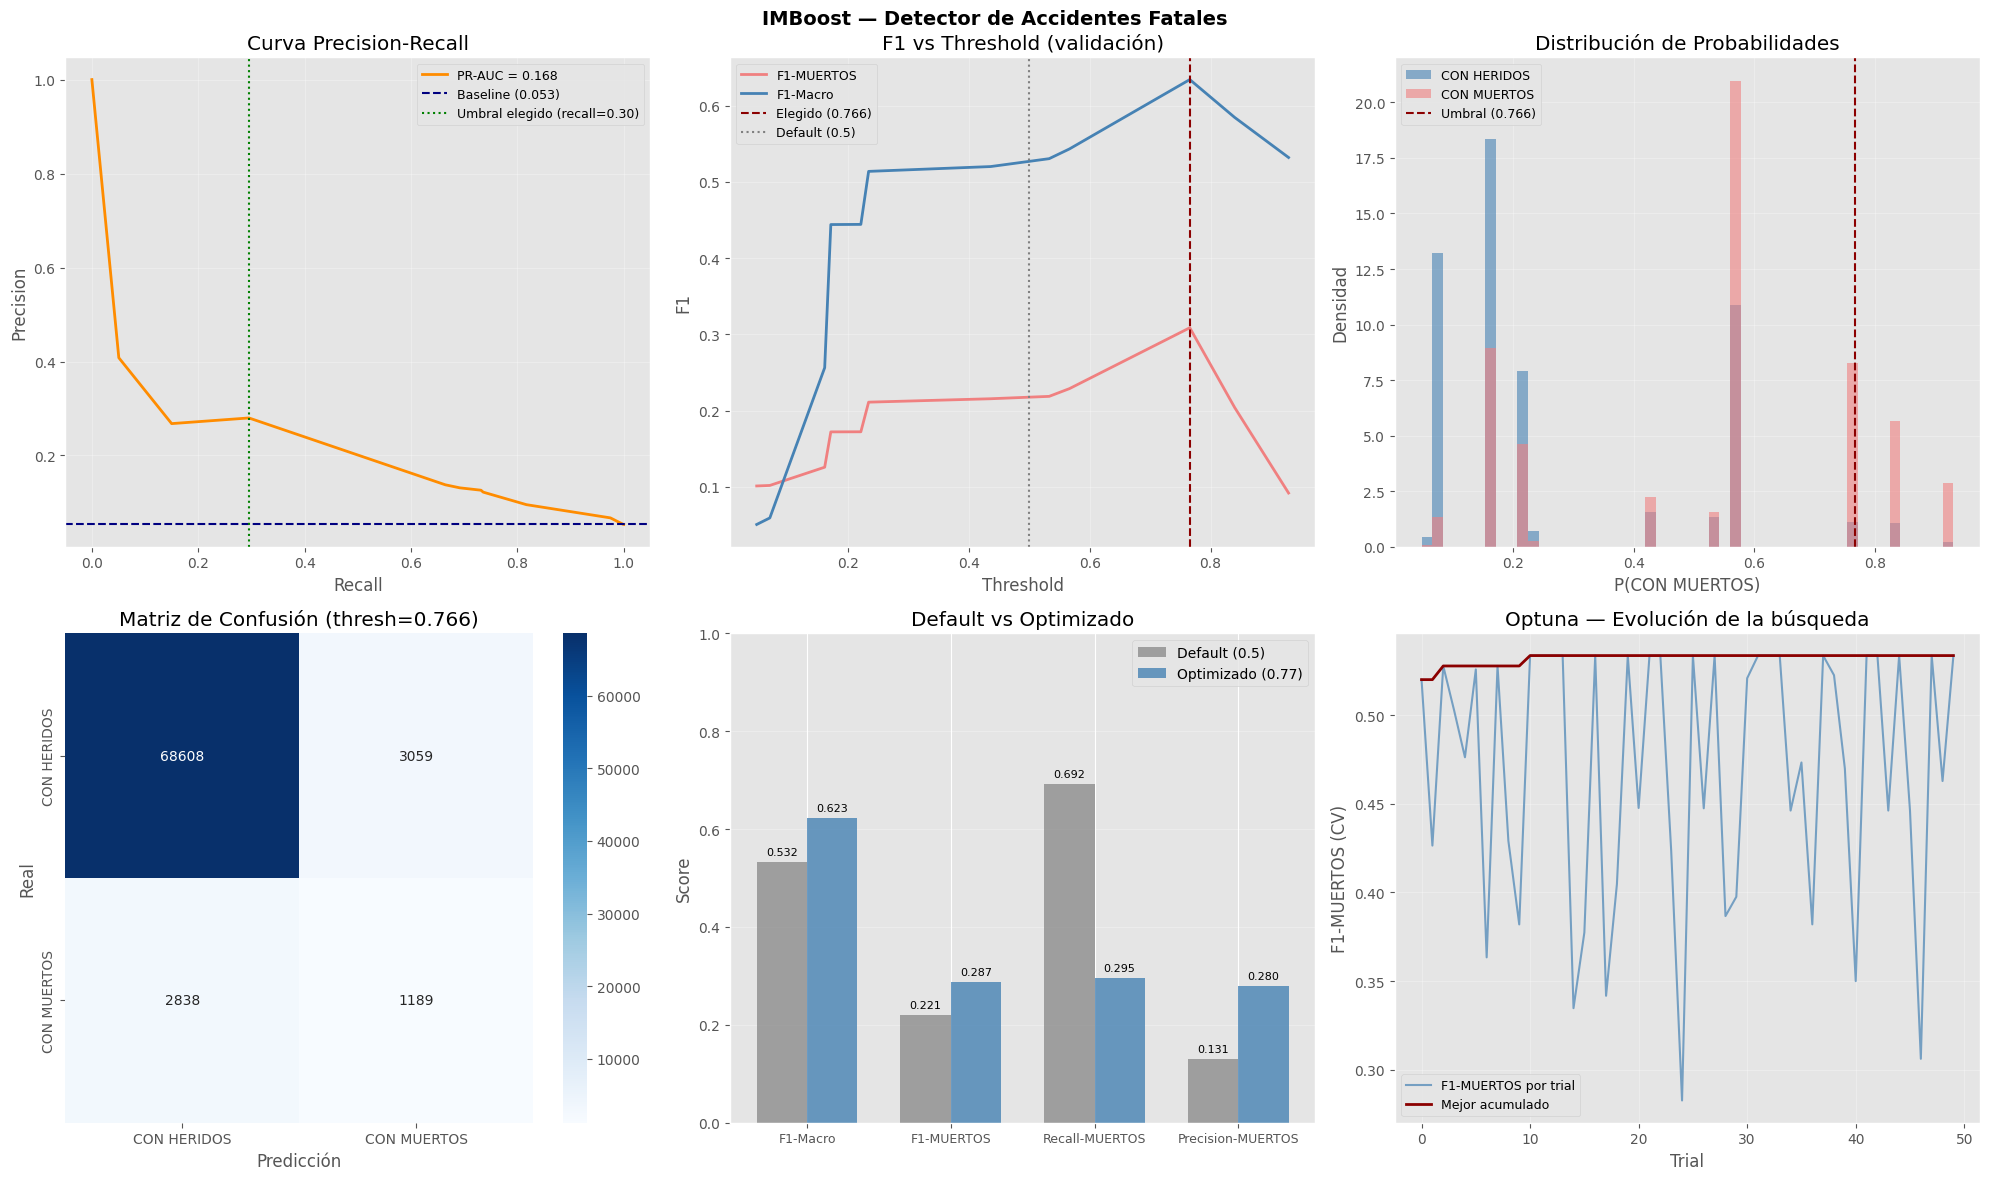


✓ Resultado agregado a 'results'. Total modelos: 11

NOTA: IMBoost usa DecisionTree como base — no tiene aceleración GPU.
La paralelización se aplicó via n_jobs=-1 en cross_val_score (Optuna).


In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# IMBoost — Implementación para Accidentes Colombia
# Submuestra 40% estratificada + Optuna + Threshold Tuning
# ══════════════════════════════════════════════════════════════════════════════
# NOTA: IMBoost usa árboles de decisión como base → no tiene soporte GPU nativo.
# La aceleración se logra via paralelismo en Optuna (n_jobs=-1).
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import warnings
import time
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve, make_scorer
)
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("IMBoost — Detector de Accidentes Fatales")
print("=" * 60)

# ── DEFINICIÓN DE IMBoost ─────────────────────────────────────────────────────

class IMBoost(BaseEstimator, ClassifierMixin):
    """
    IMBoost: AdaBoost con factor de ponderación diferenciado por clase.
    Calcula alpha_min y alpha_maj por separado para no sesgar hacia
    la clase mayoritaria — diseñado para desbalanceo extremo.
    Ref: Roshan (2023), Complexity Journal, doi:10.1155/2023/2176891
    """
    def __init__(self, n_estimators=100, max_depth=5, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth     = max_depth
        self.random_state  = random_state

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        if hasattr(X, 'values'): X = X.values
        if hasattr(y, 'values'): y = y.values

        np.random.seed(self.random_state)
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError("IMBoost solo soporta clasificación binaria.")

        y_t = np.where(y == 1, 1, -1)
        n   = len(y)
        min_idx = np.where(y == 1)[0]
        maj_idx = np.where(y == 0)[0]
        n_min, n_maj = len(min_idx), len(maj_idx)

        # Inicializar pesos uniformes por clase (paper eq. 1)
        w = np.zeros(n)
        w[min_idx] = 1.0 / n_min
        w[maj_idx] = 1.0 / n_maj

        self.classifiers_, self.alphas_min_, self.alphas_maj_ = [], [], []

        for t in range(self.n_estimators):
            try:
                idx = np.random.choice(n, size=n, replace=True,
                                       p=w / w.sum())
                clf = DecisionTreeClassifier(
                    max_depth=self.max_depth,
                    random_state=self.random_state + t
                )
                clf.fit(X[idx], y_t[idx])
                pred = clf.predict(X)

                min_mask = (y_t ==  1)
                maj_mask = (y_t == -1)

                def weighted_error(mask):
                    err   = np.sum(w[mask] * (pred[mask] != y_t[mask]))
                    total = w[mask].sum()
                    eps   = err / total if total > 0 else 0.5
                    return np.clip(eps, 1e-10, 1 - 1e-10)

                eps_min = weighted_error(min_mask)
                eps_maj = weighted_error(maj_mask)

                alpha_min = 0.5 * np.log((1 - eps_min) / eps_min)
                alpha_maj = 0.5 * np.log((1 - eps_maj) / eps_maj)

                w[min_mask] *= np.exp(-alpha_min * y_t[min_mask] * pred[min_mask])
                w[maj_mask] *= np.exp(-alpha_maj * y_t[maj_mask] * pred[maj_mask])
                w /= w.sum()

                self.classifiers_.append(clf)
                self.alphas_min_.append(alpha_min)
                self.alphas_maj_.append(alpha_maj)

            except Exception as e:
                warnings.warn(f"Iteración {t} falló: {e}")

        self.n_features_in_ = X.shape[1]
        return self

    def _score(self, X):
        X = check_array(X)
        if hasattr(X, 'values'): X = X.values
        s = np.zeros(X.shape[0])
        for a_min, a_maj, clf in zip(self.alphas_min_, self.alphas_maj_, self.classifiers_):
            s += (a_min + a_maj) * clf.predict(X)
        return s

    def predict(self, X):
        if not hasattr(self, 'classifiers_') or len(self.classifiers_) == 0:
            raise ValueError("Modelo no entrenado. Llama fit() primero.")
        return np.where(self._score(X) >= 0, 1, 0)

    def predict_proba(self, X):
        if not hasattr(self, 'classifiers_') or len(self.classifiers_) == 0:
            raise ValueError("Modelo no entrenado. Llama fit() primero.")
        s = self._score(X)
        p = np.clip(1 / (1 + np.exp(-s)), 0, 1)
        return np.vstack([1 - p, p]).T


# ── PASO 1: Submuestra 40% estratificada ─────────────────────────────────────
# Mantiene la misma distribución ~95/5 de HERIDOS/MUERTOS que el dataset completo

print("\n[PASO 1] Submuestra estratificada 40%...")

X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.60,
    random_state=RANDOM_STATE,
    stratify=y_train        # ← garantiza misma distribución de clases
)

neg_sub = (y_sub == 0).sum()
pos_sub = (y_sub == 1).sum()
print(f"  Train completo:  {len(X_train):,} registros")
print(f"  Submuestra 40%:  {len(X_sub):,} registros")
print(f"  HERIDOS:         {neg_sub:,} ({neg_sub/len(y_sub)*100:.1f}%)")
print(f"  MUERTOS:         {pos_sub:,} ({pos_sub/len(y_sub)*100:.1f}%)")
print(f"  Distribución original — HERIDOS: {(y_train==0).mean()*100:.1f}% | MUERTOS: {(y_train==1).mean()*100:.1f}%")

# Split interno val para threshold tuning (sin tocar X_test)
X_tr_imb, X_val_imb, y_tr_imb, y_val_imb = train_test_split(
    X_sub, y_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sub
)
print(f"\n  Train IMBoost:   {len(X_tr_imb):,}")
print(f"  Val threshold:   {len(X_val_imb):,}")

# ── PASO 2: Preprocesar (reusar preprocessor del proyecto) ───────────────────

print("\n[PASO 2] Preprocesando con el preprocessor existente...")
preprocessor.fit(X_tr_imb, y_tr_imb)

X_tr_proc  = preprocessor.transform(X_tr_imb)
X_val_proc = preprocessor.transform(X_val_imb)
X_test_proc = preprocessor.transform(X_test)

print(f"  Shape train procesado: {X_tr_proc.shape}")

# ── PASO 3: Baseline rápido ───────────────────────────────────────────────────

print("\n[PASO 3] Entrenando IMBoost base (100 estimadores)...")
start = time.time()

imb_base = IMBoost(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
imb_base.fit(X_tr_proc, y_tr_imb)

y_pred_base_imb = imb_base.predict(X_val_proc)
f1_base = f1_score(y_val_imb, y_pred_base_imb, average='macro')
f1_base_min = f1_score(y_val_imb, y_pred_base_imb, pos_label=1, zero_division=0)
print(f"  Tiempo: {time.time()-start:.1f}s")
print(f"  F1-Macro (val):   {f1_base:.4f}")
print(f"  F1-MUERTOS (val): {f1_base_min:.4f}")

# ── PASO 4: Optuna — búsqueda de hiperparámetros ─────────────────────────────
# Scorer: F1-MUERTOS directamente (igual que el tuning de RUSBoost)
# n_jobs=-1 en cross_val_score para usar todos los cores disponibles

print("\n[PASO 4] Optuna — búsqueda de hiperparámetros (50 trials, 5 folds)...")
print("  Scorer: F1-MACRO (average='macro')")
print("  Estimado: ~10-20 min\n")

scorer_muertos = make_scorer(f1_score, average='macro', zero_division=0)
cv_imb = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective_imb(trial):
    n_est  = trial.suggest_int('n_estimators', 50, 400)
    depth  = trial.suggest_int('max_depth', 1, 8)

    model = IMBoost(
        n_estimators=n_est,
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    try:
        scores = cross_val_score(
            model, X_tr_proc, y_tr_imb,
            cv=cv_imb,
            scoring=scorer_muertos,
            n_jobs=-1               # paralelismo en folds
        )
        return np.mean(scores)
    except Exception:
        return 0.0

study_imb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE)
)
study_imb.optimize(objective_imb, n_trials=50, show_progress_bar=True)

print(f"\n  Mejores parámetros: {study_imb.best_params}")
print(f"  Mejor F1-MUERTOS (CV): {study_imb.best_value:.4f}")

# ── PASO 5: Entrenar modelo final con mejores params ─────────────────────────

print("\n[PASO 5] Entrenando IMBoost final con mejores parámetros...")
start = time.time()

best_imb = IMBoost(
    n_estimators=study_imb.best_params['n_estimators'],
    max_depth=study_imb.best_params['max_depth'],
    random_state=RANDOM_STATE
)
best_imb.fit(X_tr_proc, y_tr_imb)
print(f"  Tiempo: {time.time()-start:.1f}s")

# ── PASO 6: Threshold tuning sobre validación ─────────────────────────────────

print("\n[PASO 6] Threshold tuning sobre validación interna...")

y_proba_val_imb = best_imb.predict_proba(X_val_proc)[:, 1]
prec_v, rec_v, thresh_v = precision_recall_curve(y_val_imb, y_proba_val_imb)

prec_v_c = prec_v[:-1]
rec_v_c  = rec_v[:-1]
f1s_min_v  = 2 * (prec_v_c * rec_v_c) / (prec_v_c + rec_v_c + 1e-9)
f1s_mac_v  = np.array([
    f1_score(y_val_imb, (y_proba_val_imb >= t).astype(int), average='macro')
    for t in thresh_v
])

thresh_max_f1_min = thresh_v[np.argmax(f1s_min_v)]
thresh_max_f1_mac = thresh_v[np.argmax(f1s_mac_v)]
mask25 = prec_v_c >= 0.25
thresh_p25 = thresh_v[mask25][np.argmax(rec_v_c[mask25])] if mask25.any() else thresh_max_f1_min
mask30 = prec_v_c >= 0.30
thresh_p30 = thresh_v[mask30][np.argmax(rec_v_c[mask30])] if mask30.any() else thresh_max_f1_min

print(f"\n{'Estrategia':<24} {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1-MUERTOS':>12} {'F1-Macro':>10}")
print("-" * 78)

res_thresh_imb = {}
for nombre, thresh in [
    ("Default (0.5)",       0.5),
    ("Máx F1-MUERTOS",      thresh_max_f1_min),
    ("Máx F1-Macro",        thresh_max_f1_mac),
    ("Precision ≥ 0.25",    thresh_p25),
    ("Precision ≥ 0.30",    thresh_p30),
]:
    pred = (y_proba_val_imb >= thresh).astype(int)
    p   = precision_score(y_val_imb, pred, pos_label=1, zero_division=0)
    r   = recall_score(y_val_imb,    pred, pos_label=1, zero_division=0)
    f1m = f1_score(y_val_imb,        pred, pos_label=1, zero_division=0)
    fm  = f1_score(y_val_imb,        pred, average='macro')
    res_thresh_imb[nombre] = {'thresh': thresh, 'p': p, 'r': r, 'f1_min': f1m, 'f1_mac': fm}
    print(f"{nombre:<24} {thresh:>10.3f} {p:>10.4f} {r:>10.4f} {f1m:>12.4f} {fm:>10.4f}")

# Selección: mejor F1-MUERTOS con precision >= 0.20
candidatos_imb = {k: v for k, v in res_thresh_imb.items() if v['p'] >= 0.20}
mejor_imb = max(candidatos_imb, key=lambda k: candidatos_imb[k]['f1_min']) if candidatos_imb else "Máx F1-MUERTOS"
best_thresh_imb = res_thresh_imb[mejor_imb]['thresh']
print(f"\n  Estrategia seleccionada: '{mejor_imb}' (thresh={best_thresh_imb:.3f})")

# ── PASO 7: Evaluación final en TEST ─────────────────────────────────────────

print("\n" + "=" * 60)
print("EVALUACIÓN FINAL — IMBoost en TEST SET")
print("=" * 60)

y_proba_test_imb = best_imb.predict_proba(X_test_proc)[:, 1]
y_pred_imb       = (y_proba_test_imb >= best_thresh_imb).astype(int)
y_pred_default   = (y_proba_test_imb >= 0.5).astype(int)

f1_mac_opt  = f1_score(y_test, y_pred_imb,     average='macro')
f1_mac_def  = f1_score(y_test, y_pred_default, average='macro')
f1_min_opt  = f1_score(y_test, y_pred_imb,     pos_label=1, zero_division=0)
f1_min_def  = f1_score(y_test, y_pred_default, pos_label=1, zero_division=0)
rec_opt     = recall_score(y_test,    y_pred_imb, pos_label=1, zero_division=0)
rec_def     = recall_score(y_test,    y_pred_default, pos_label=1, zero_division=0)
prec_opt    = precision_score(y_test, y_pred_imb, pos_label=1, zero_division=0)
prec_def    = precision_score(y_test, y_pred_default, pos_label=1, zero_division=0)
aucpr_imb   = average_precision_score(y_test, y_proba_test_imb)
auc_imb     = roc_auc_score(y_test, y_proba_test_imb)

print(f"\n{'Métrica':<25} {'Default (0.5)':>14} {'Optimizado':>12} {'Mejora':>10}")
print("-" * 65)
print(f"{'F1-Macro':<25} {f1_mac_def:>14.4f} {f1_mac_opt:>12.4f} {f1_mac_opt-f1_mac_def:>+10.4f}")
print(f"{'F1-MUERTOS':<25} {f1_min_def:>14.4f} {f1_min_opt:>12.4f} {f1_min_opt-f1_min_def:>+10.4f}")
print(f"{'Recall-MUERTOS':<25} {rec_def:>14.4f} {rec_opt:>12.4f} {rec_opt-rec_def:>+10.4f}")
print(f"{'Precision-MUERTOS':<25} {prec_def:>14.4f} {prec_opt:>12.4f} {prec_opt-prec_def:>+10.4f}")
print(f"\n  ROC-AUC: {auc_imb:.4f} | PR-AUC: {aucpr_imb:.4f}")
print(f"\n{classification_report(y_test, y_pred_imb, target_names=class_names)}")

# ── PASO 8: Gráficas ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("IMBoost — Detector de Accidentes Fatales", fontsize=14, fontweight='bold')

# 1. Curva PR
from sklearn.metrics import roc_curve
neg_t = (y_test == 0).sum(); pos_t = (y_test == 1).sum()
prec_t, rec_t, _ = precision_recall_curve(y_test, y_proba_test_imb)
axes[0, 0].plot(rec_t, prec_t, color='darkorange', lw=2, label=f'PR-AUC = {aucpr_imb:.3f}')
axes[0, 0].axhline(y=pos_t/(neg_t+pos_t), color='navy', linestyle='--',
                   label=f'Baseline ({pos_t/(neg_t+pos_t):.3f})')
axes[0, 0].axvline(x=rec_opt, color='green', linestyle=':',
                   label=f'Umbral elegido (recall={rec_opt:.2f})')
axes[0, 0].set_xlabel('Recall'); axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Curva Precision-Recall'); axes[0, 0].legend(fontsize=9); axes[0, 0].grid(alpha=0.3)

# 2. F1 vs Threshold
axes[0, 1].plot(thresh_v, f1s_min_v, color='lightcoral', lw=2, label='F1-MUERTOS')
axes[0, 1].plot(thresh_v, f1s_mac_v, color='steelblue',  lw=2, label='F1-Macro')
axes[0, 1].axvline(x=best_thresh_imb, color='darkred', linestyle='--',
                   label=f'Elegido ({best_thresh_imb:.3f})')
axes[0, 1].axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
axes[0, 1].set_xlabel('Threshold'); axes[0, 1].set_ylabel('F1')
axes[0, 1].set_title('F1 vs Threshold (validación)'); axes[0, 1].legend(fontsize=9); axes[0, 1].grid(alpha=0.3)

# 3. Distribución de probabilidades
axes[0, 2].hist(y_proba_test_imb[y_test.values == 0], bins=50, alpha=0.6,
                label='CON HERIDOS', color='steelblue', density=True)
axes[0, 2].hist(y_proba_test_imb[y_test.values == 1], bins=50, alpha=0.6,
                label='CON MUERTOS', color='lightcoral', density=True)
axes[0, 2].axvline(x=best_thresh_imb, color='darkred', linestyle='--',
                   label=f'Umbral ({best_thresh_imb:.3f})')
axes[0, 2].set_xlabel('P(CON MUERTOS)'); axes[0, 2].set_ylabel('Densidad')
axes[0, 2].set_title('Distribución de Probabilidades'); axes[0, 2].legend(fontsize=9); axes[0, 2].grid(alpha=0.3)

# 4. Matriz de confusión
cm_imb = confusion_matrix(y_test, y_pred_imb)
sns.heatmap(cm_imb, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=class_names, yticklabels=class_names)
axes[1, 0].set_title(f'Matriz de Confusión (thresh={best_thresh_imb:.3f})')
axes[1, 0].set_xlabel('Predicción'); axes[1, 0].set_ylabel('Real')

# 5. Default vs Optimizado
metricas_comp = ['F1-Macro', 'F1-MUERTOS', 'Recall-MUERTOS', 'Precision-MUERTOS']
vals_def_c = [f1_mac_def, f1_min_def, rec_def, prec_def]
vals_opt_c = [f1_mac_opt, f1_min_opt, rec_opt, prec_opt]
xc = np.arange(len(metricas_comp)); wc = 0.35
b1 = axes[1, 1].bar(xc - wc/2, vals_def_c, wc, label='Default (0.5)', color='gray',     alpha=0.7)
b2 = axes[1, 1].bar(xc + wc/2, vals_opt_c, wc, label=f'Optimizado ({best_thresh_imb:.2f})', color='steelblue', alpha=0.8)
for bar in list(b1) + list(b2):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
axes[1, 1].set_xticks(xc); axes[1, 1].set_xticklabels(metricas_comp, fontsize=9)
axes[1, 1].set_ylabel('Score'); axes[1, 1].set_title('Default vs Optimizado')
axes[1, 1].legend(); axes[1, 1].set_ylim(0, 1); axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Optuna — historia de optimización
trials_vals = [t.value for t in study_imb.trials if t.value is not None]
axes[1, 2].plot(trials_vals, color='steelblue', lw=1.5, alpha=0.7, label='F1-MUERTOS por trial')
axes[1, 2].plot(np.maximum.accumulate(trials_vals), color='darkred', lw=2, label='Mejor acumulado')
axes[1, 2].set_xlabel('Trial'); axes[1, 2].set_ylabel('F1-MUERTOS (CV)')
axes[1, 2].set_title('Optuna — Evolución de la búsqueda')
axes[1, 2].legend(fontsize=9); axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── PASO 9: Acumular en results ───────────────────────────────────────────────

result_imb = {
    'model_name':              'IMBoost (40% data, Optuna + threshold tuning)',
    'test_f1_macro':           f1_mac_opt,
    'test_f1_muertos':         f1_min_opt,
    'test_recall_muertos':     rec_opt,
    'test_precision_muertos':  prec_opt,
    'test_roc_auc':            auc_imb,
    'test_pr_auc':             aucpr_imb,
    'threshold_used':          best_thresh_imb,
    'best_params':             study_imb.best_params,
    'n_train_samples':         len(X_tr_imb),
}
results.append(result_imb)

print(f"\n✓ Resultado agregado a 'results'. Total modelos: {len(results)}")
print(f"\nNOTA: IMBoost usa DecisionTree como base — no tiene aceleración GPU.")
print(f"La paralelización se aplicó via n_jobs=-1 en cross_val_score (Optuna).")